### Investigate frameshift problem in exp07 

In [64]:
import os
import pandas as pd

import tifffile as tiff
import numpy as np
from preprocessing import get_image_paths
from tqdm.notebook import tqdm

In [65]:
paths = get_image_paths('/home/nbahou/myimaging/apoDet/data/dataset1/apo_masks')
all_avg_diffs = []
all_min_diffs = []
for path in tqdm(paths):
    print(f"Processing: {os.path.basename(path)}")
    img_stack = np.load(path)['gt']    # Load label stack
    # Convert labels to binary
    bin_imgs = np.copy(img_stack)
    bin_imgs[img_stack != 0] = 1

    differences = []
    min_differences = []
    for i, img in enumerate(bin_imgs):
        if i == 0:
            diff = np.abs(img - bin_imgs[i + 1])
            sad = np.sum(diff)
            differences.append(sad)
            min_differences.append(sad)
        elif i == len(bin_imgs)-1:
            diff = np.abs(bin_imgs[i - 1] - img)
            sad = np.sum(diff)
            differences.append(sad)
            min_differences.append(sad)
        else:
            diff1 = np.abs(img - bin_imgs[i + 1])
            diff2 = np.abs(img - bin_imgs[i - 1])
            sad1 = np.sum(diff1)
            sad2 = np.sum(diff2)
    
            combined_sad = (sad1 + sad2) / 2
            min_sad = min(sad1, sad2)
            differences.append(combined_sad)
            min_differences.append(min_sad)
    all_avg_diffs.append(differences)
    all_min_diffs.append(min_differences)

  0%|          | 0/219 [00:00<?, ?it/s]

Processing: Exp01_Site01.npz
Processing: Exp01_Site02.npz
Processing: Exp01_Site03.npz
Processing: Exp01_Site04.npz
Processing: Exp01_Site05.npz
Processing: Exp01_Site06.npz
Processing: Exp01_Site07.npz
Processing: Exp01_Site08.npz
Processing: Exp01_Site09.npz
Processing: Exp02_Site01.npz
Processing: Exp02_Site02.npz
Processing: Exp02_Site03.npz
Processing: Exp02_Site04.npz
Processing: Exp02_Site05.npz
Processing: Exp02_Site06.npz
Processing: Exp02_Site07.npz
Processing: Exp02_Site08.npz
Processing: Exp02_Site09.npz
Processing: Exp02_Site10.npz
Processing: Exp03_Site01.npz
Processing: Exp03_Site02.npz
Processing: Exp03_Site03.npz
Processing: Exp03_Site04.npz
Processing: Exp03_Site05.npz
Processing: Exp03_Site06.npz
Processing: Exp03_Site07.npz
Processing: Exp03_Site08.npz
Processing: Exp03_Site09.npz
Processing: Exp03_Site10.npz
Processing: Exp04_Site01.npz
Processing: Exp04_Site02.npz
Processing: Exp04_Site03.npz
Processing: Exp04_Site04.npz
Processing: Exp04_Site05.npz
Processing: Ex

In [66]:
df = pd.DataFrame(
    {
        "filenames": [os.path.basename(path) for path in paths],
        "avg_diffs": all_avg_diffs,
        "min_diffs": all_min_diffs
    }
)
df

,filenames,avg_diffs,min_diffs
0,Exp01_Site01.npz,"[2876506694, 2655550987.0, 2250408166.0, 16973...","[2876506694, 2396454492, 2131886120, 126025746..."
1,Exp01_Site02.npz,"[1028718237, 1164378581.5, 1331297292.0, 11442...","[1028718237, 1005453667, 1301019232, 108186841..."
2,Exp01_Site03.npz,"[949748136, 953351731.0, 908722499.0, 85698178...","[949748136, 929168910, 896532978, 783352517, 8..."
3,Exp01_Site04.npz,"[1336145883, 894305285.5, 854884163.0, 9257947...","[1336145883, 589103078, 587399194, 755696147, ..."
4,Exp01_Site05.npz,"[910230034, 1271922113.0, 1216708998.5, 102098...","[910230034, 944963054, 875167905, 885718879, 1..."
...,...,...,...
214,Exp17_Site04.npz,"[1141833915, 1139474162.0, 921698595.0, 821460...","[1141833915, 1124859551, 741671141, 756678427,..."
215,Exp17_Site05.npz,"[1401355822, 1364002059.5, 1529412023.5, 13361...","[1401355822, 1357187141, 1495922619, 118155153..."
216,Exp17_Site06.npz,"[1280965066, 1183712439.0, 1219394793.0, 11141...","[1280965066, 1176766006, 1194130698, 108383499..."
217,Exp17_Site07.npz,"[1104609725, 1607007155.5, 1812629267.5, 16891...","[1104609725, 1133772355, 1660094283, 159580034..."


In [67]:
exp_nums = []
for name in df['filenames']:
    exp_part = name.split('_')[0]
    exp_num = int(exp_part.replace("Exp", ""))
    exp_nums.append(exp_num)

df['exp_nums'] = exp_nums
df.head(20)

,filenames,avg_diffs,min_diffs,exp_nums
0,Exp01_Site01.npz,"[2876506694, 2655550987.0, 2250408166.0, 16973...","[2876506694, 2396454492, 2131886120, 126025746...",1
1,Exp01_Site02.npz,"[1028718237, 1164378581.5, 1331297292.0, 11442...","[1028718237, 1005453667, 1301019232, 108186841...",1
2,Exp01_Site03.npz,"[949748136, 953351731.0, 908722499.0, 85698178...","[949748136, 929168910, 896532978, 783352517, 8...",1
3,Exp01_Site04.npz,"[1336145883, 894305285.5, 854884163.0, 9257947...","[1336145883, 589103078, 587399194, 755696147, ...",1
4,Exp01_Site05.npz,"[910230034, 1271922113.0, 1216708998.5, 102098...","[910230034, 944963054, 875167905, 885718879, 1...",1
5,Exp01_Site06.npz,"[1157563067, 1576959396.0, 1798897512.5, 14560...","[1157563067, 1203371333, 1680604372, 128470433...",1
6,Exp01_Site07.npz,"[1428358453, 1844837582.0, 1521713230.0, 84708...","[1428358453, 1515715275, 889323373, 814480596,...",1
7,Exp01_Site08.npz,"[1516176663, 1392802071.0, 848691914.0, 902824...","[1516176663, 1184036677, 659815641, 606929703,...",1
8,Exp01_Site09.npz,"[976945787, 1287946751.5, 1353546502.0, 106132...","[976945787, 1018559877, 1041104006, 982778746,...",1
9,Exp02_Site01.npz,"[706478799, 704510906.5, 546570812.5, 54679957...","[706478799, 655424068, 533921469, 512753987, 5...",2


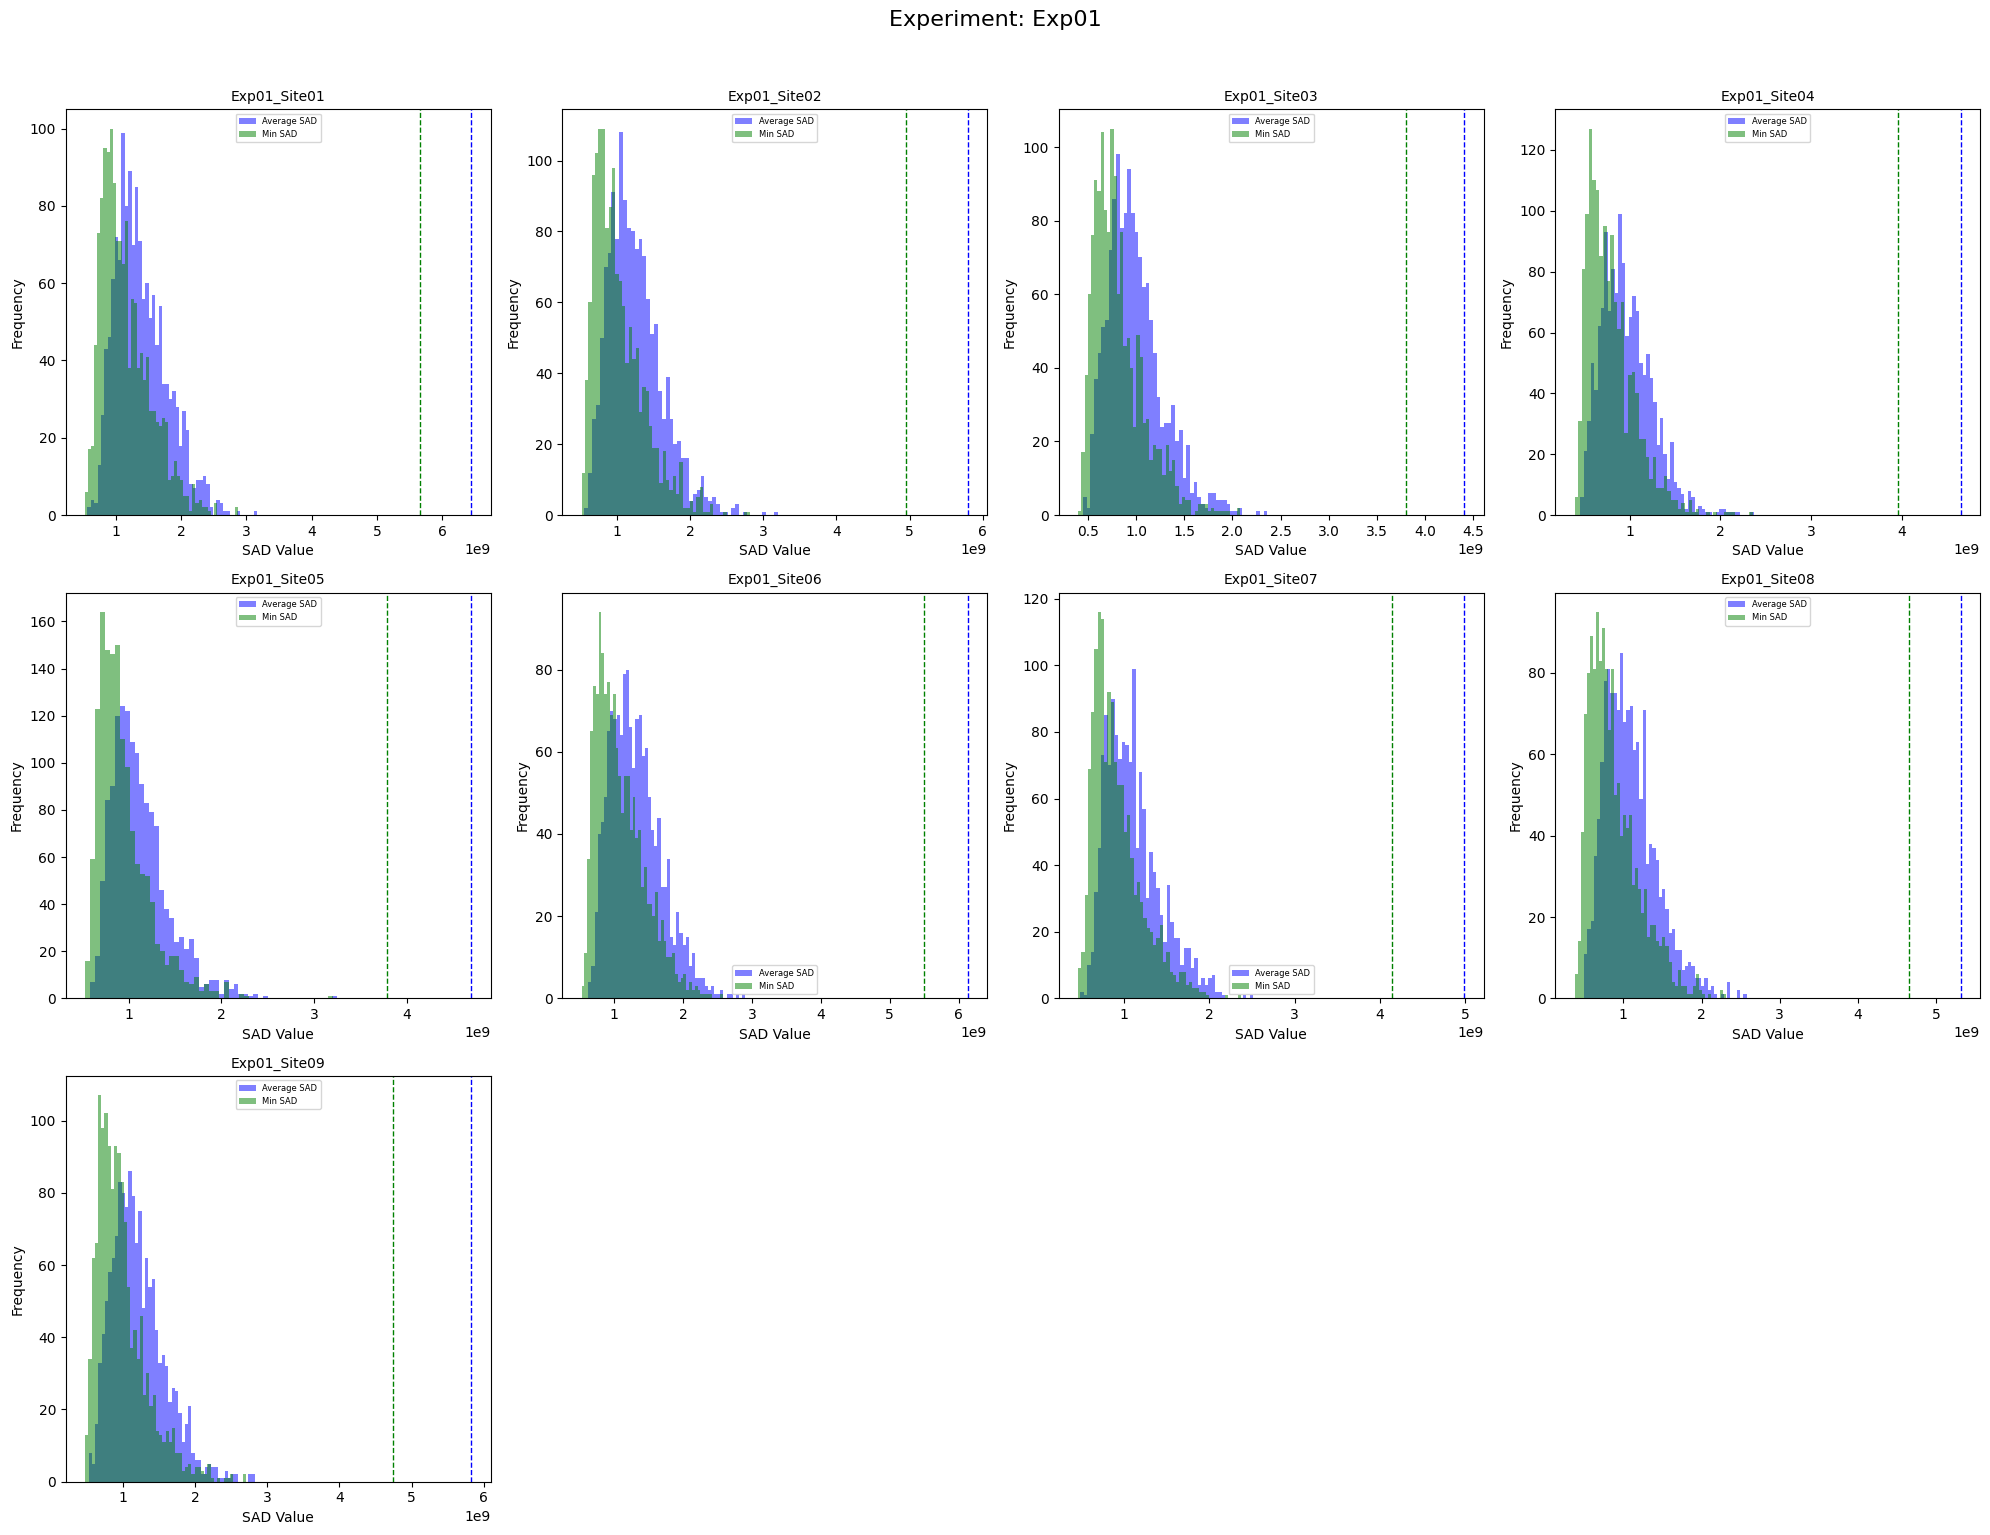

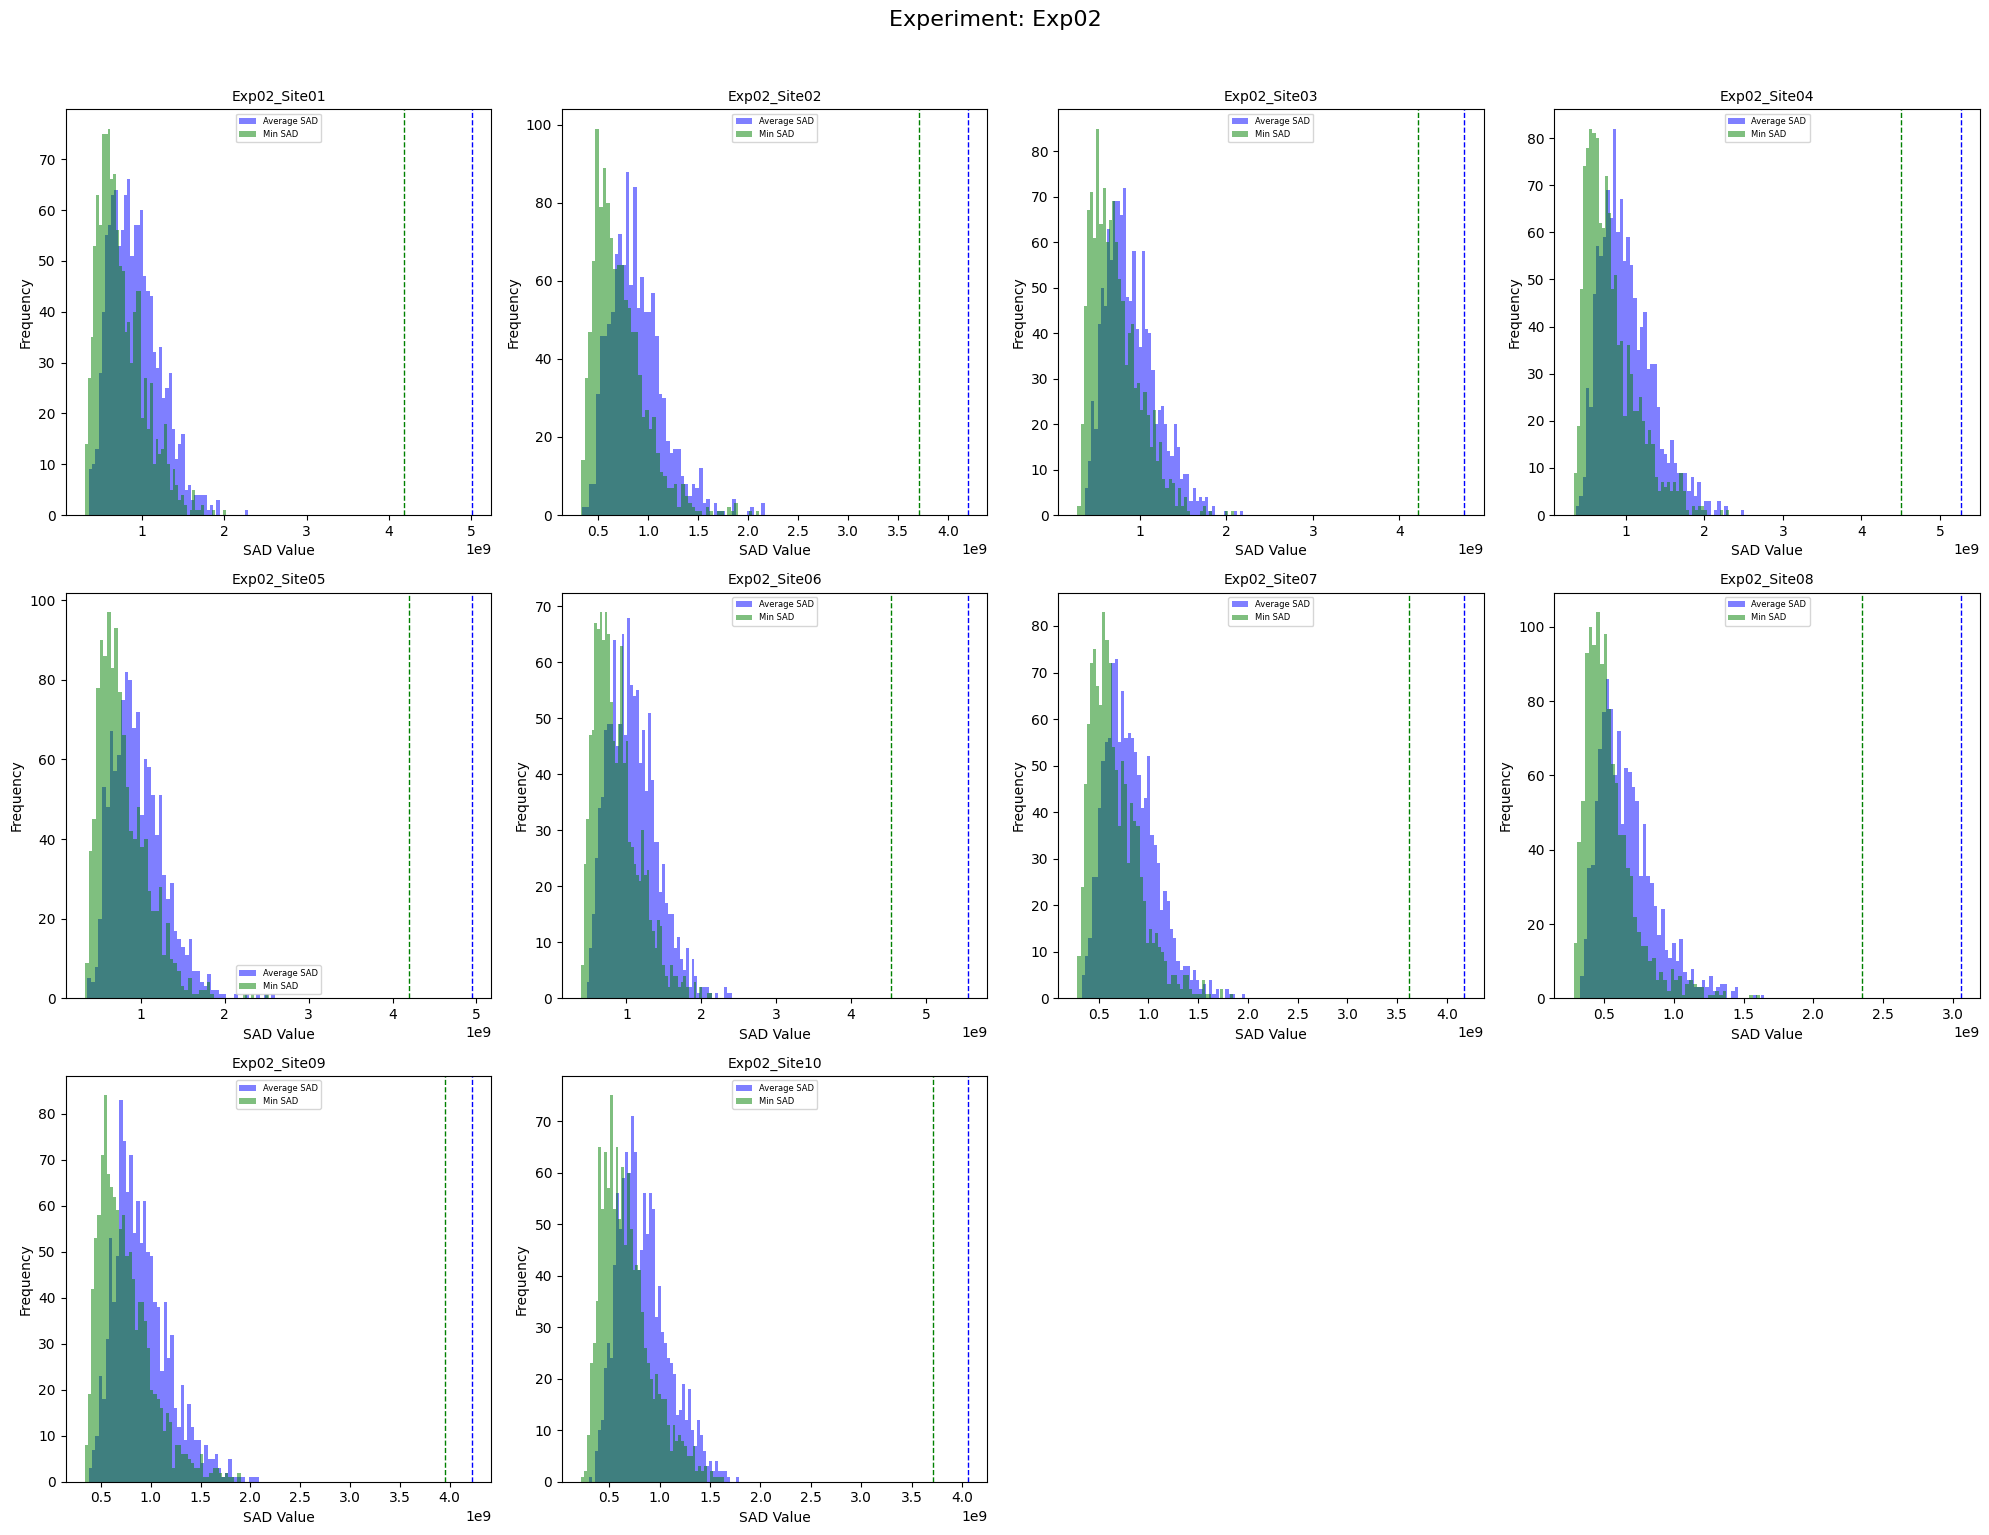

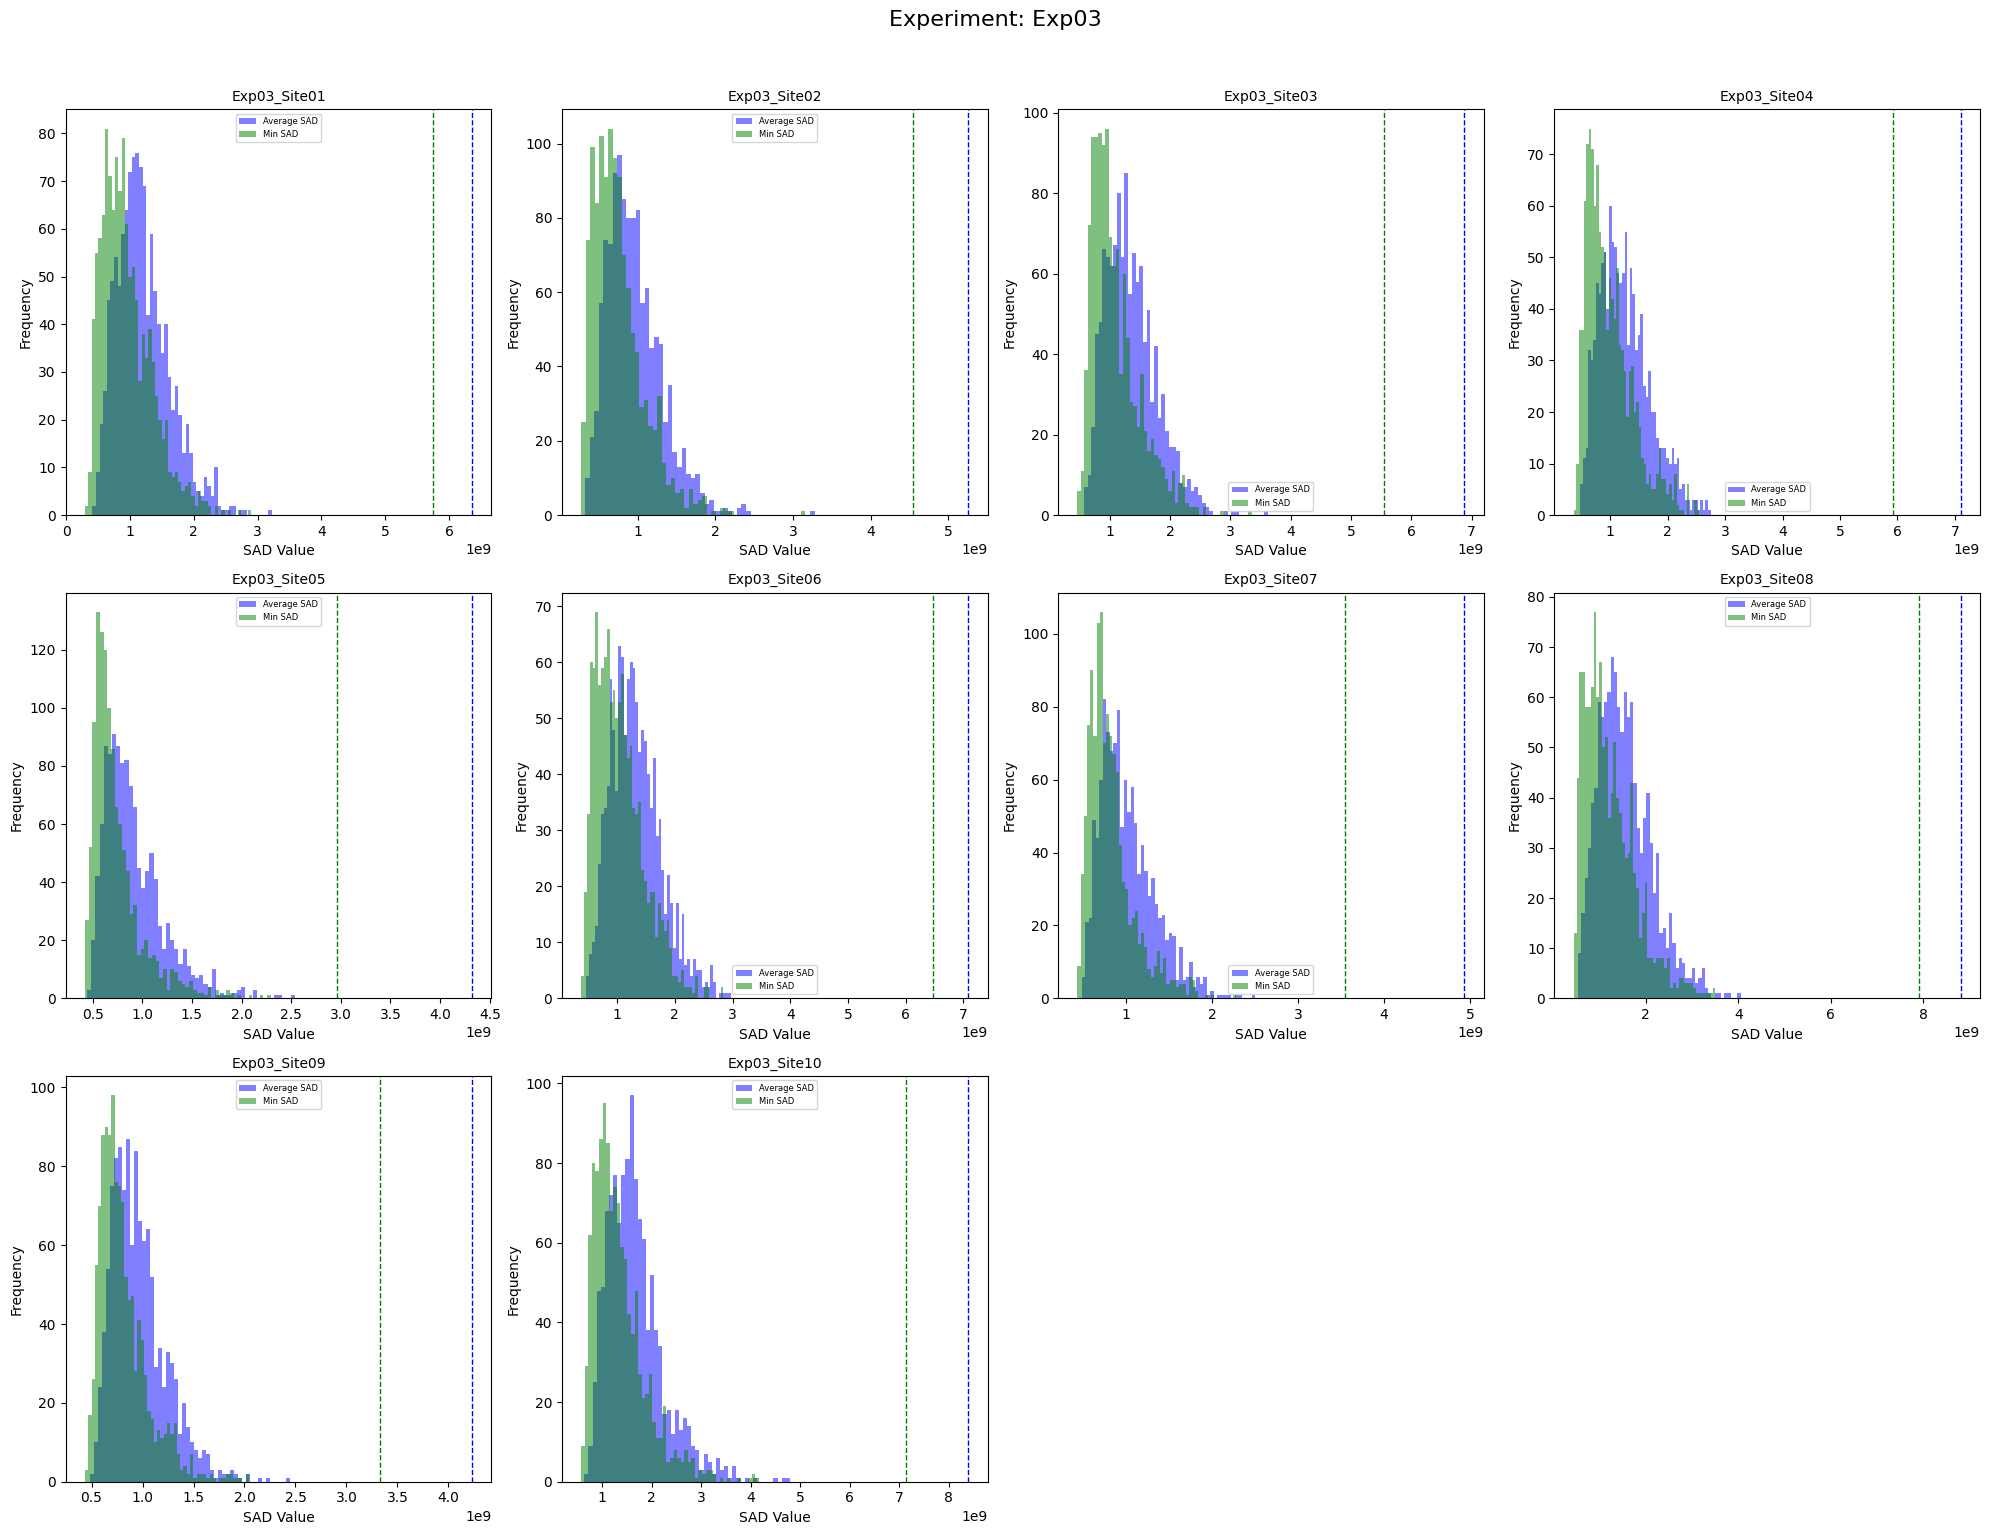

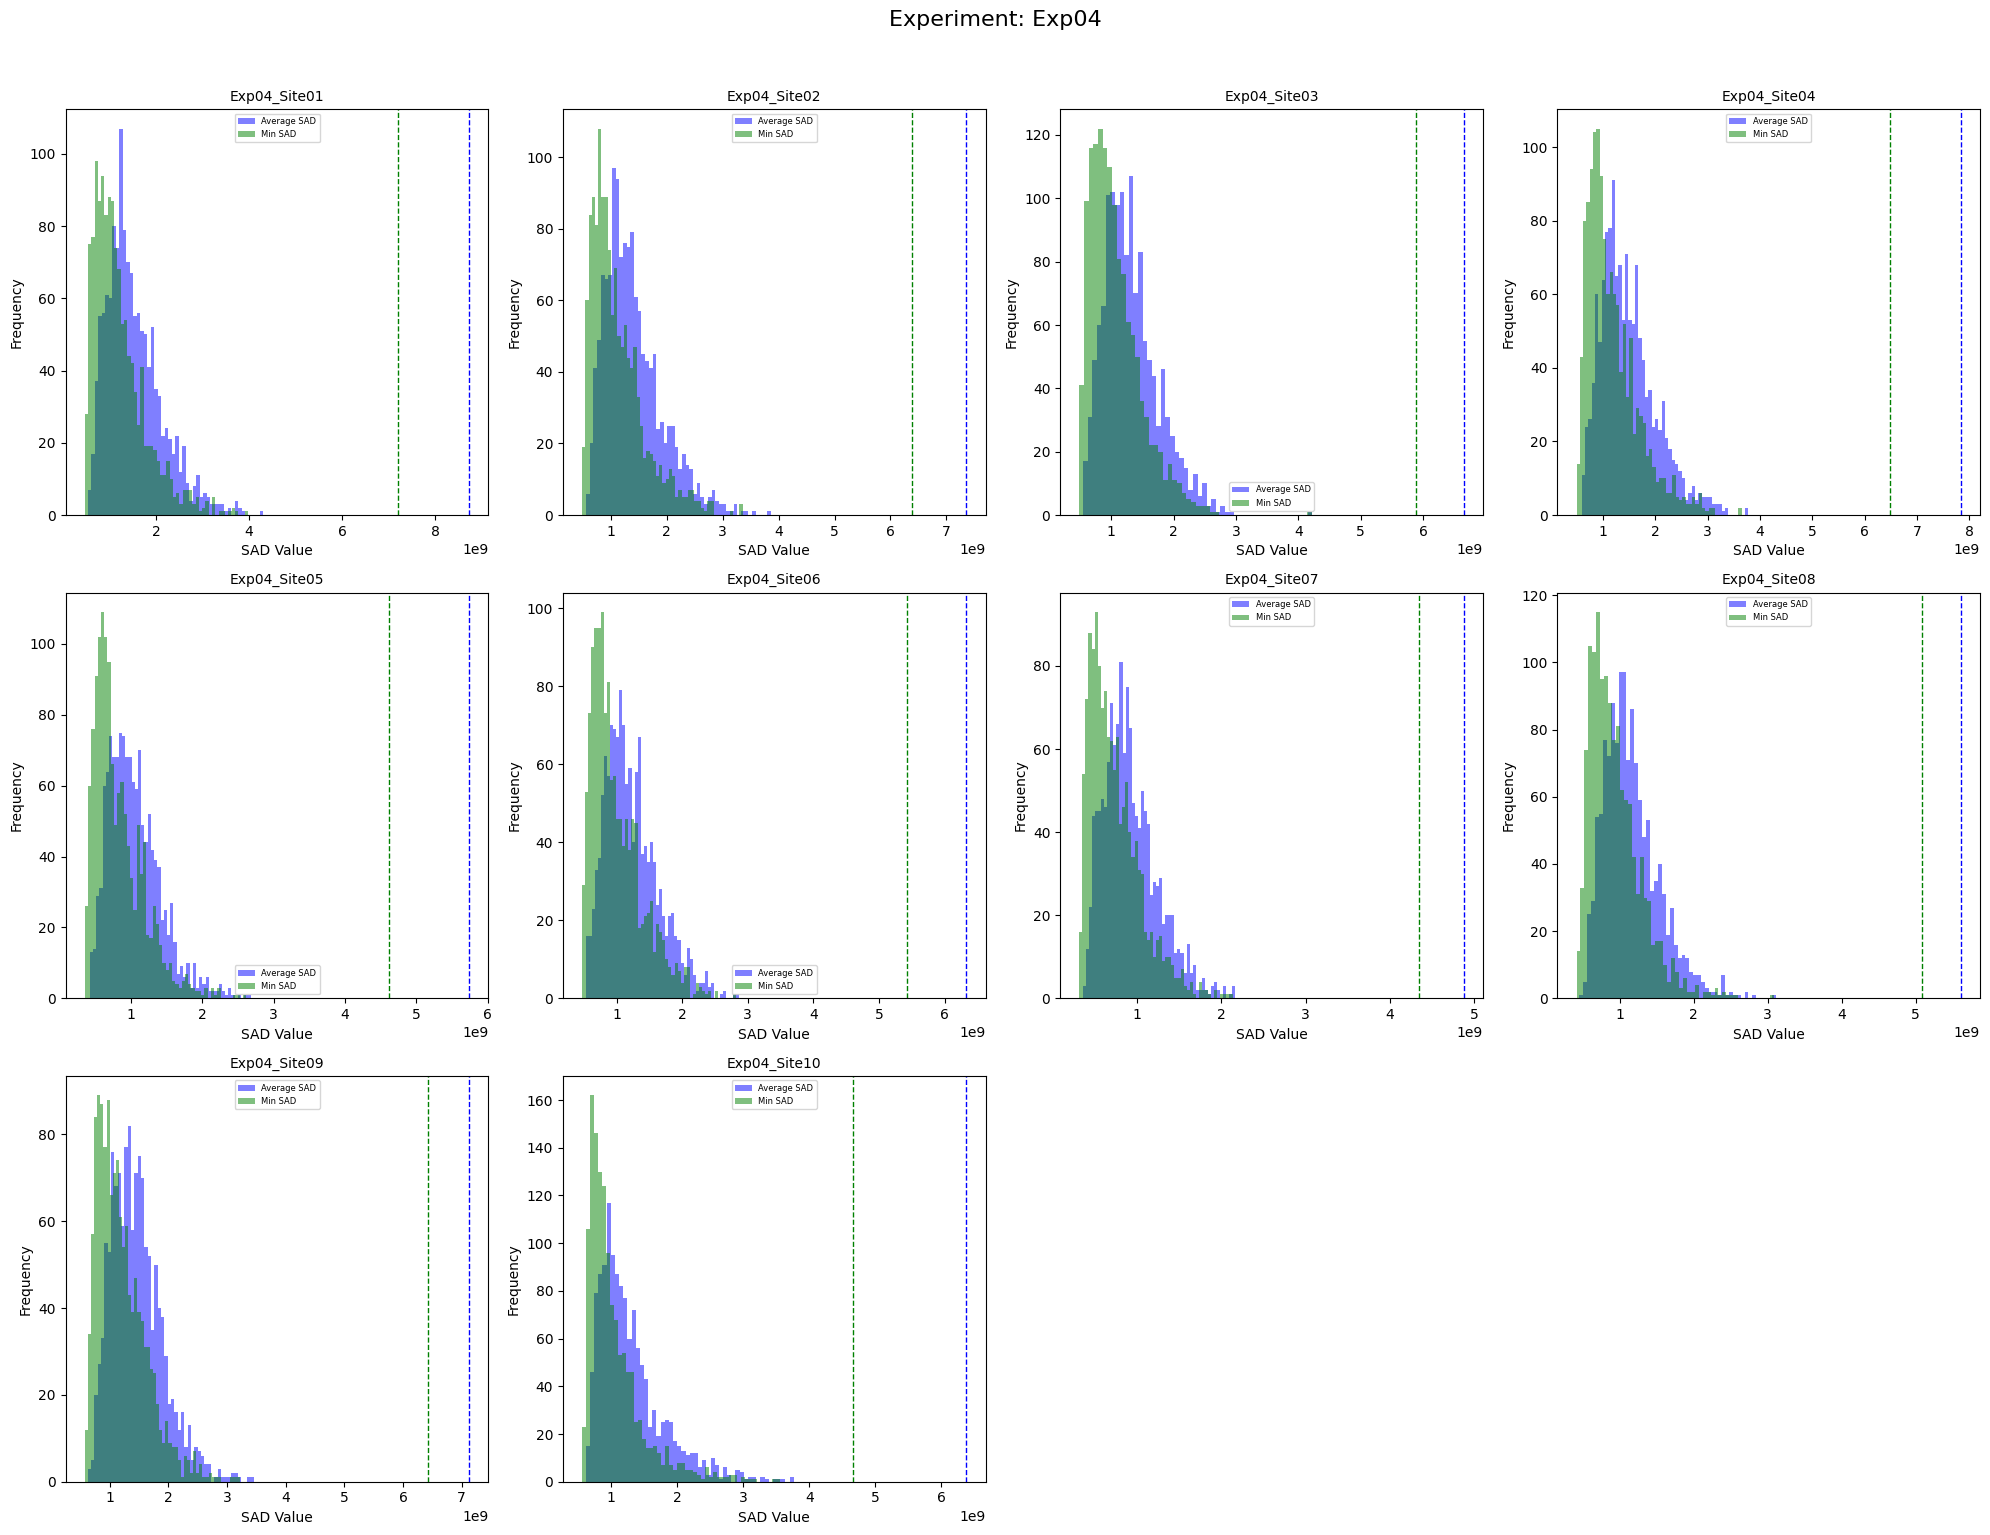

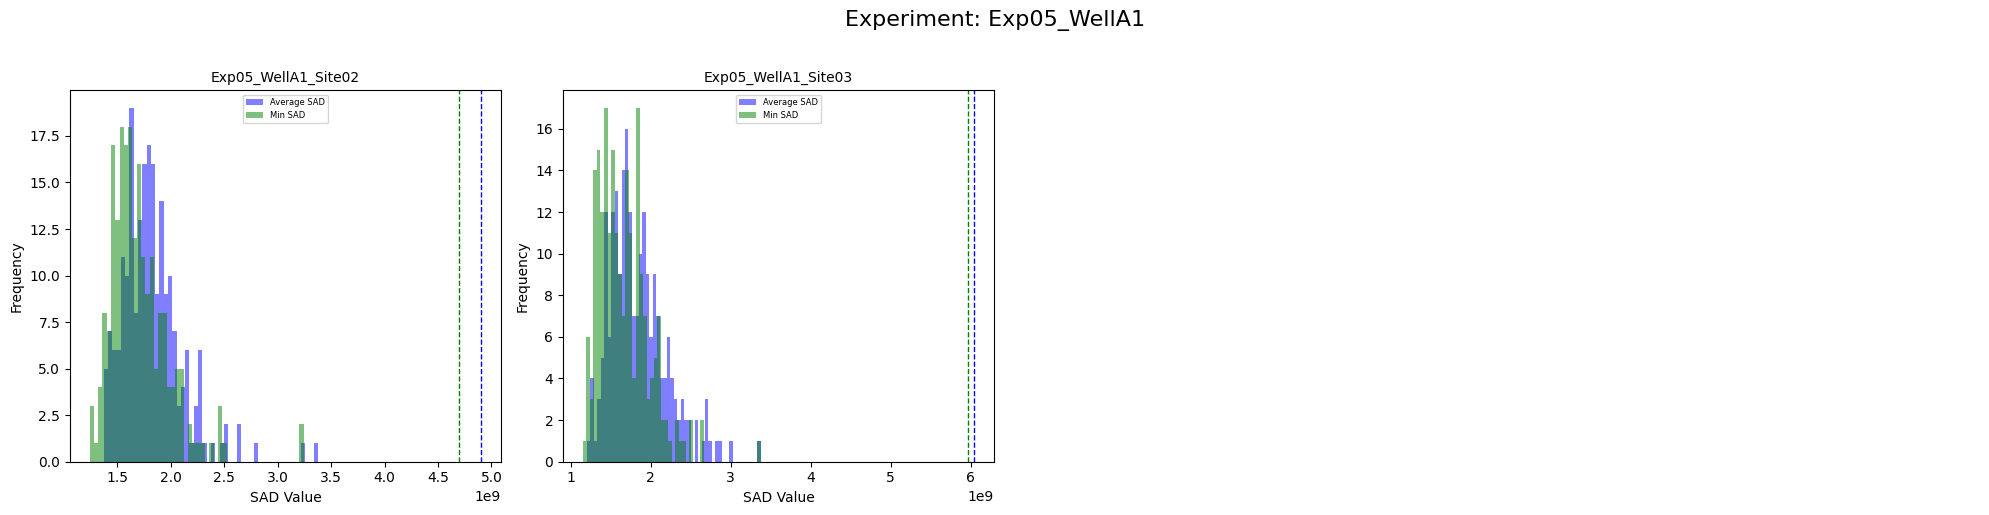

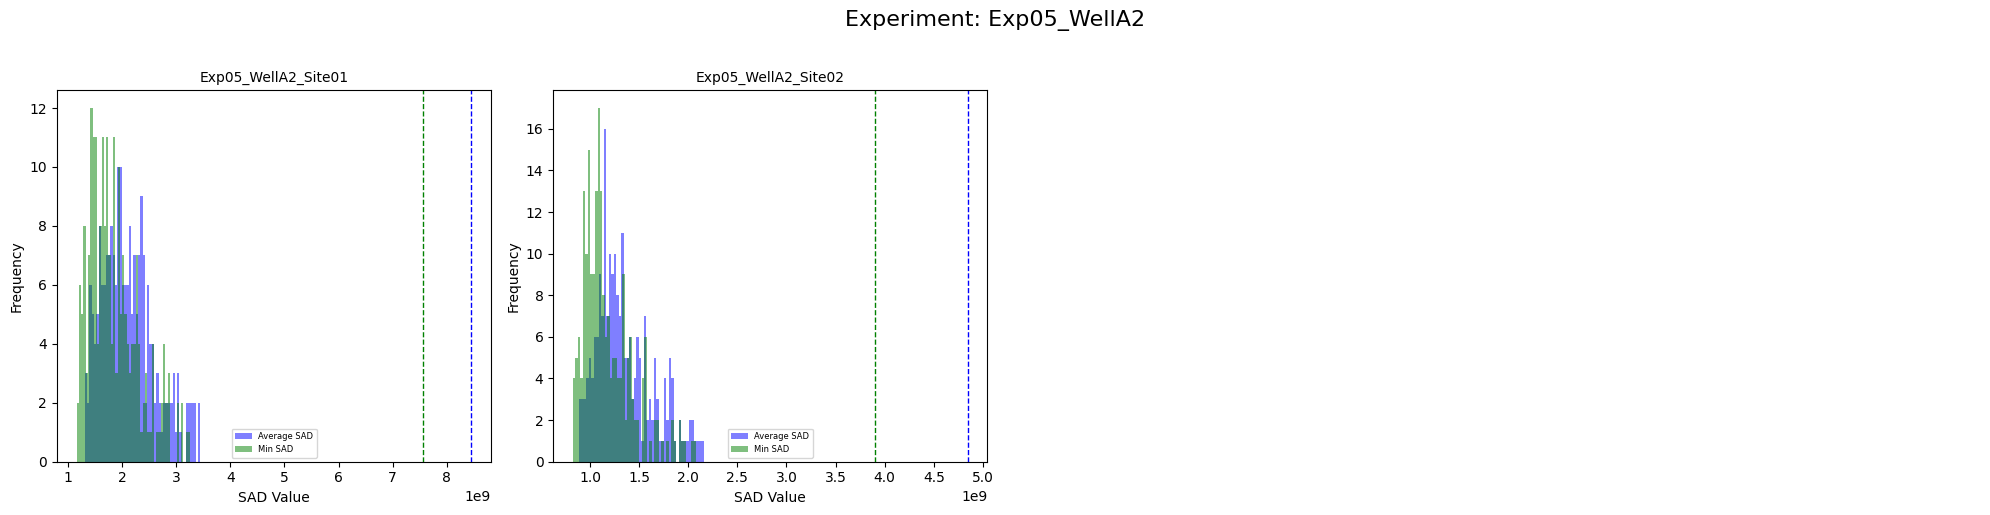

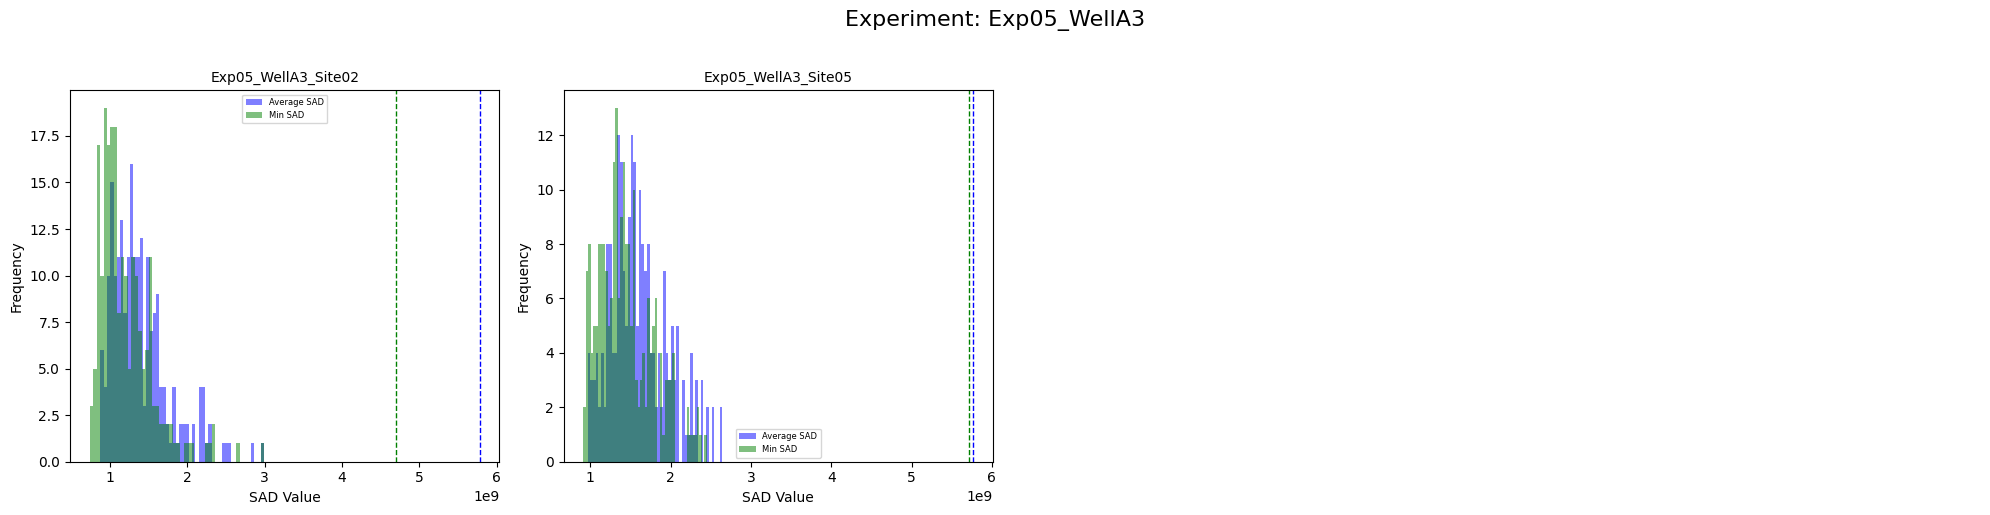

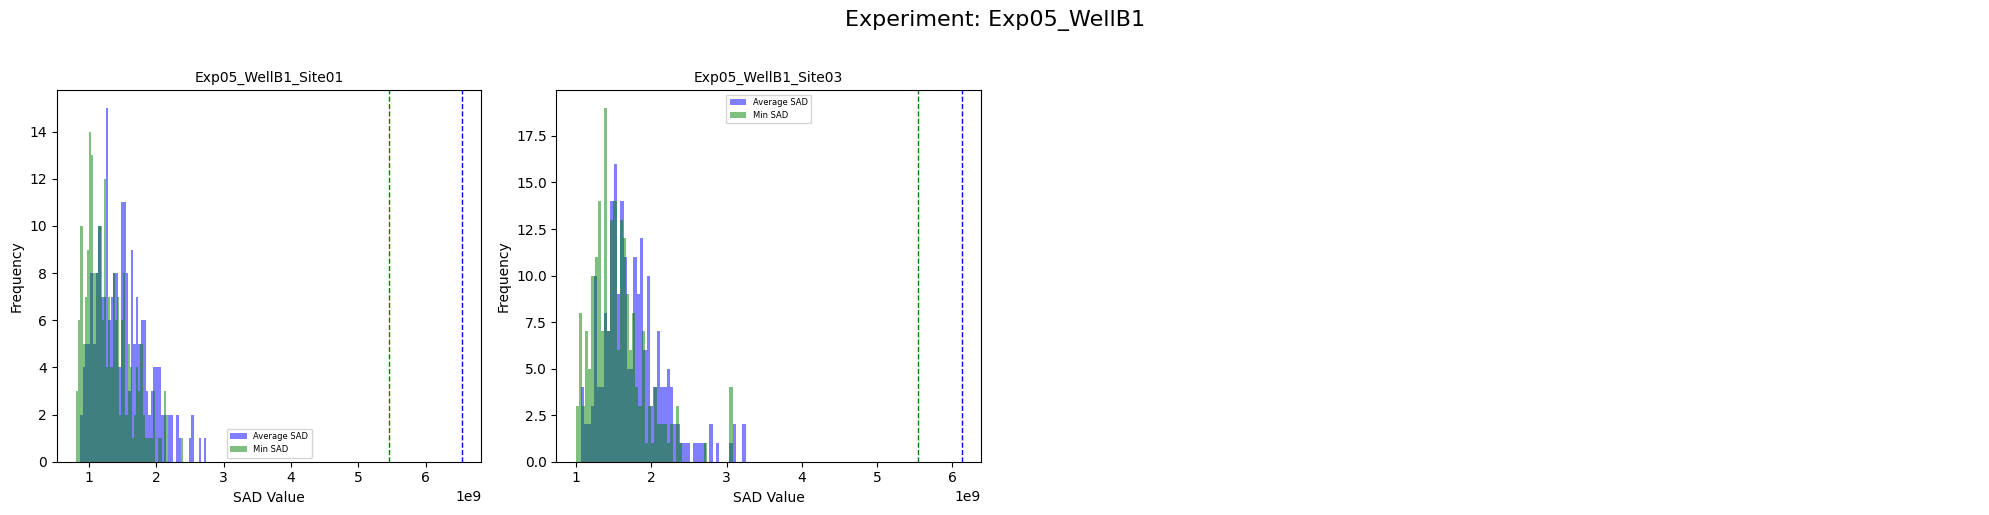

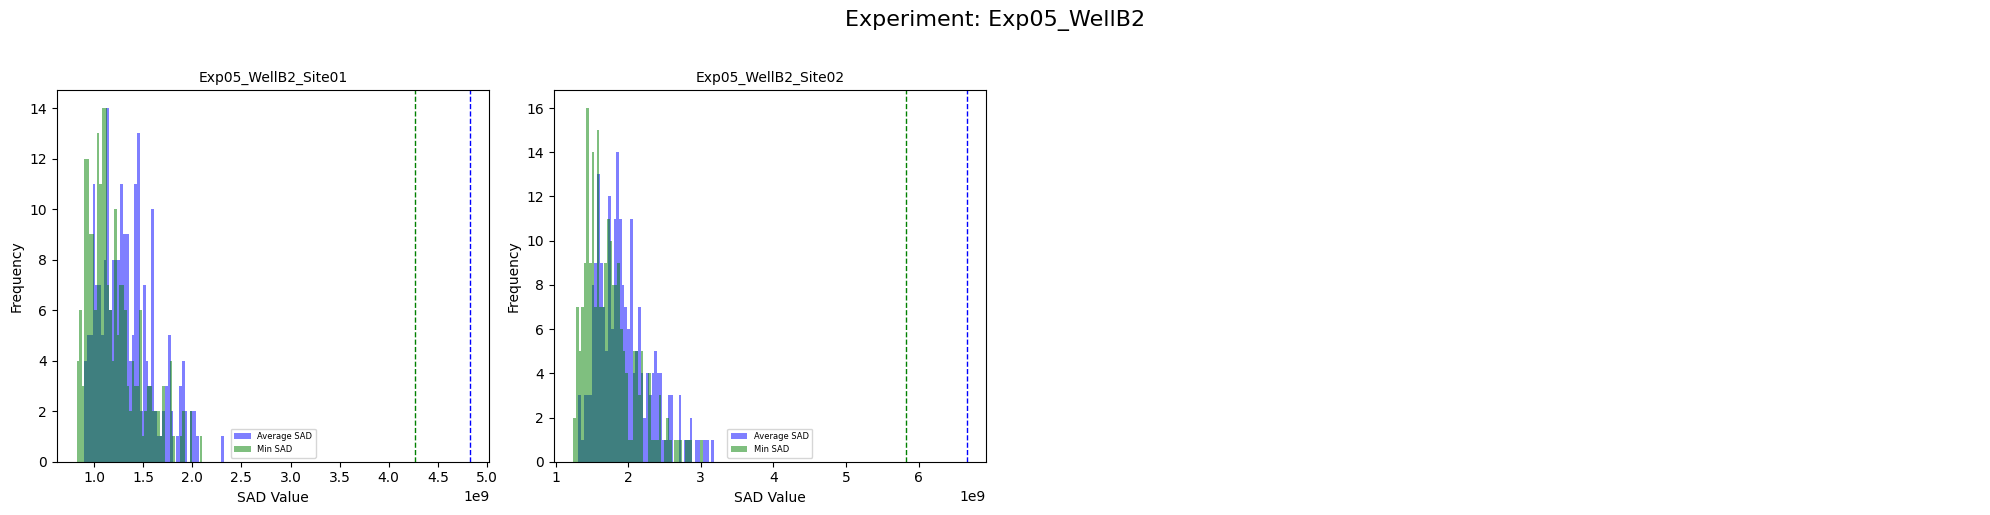

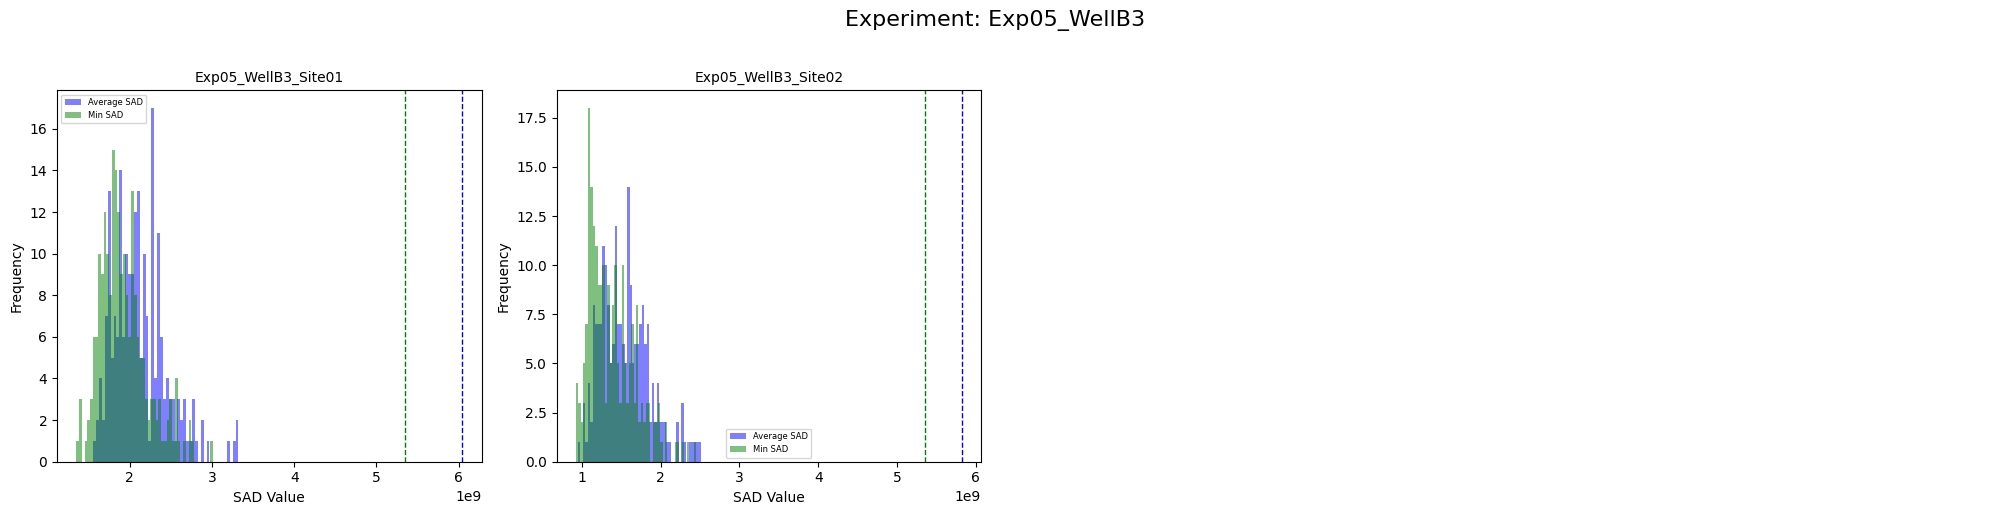

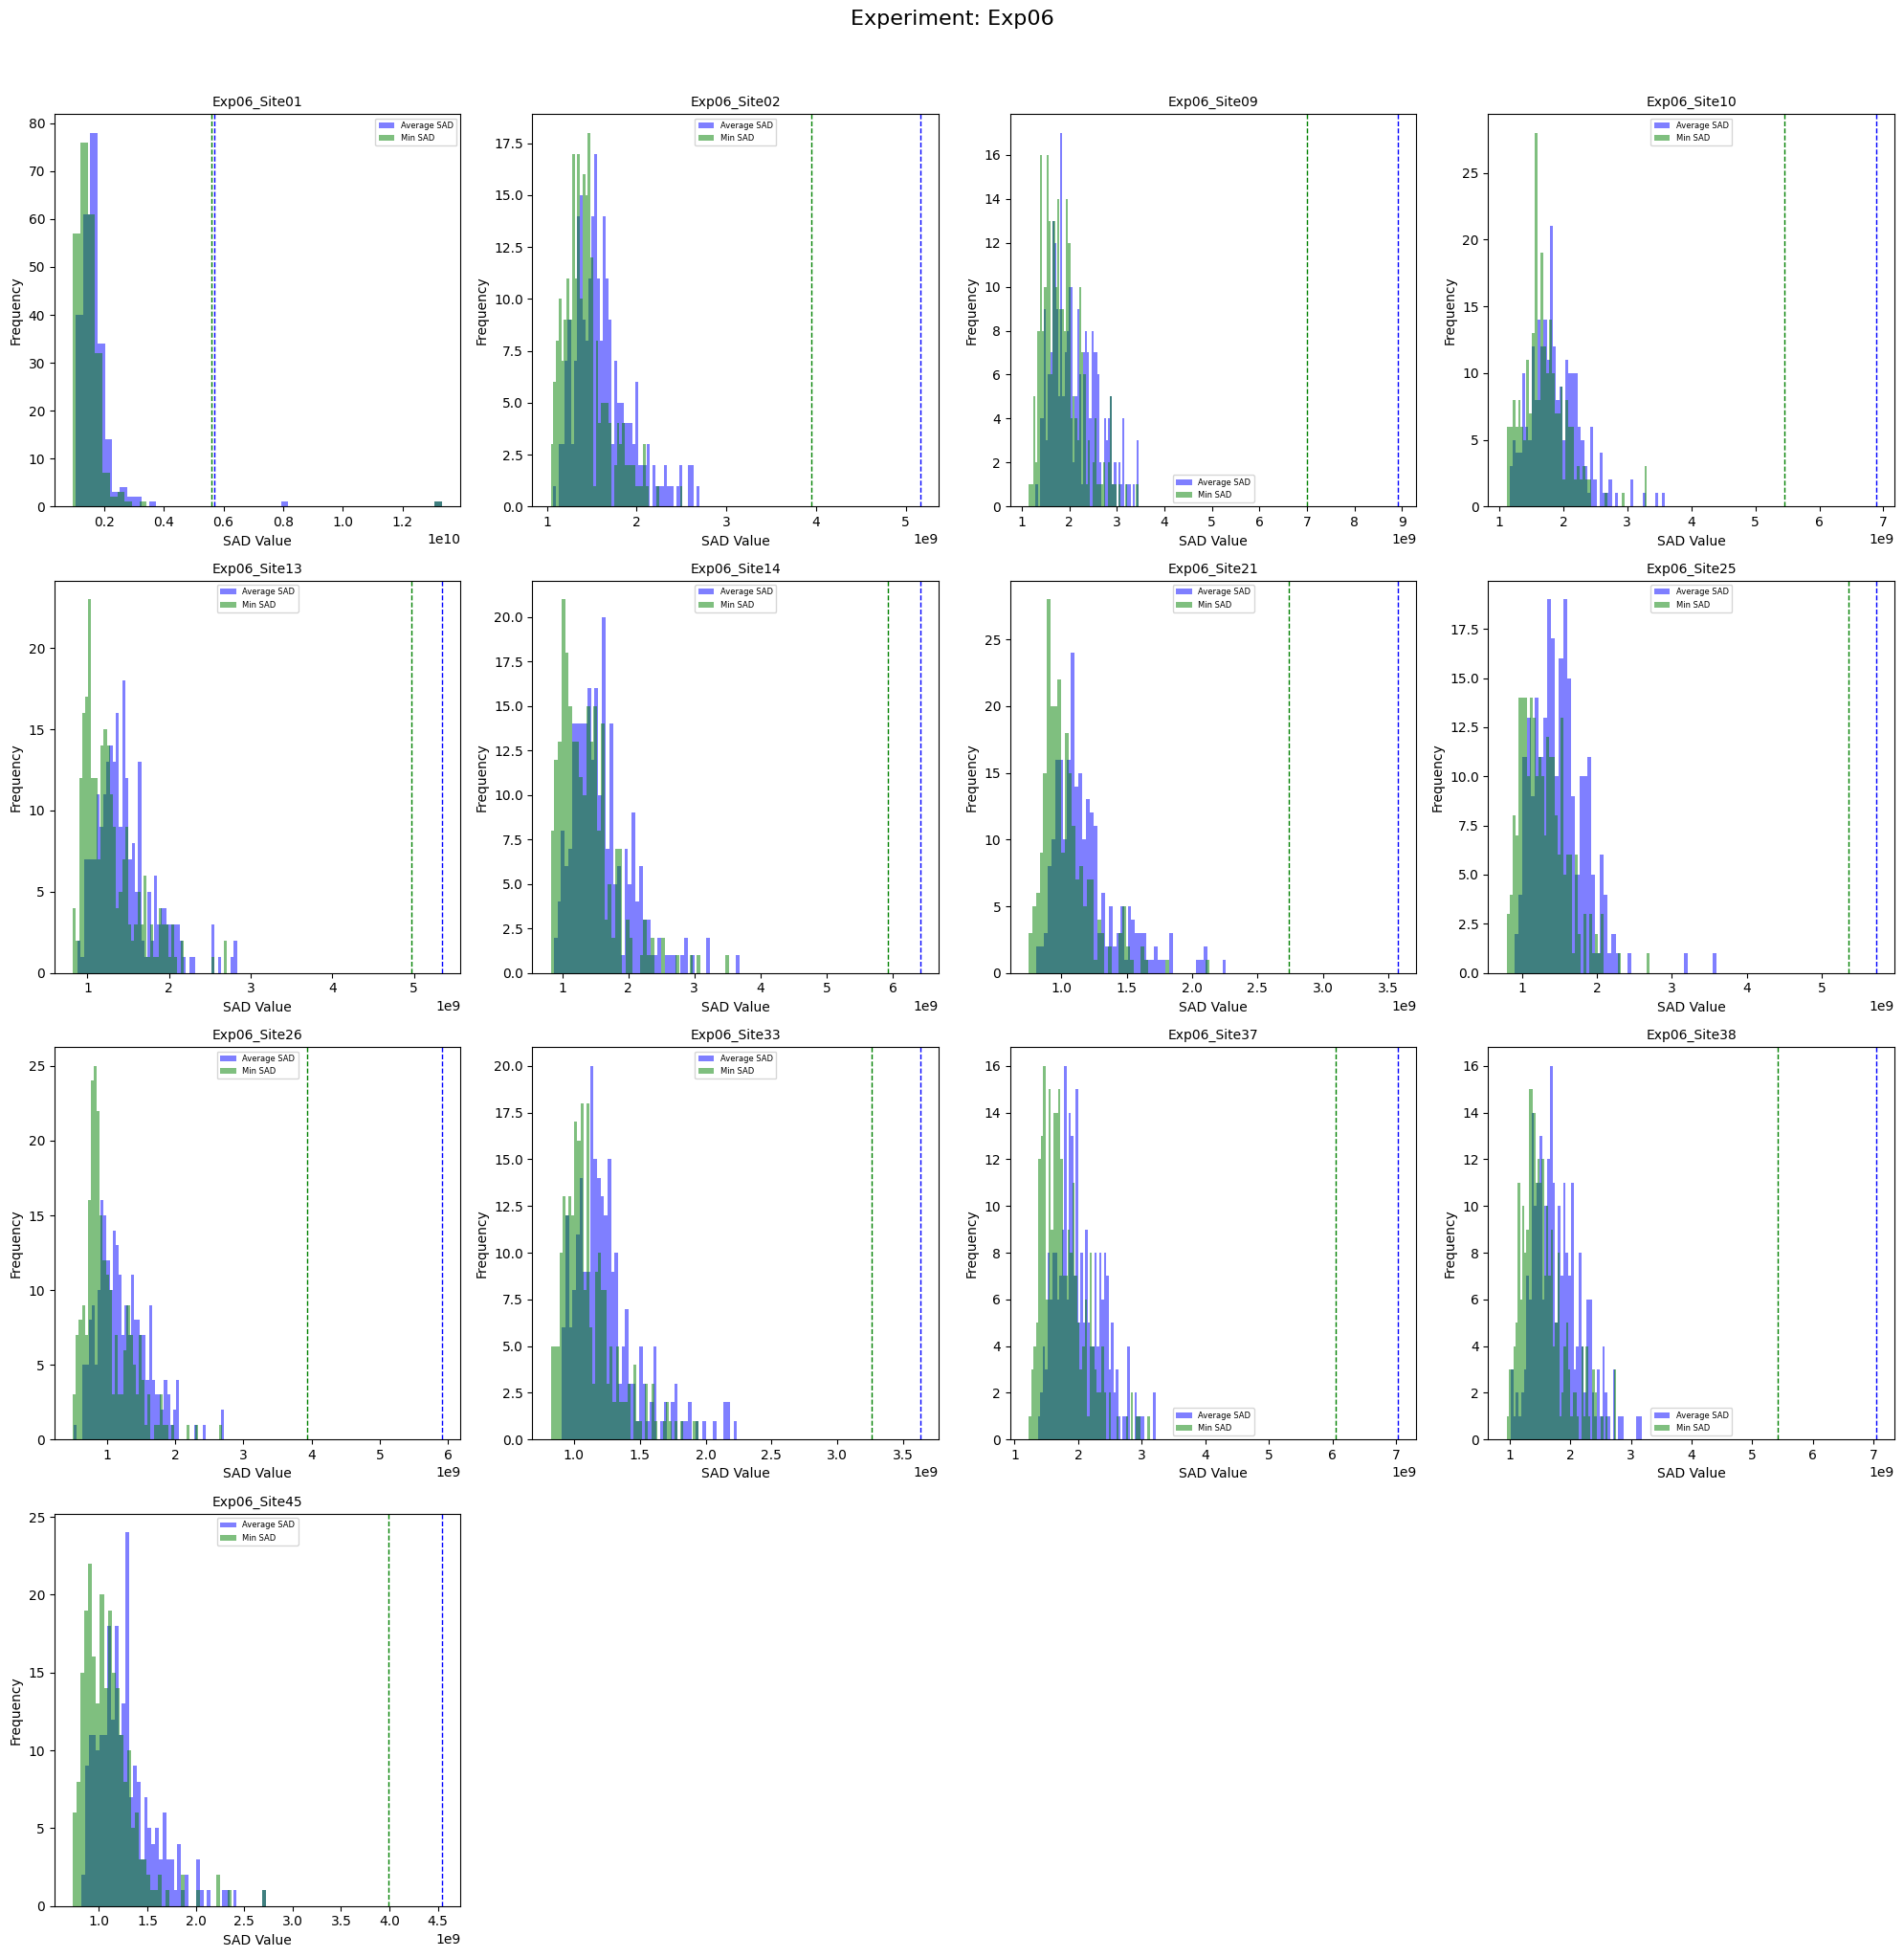

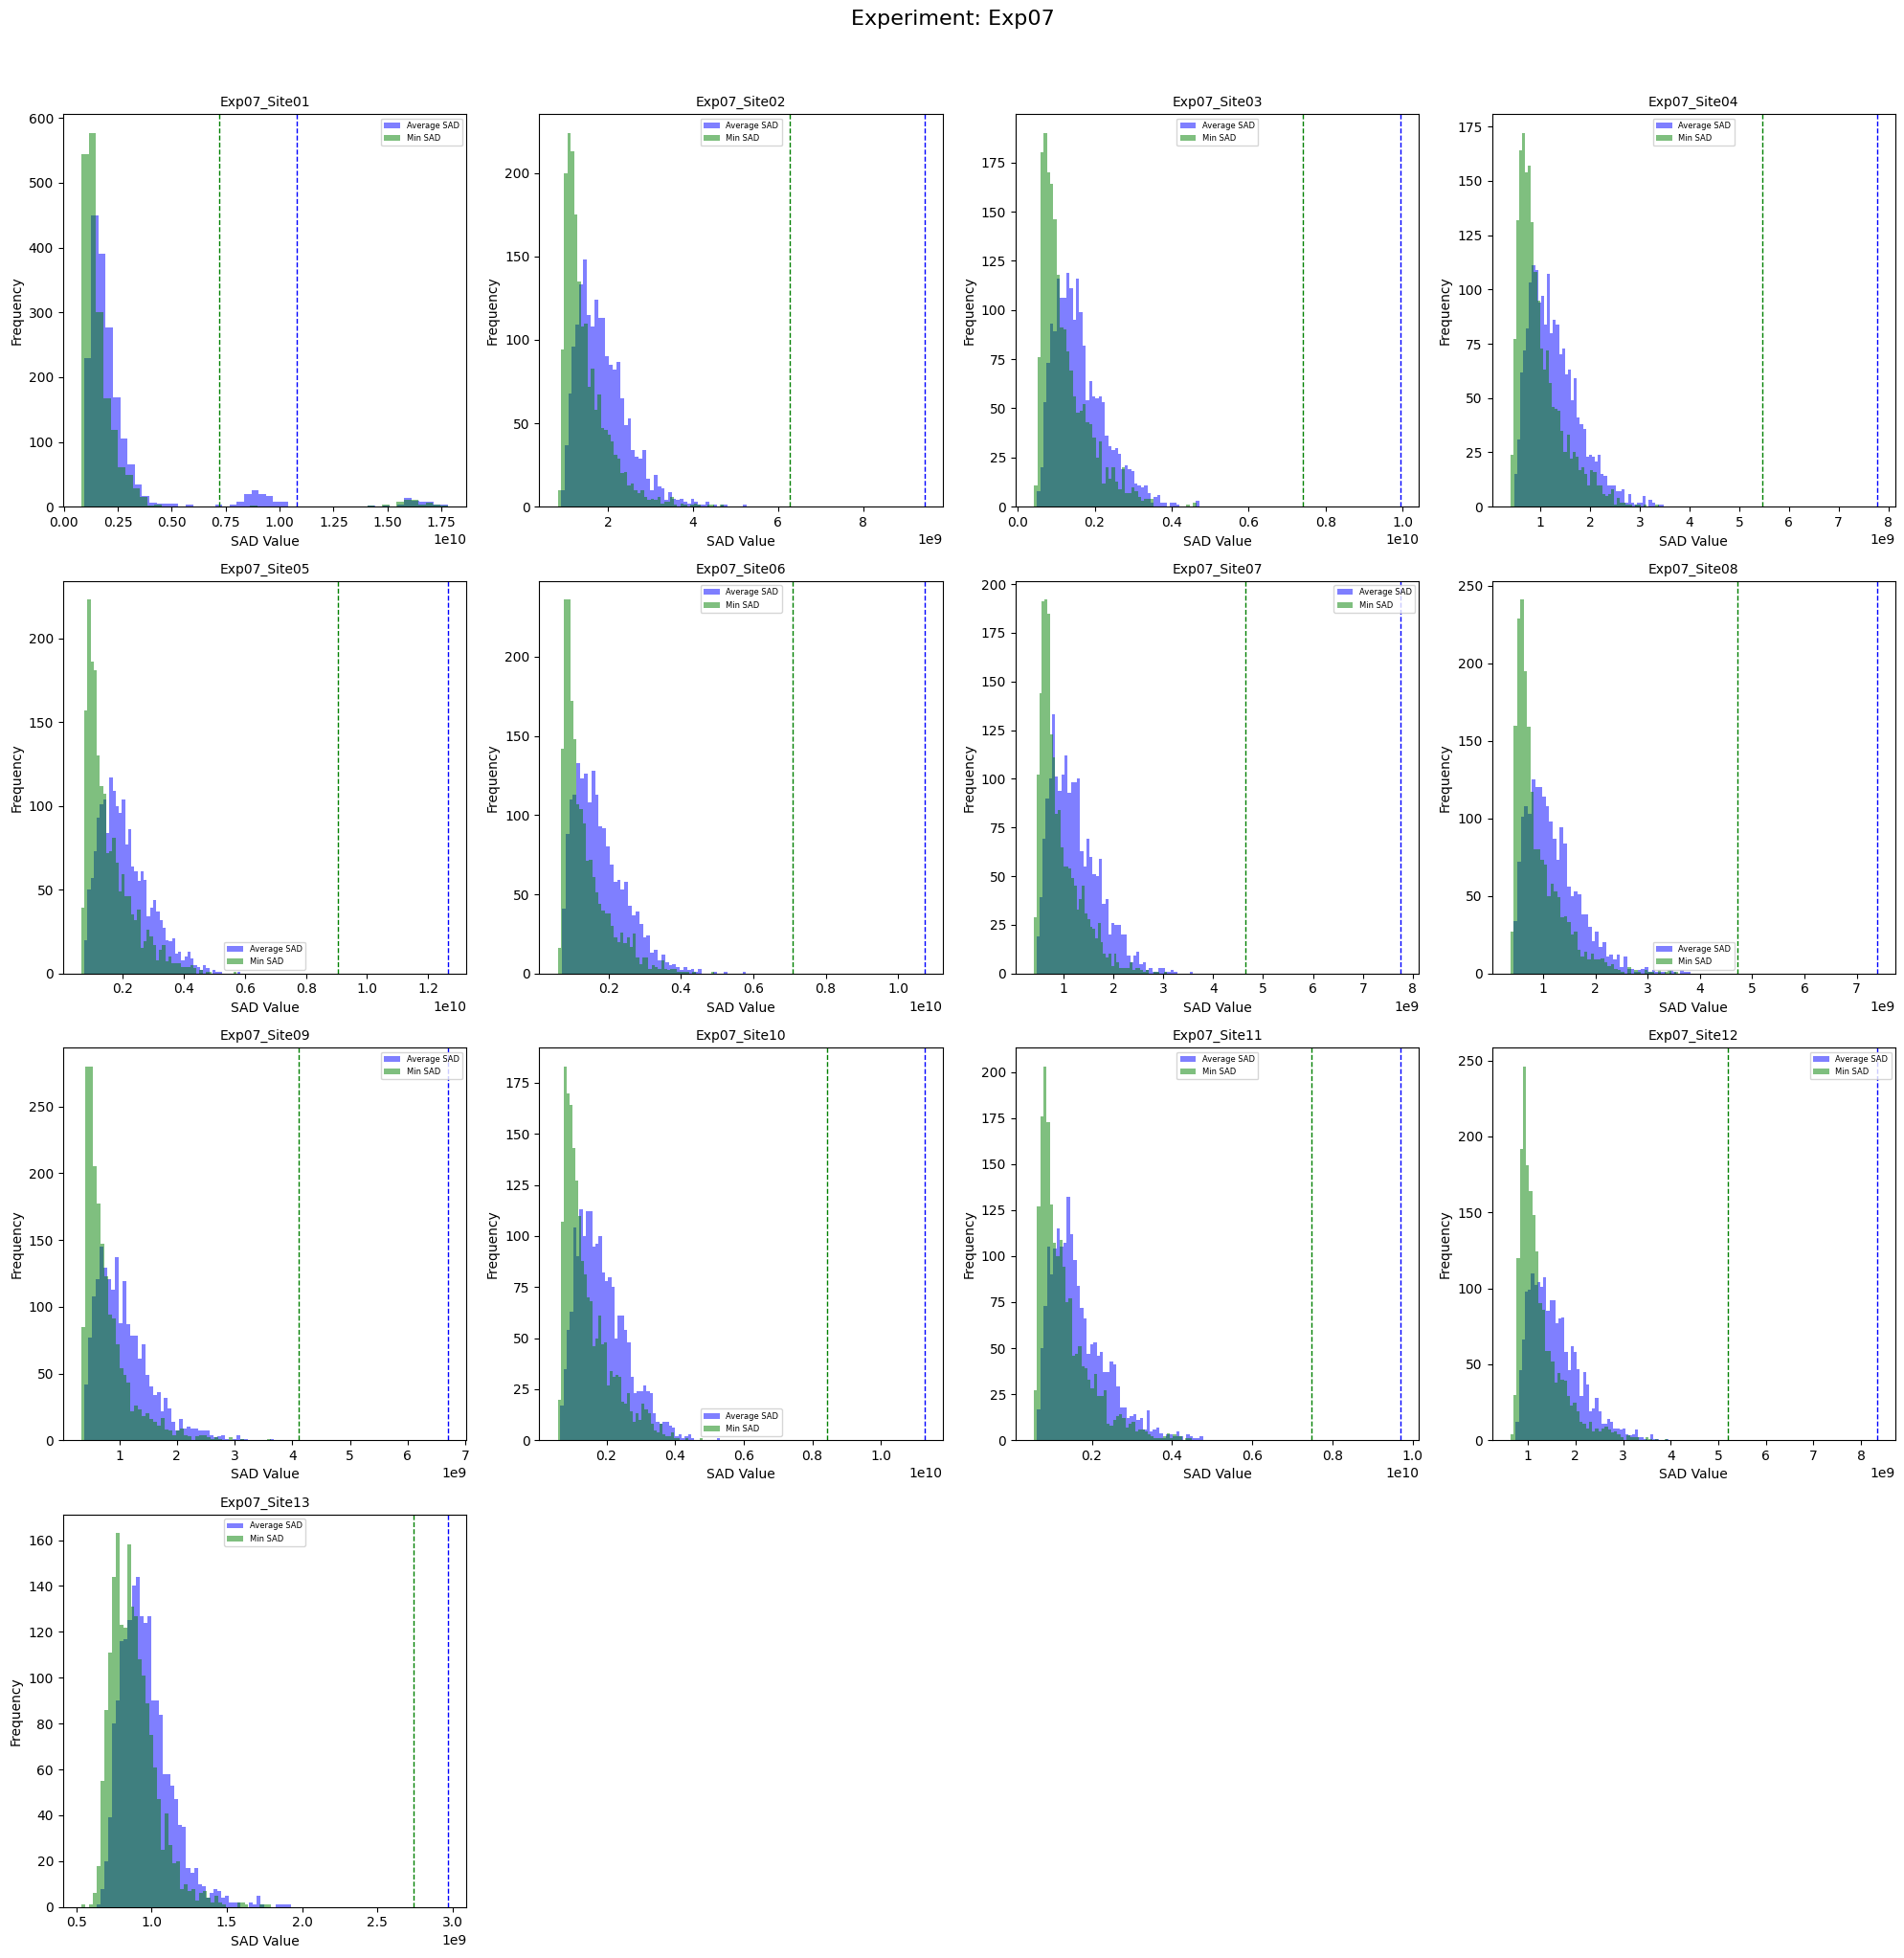

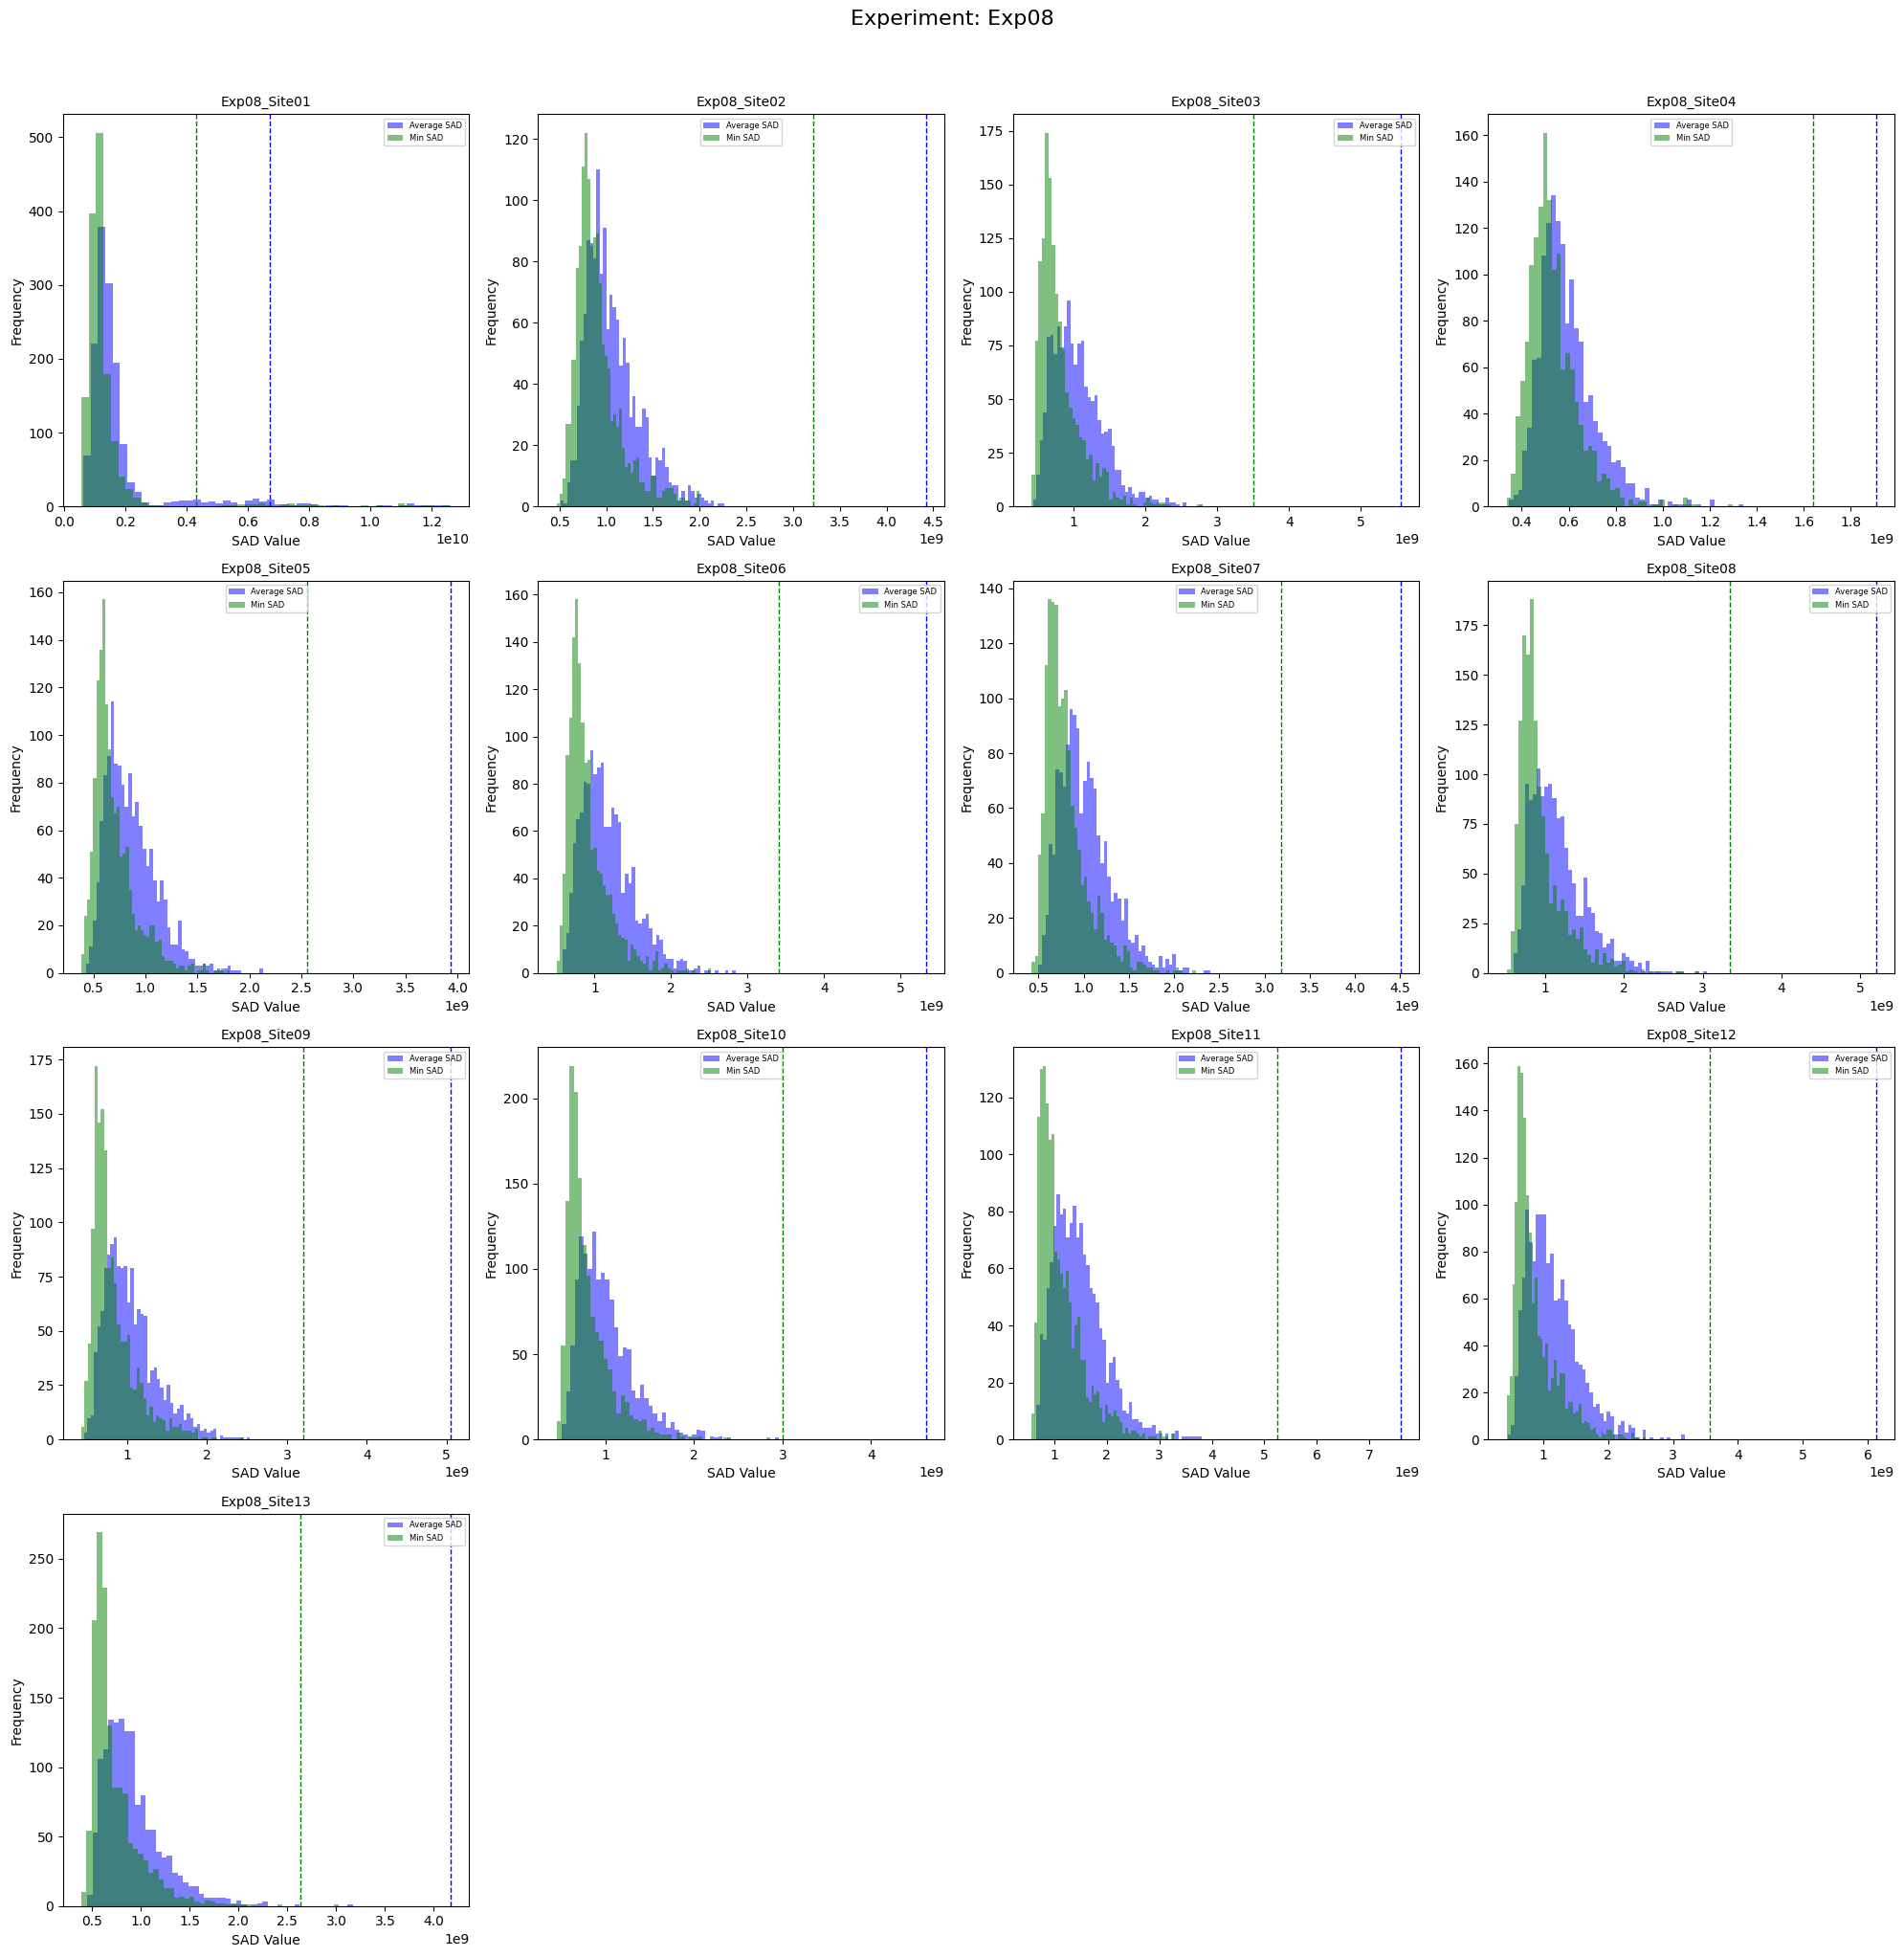

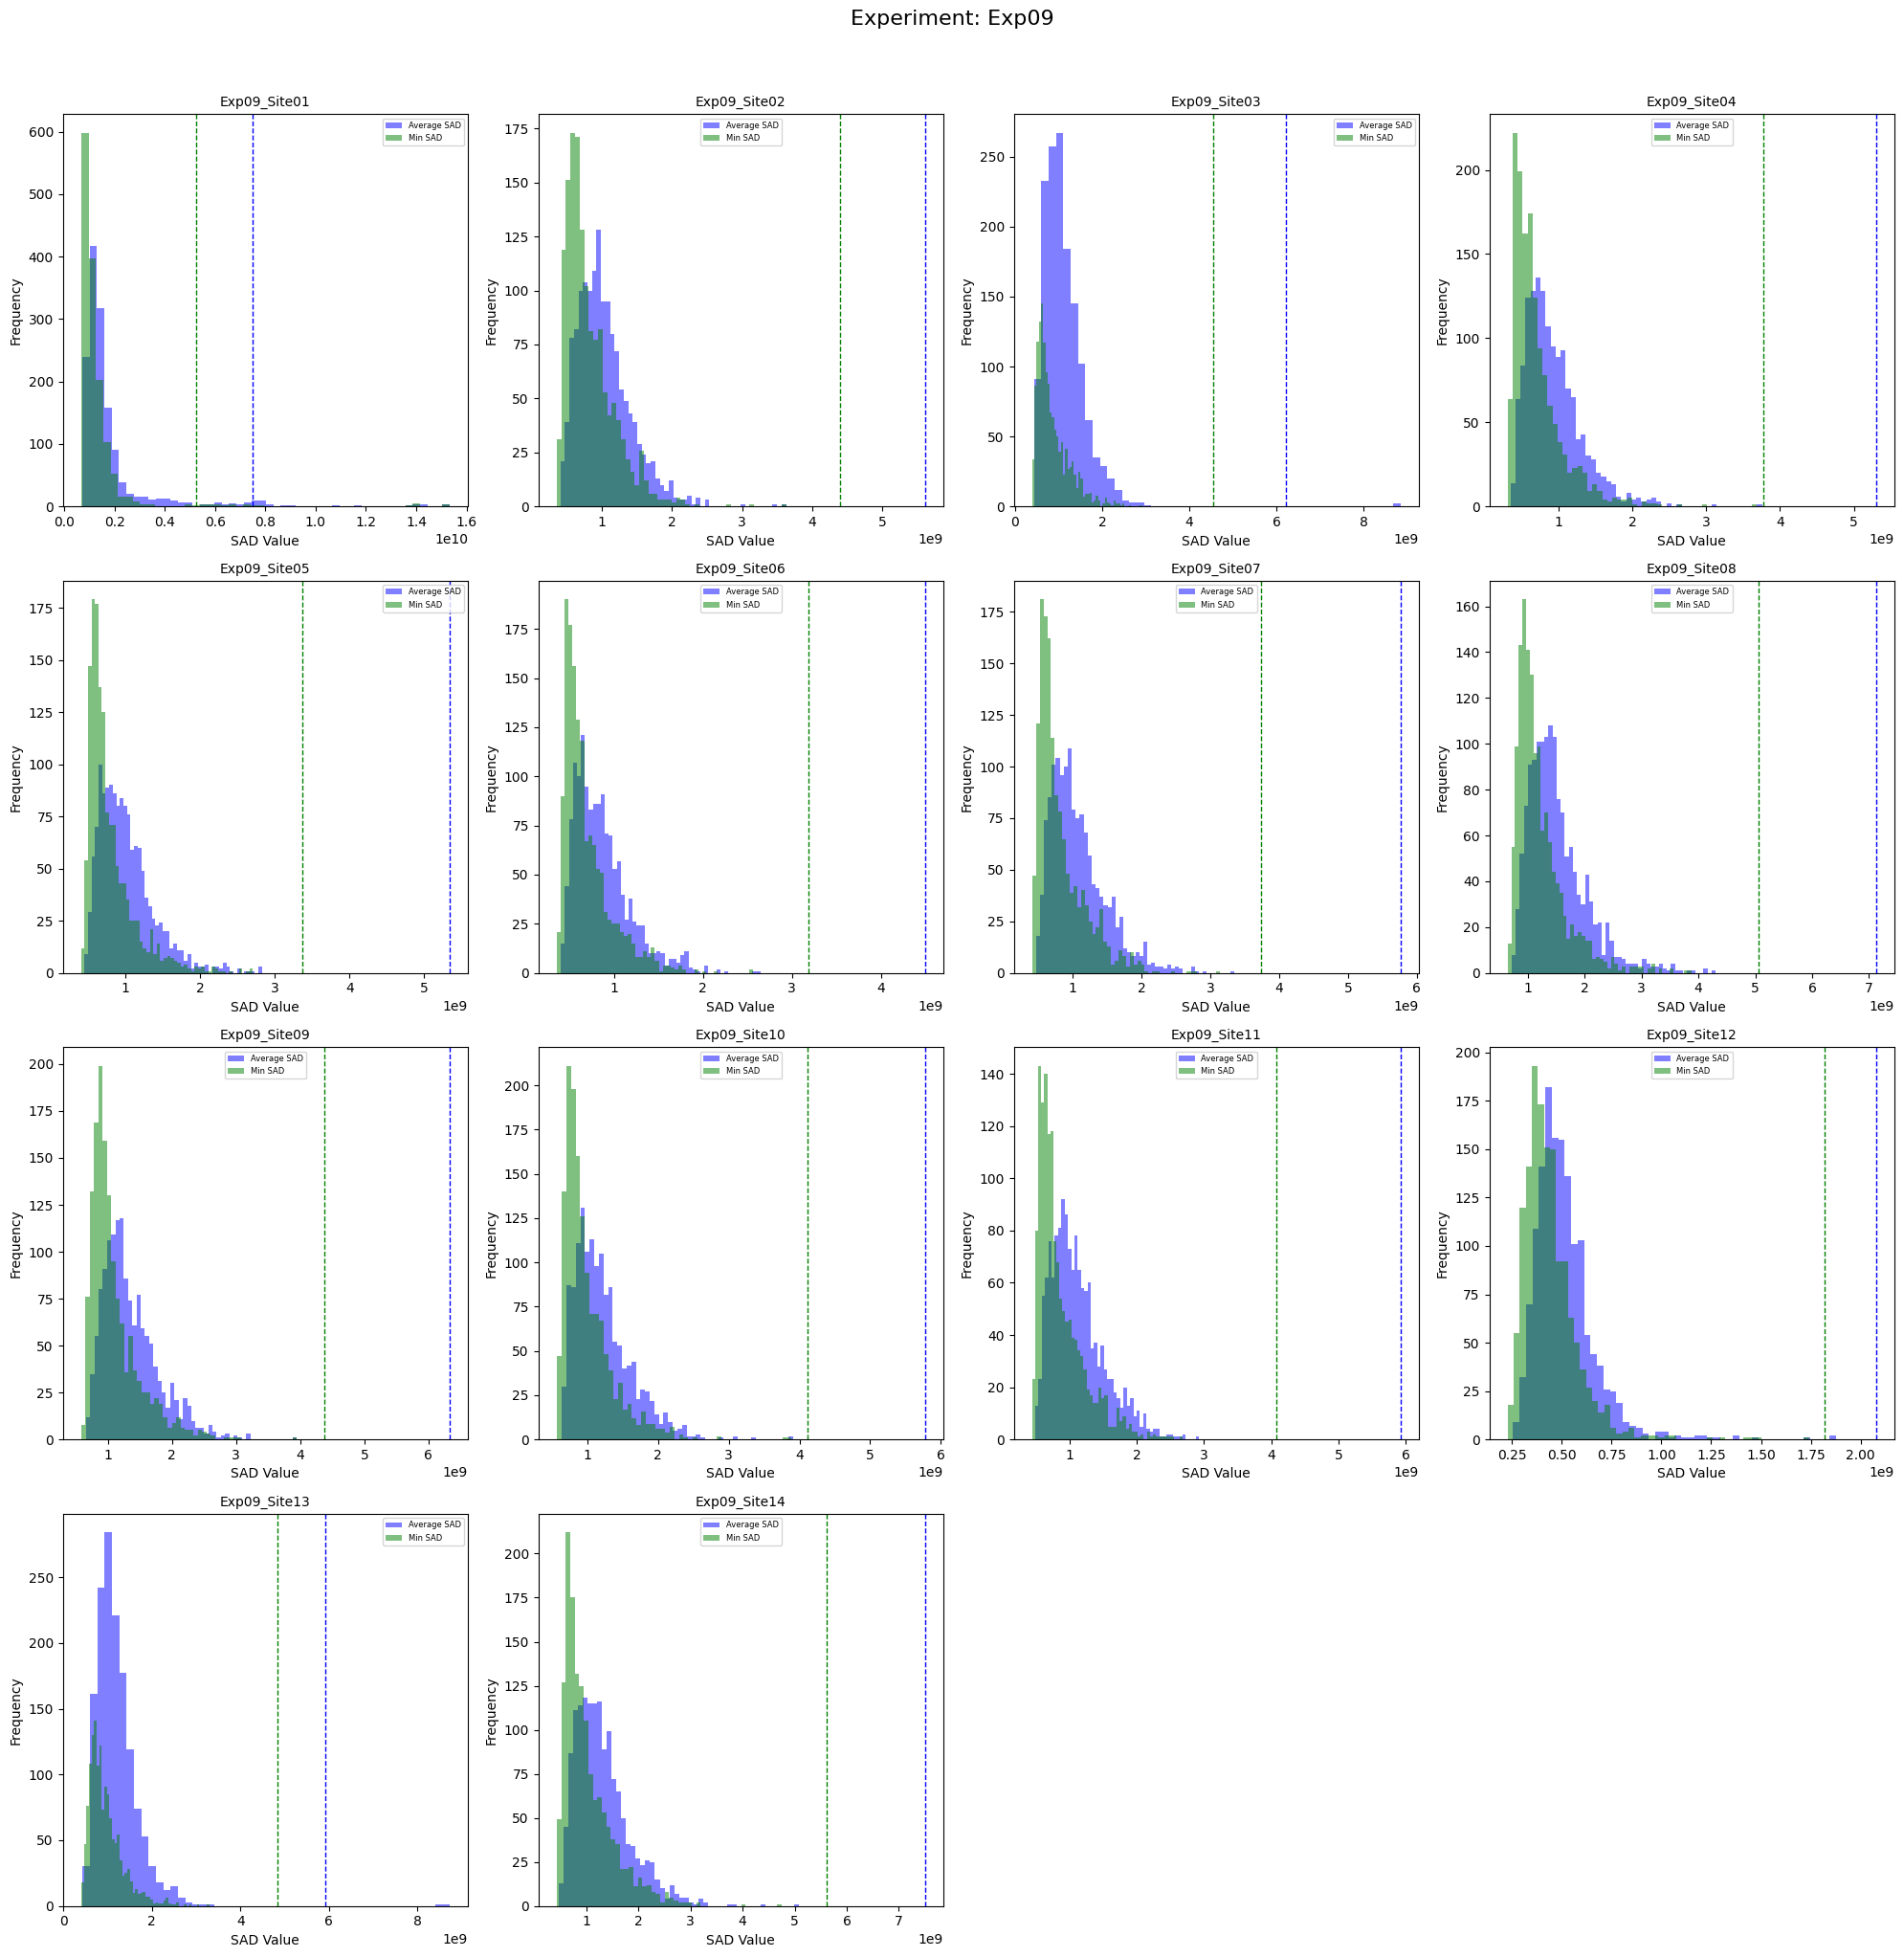

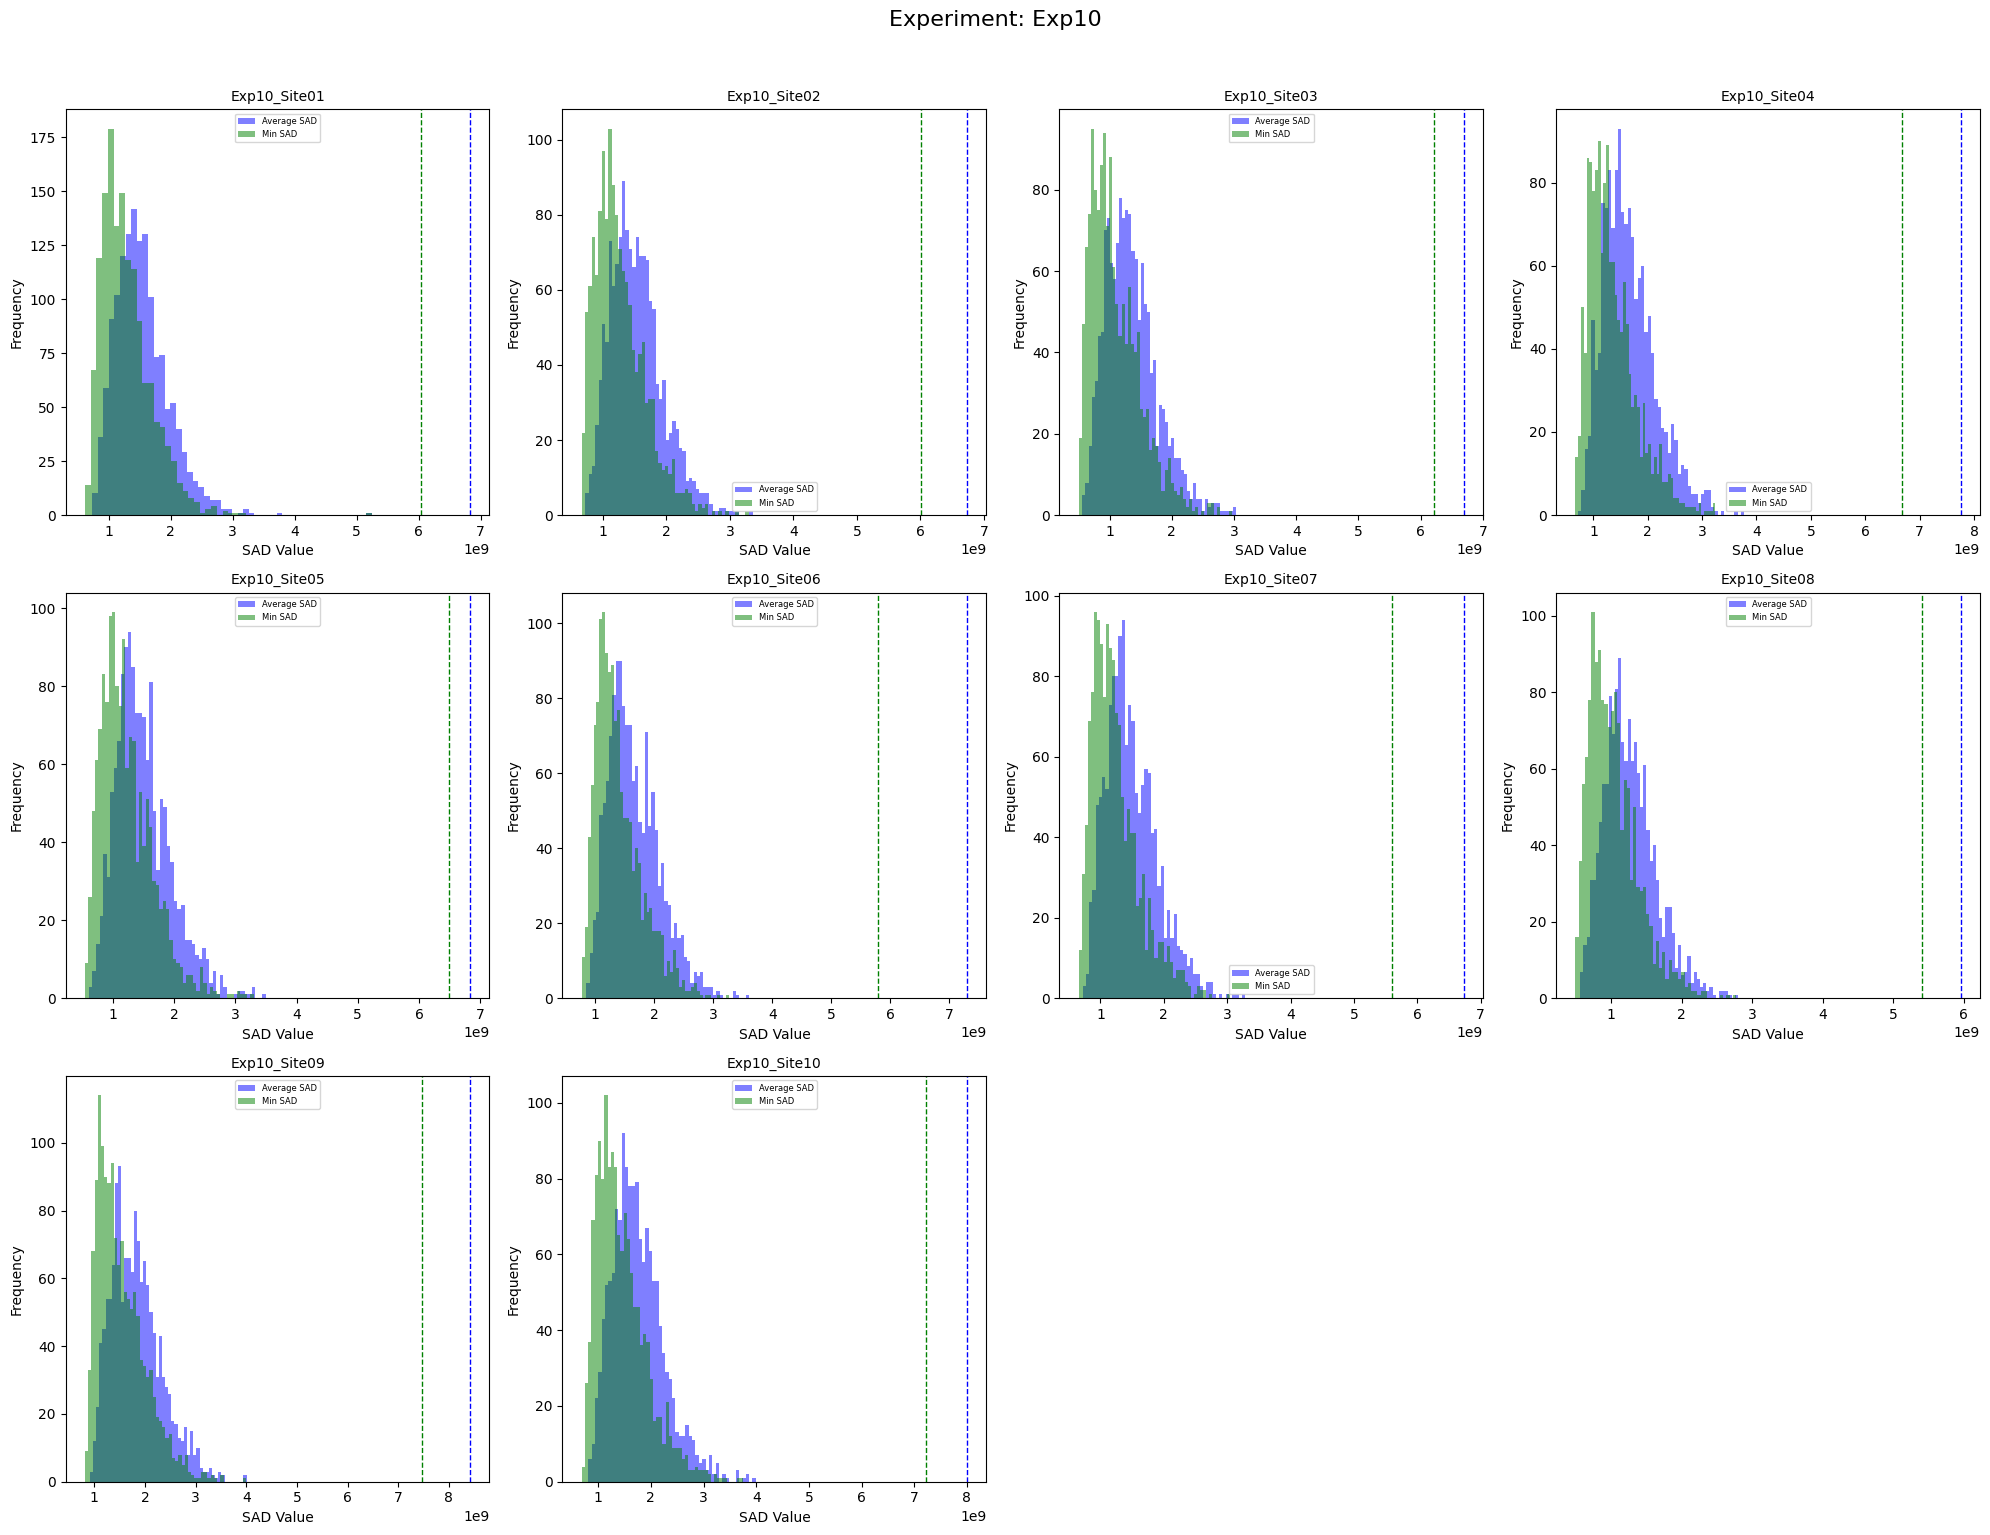

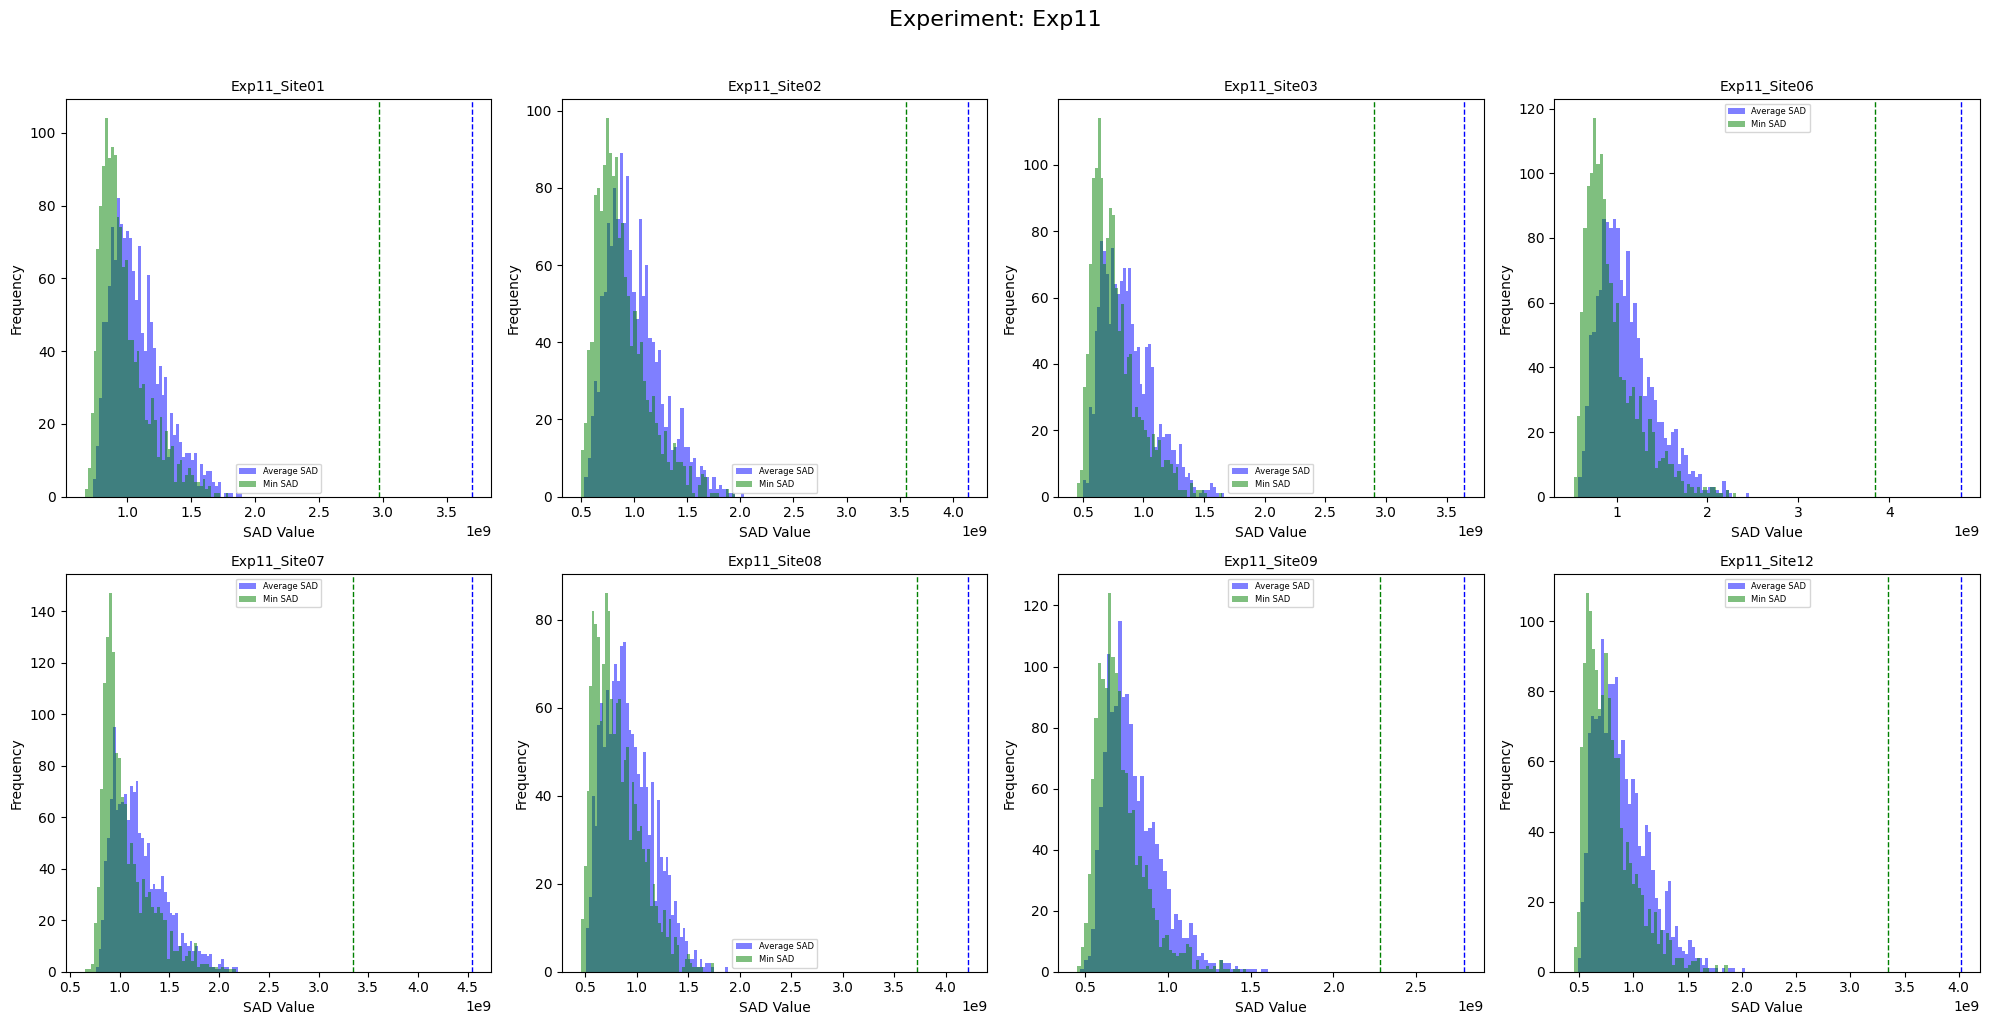

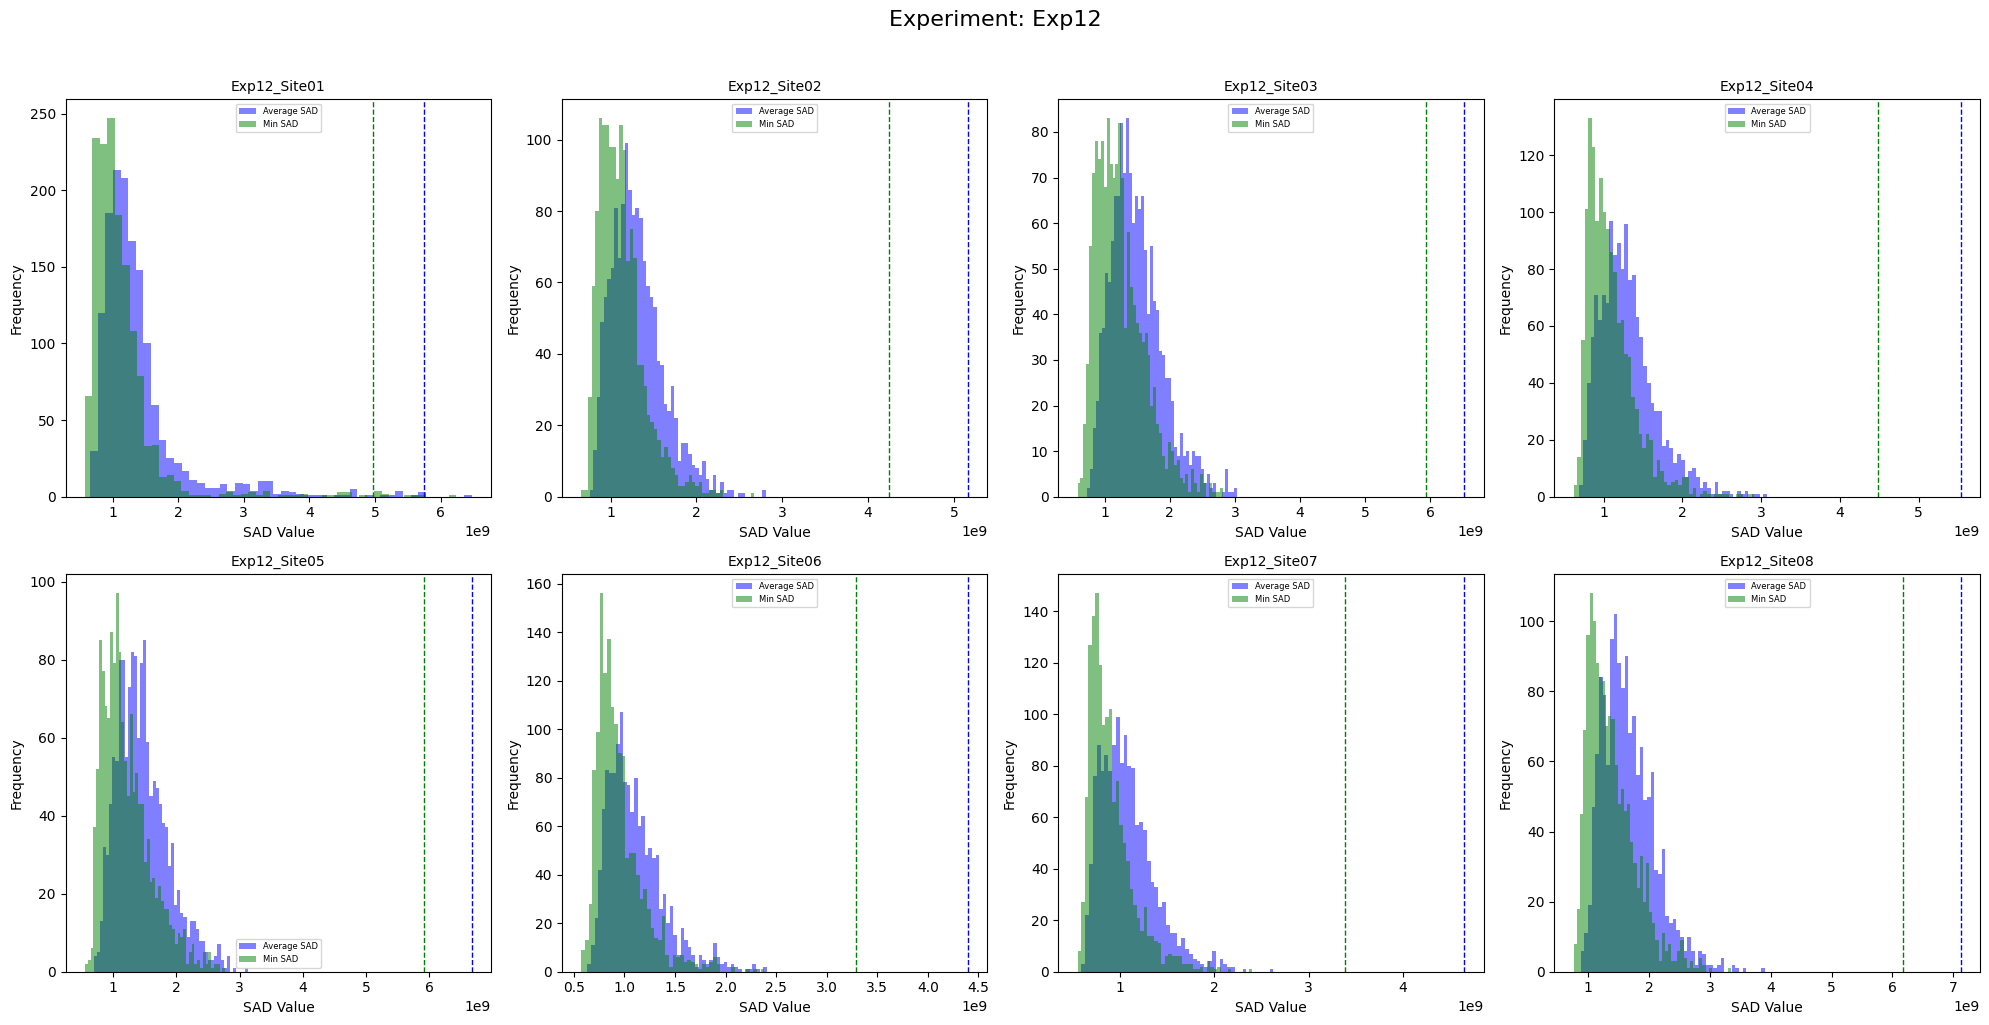

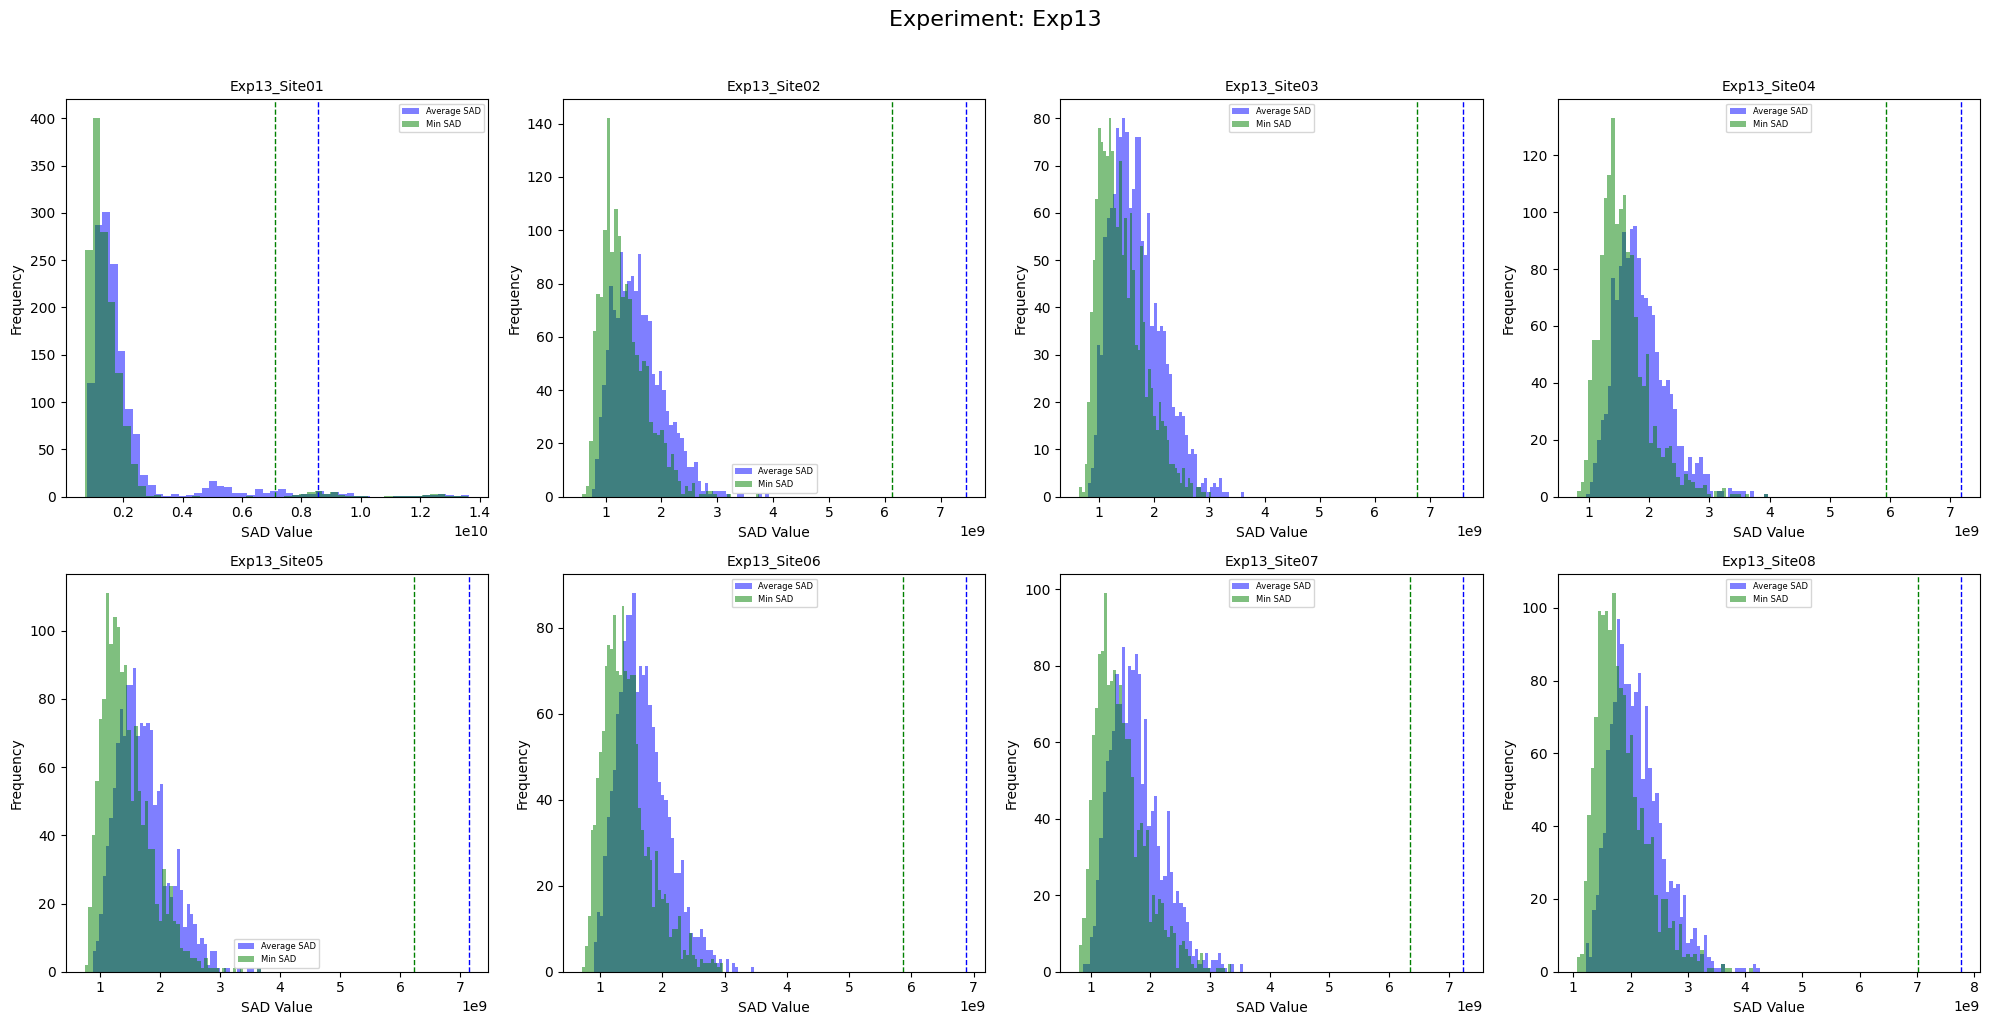

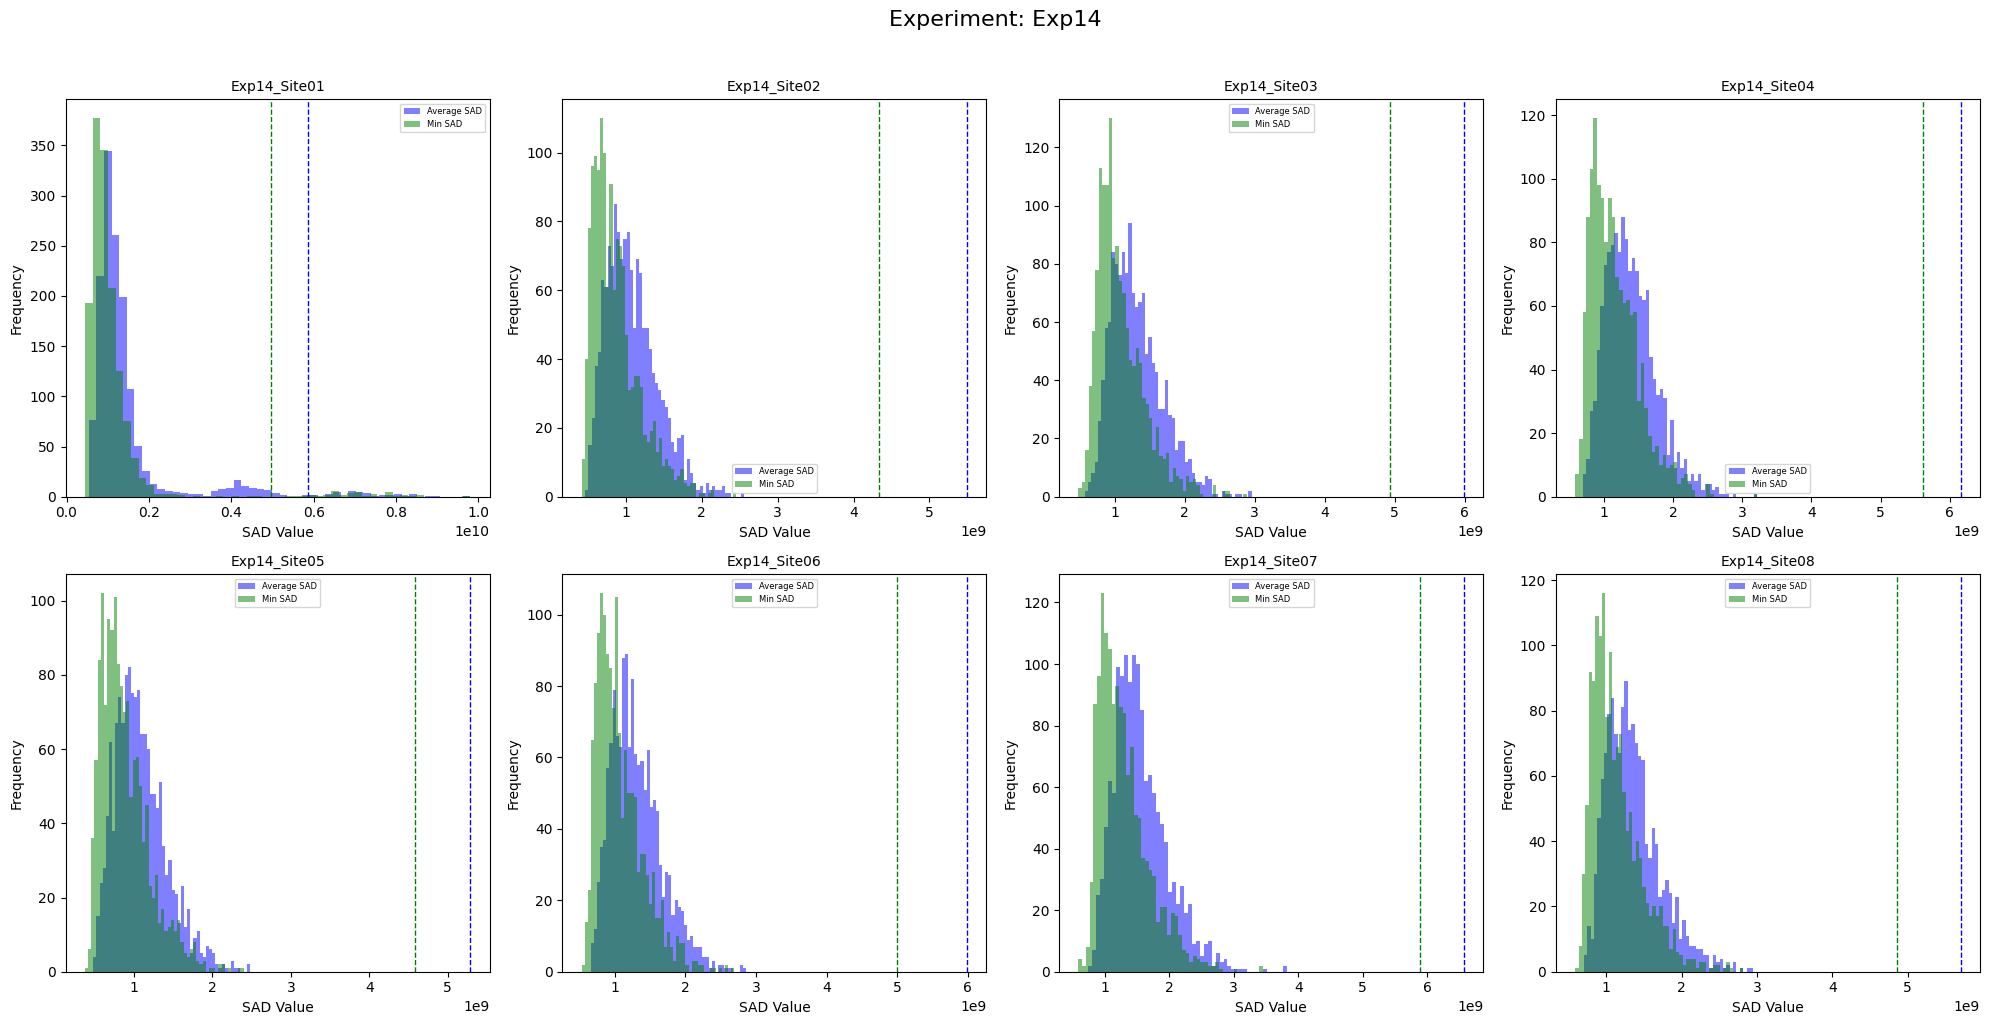

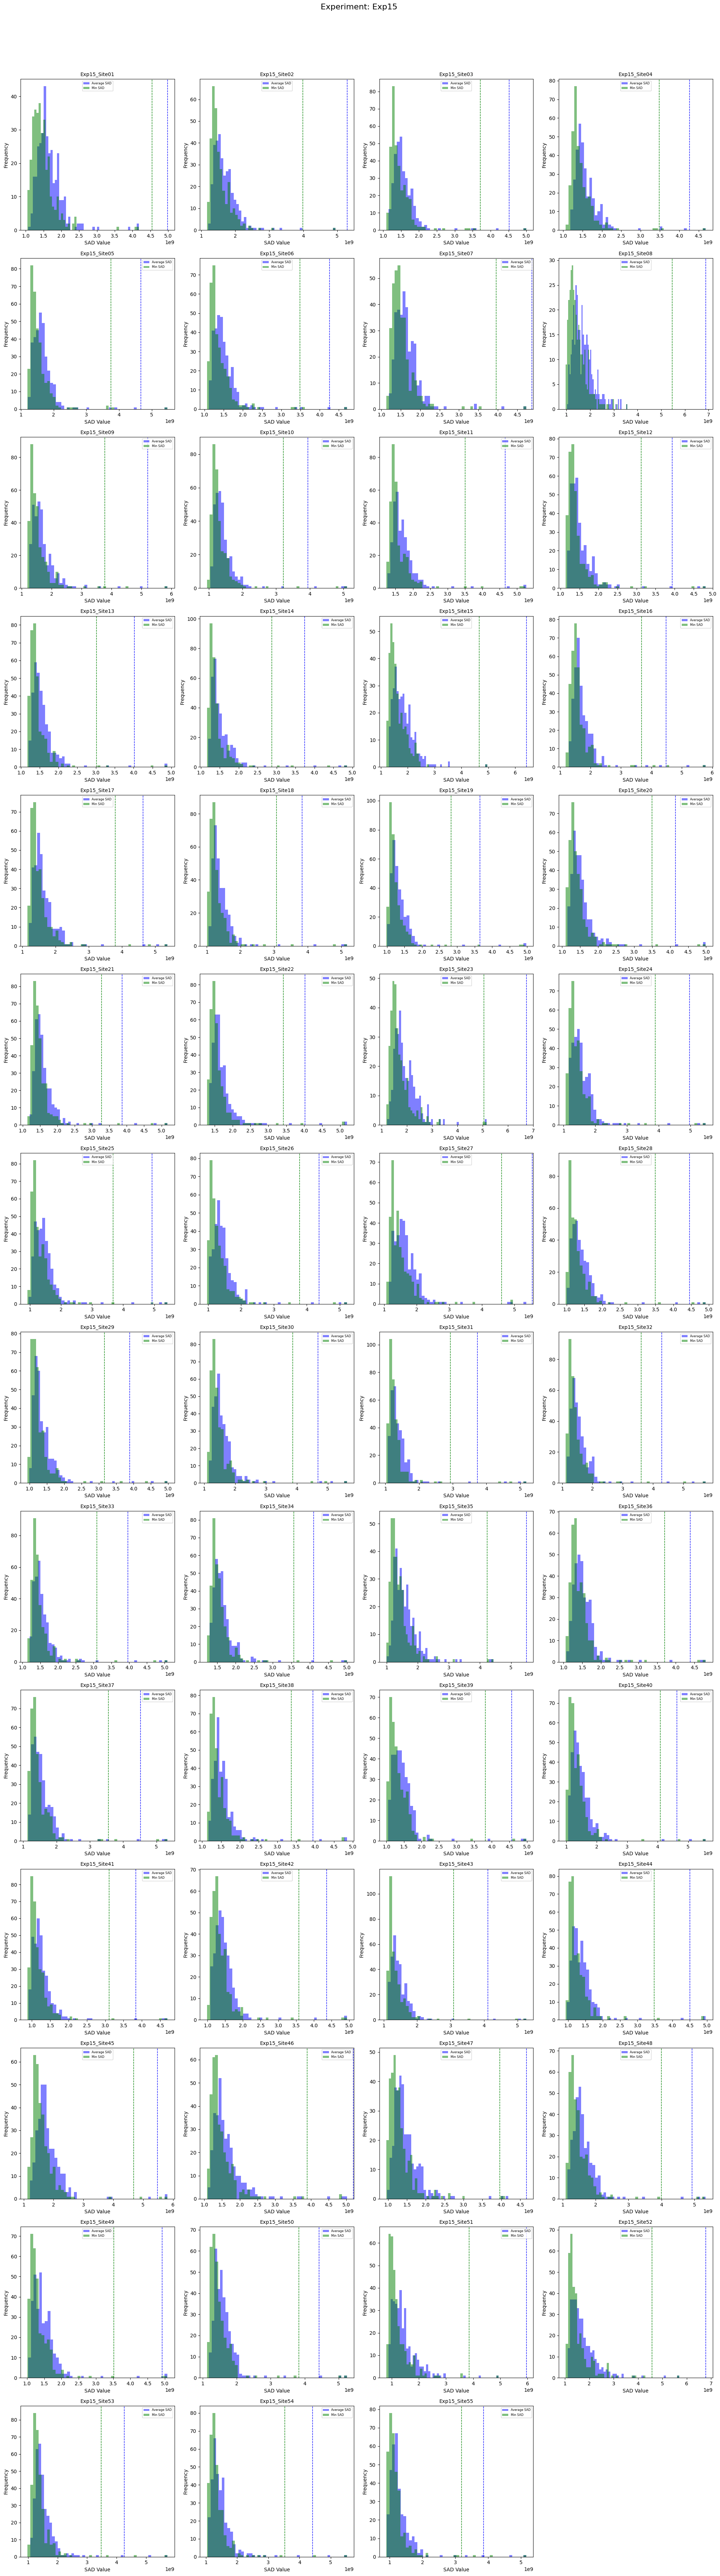

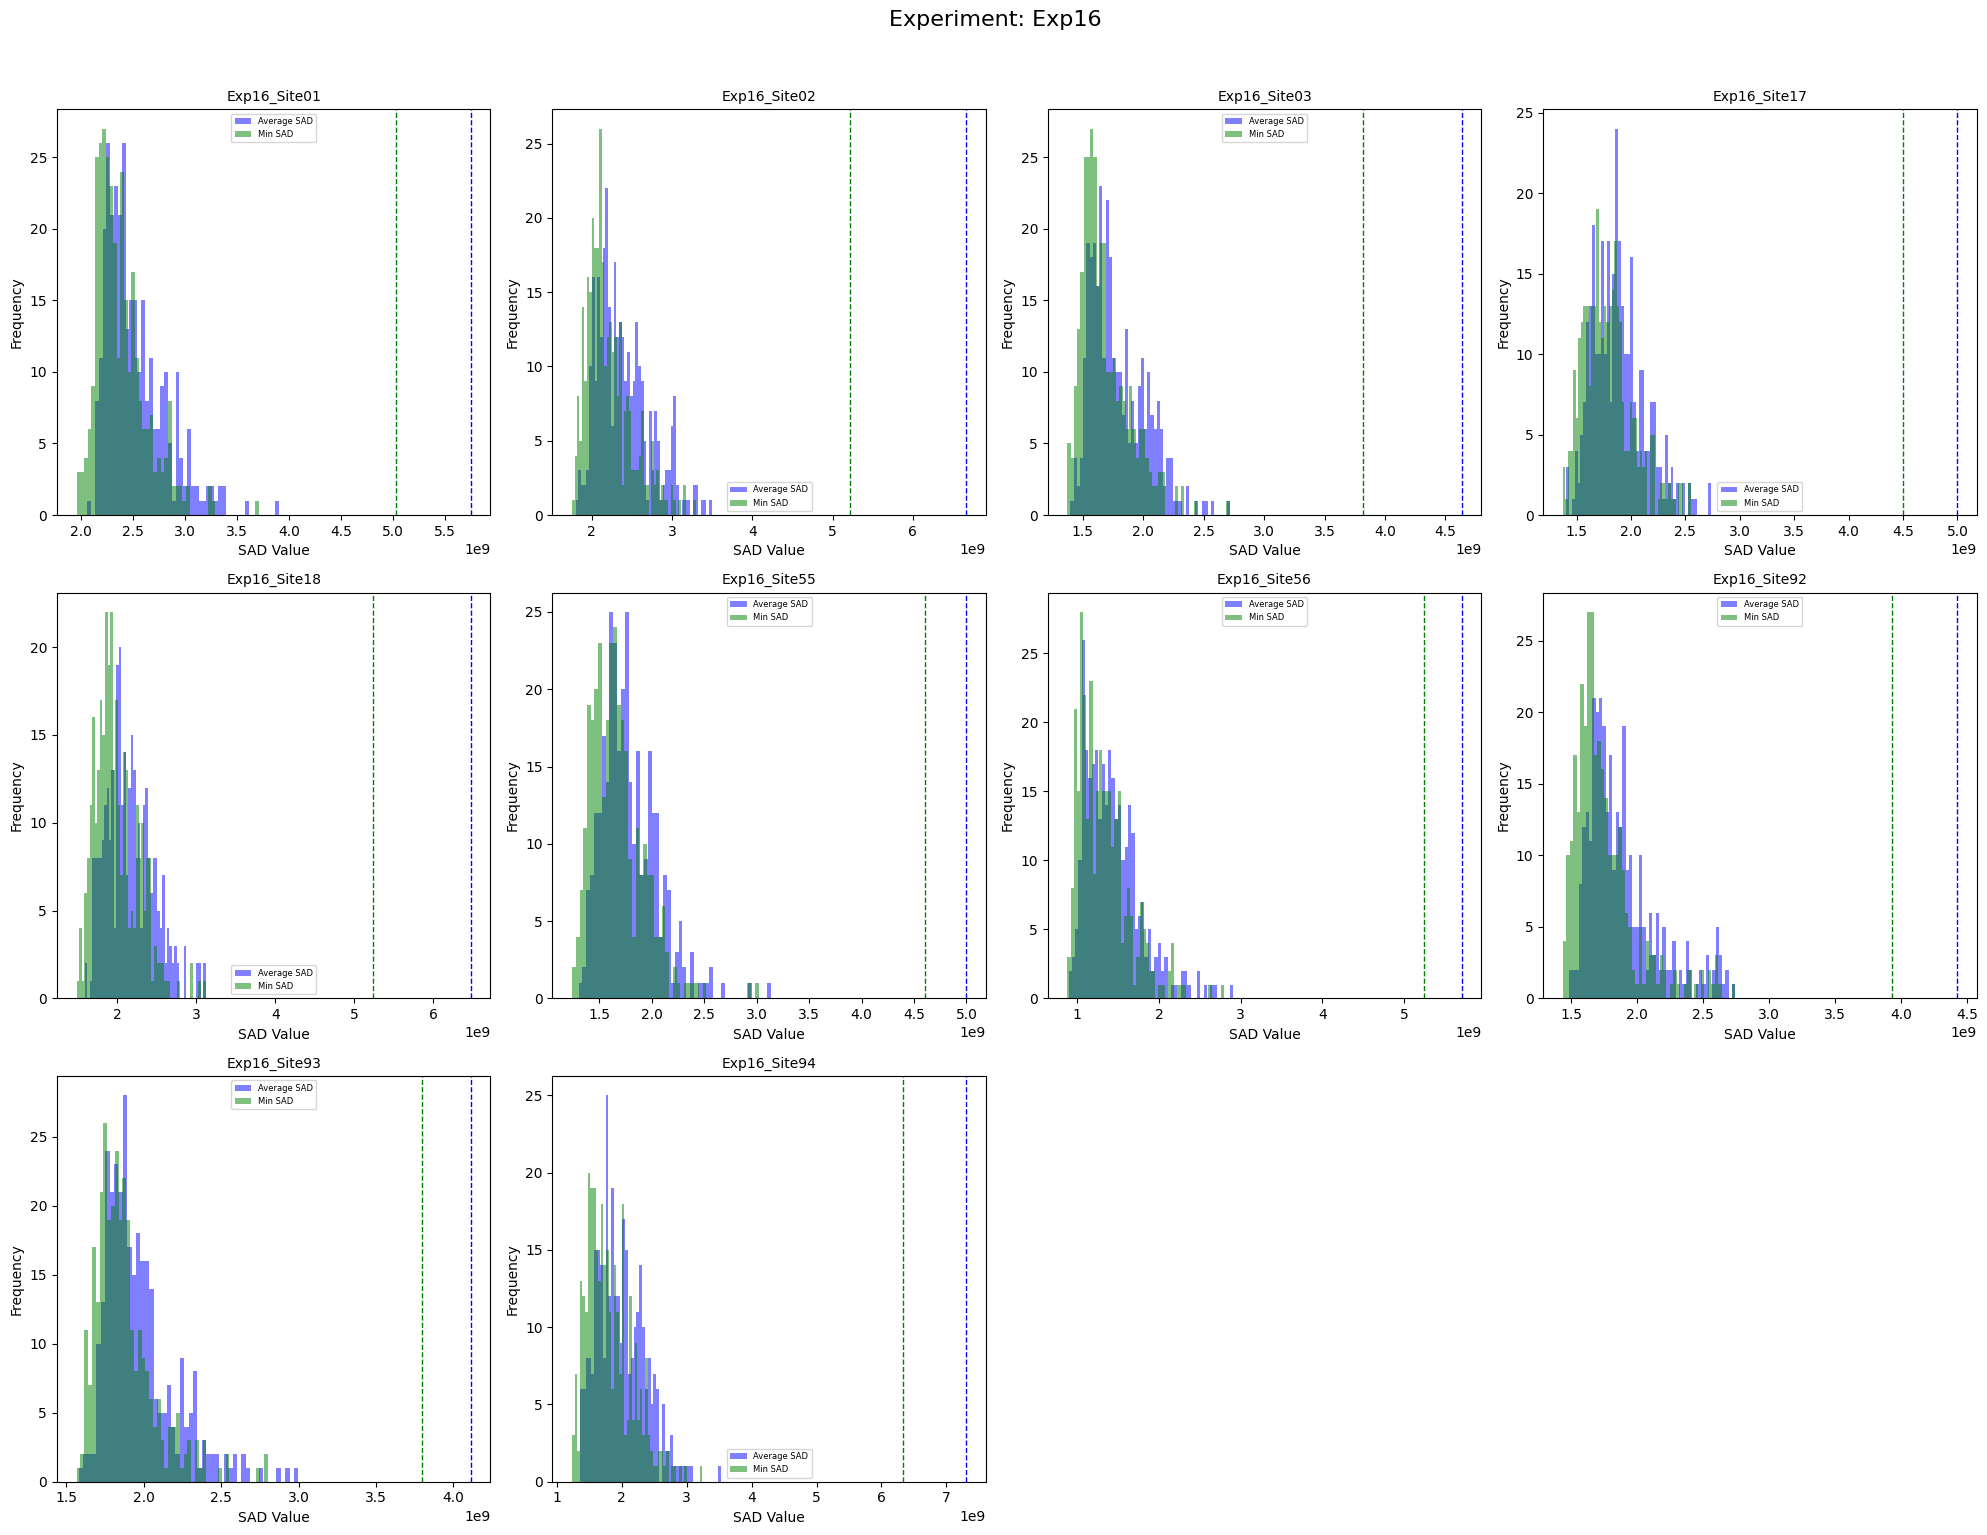

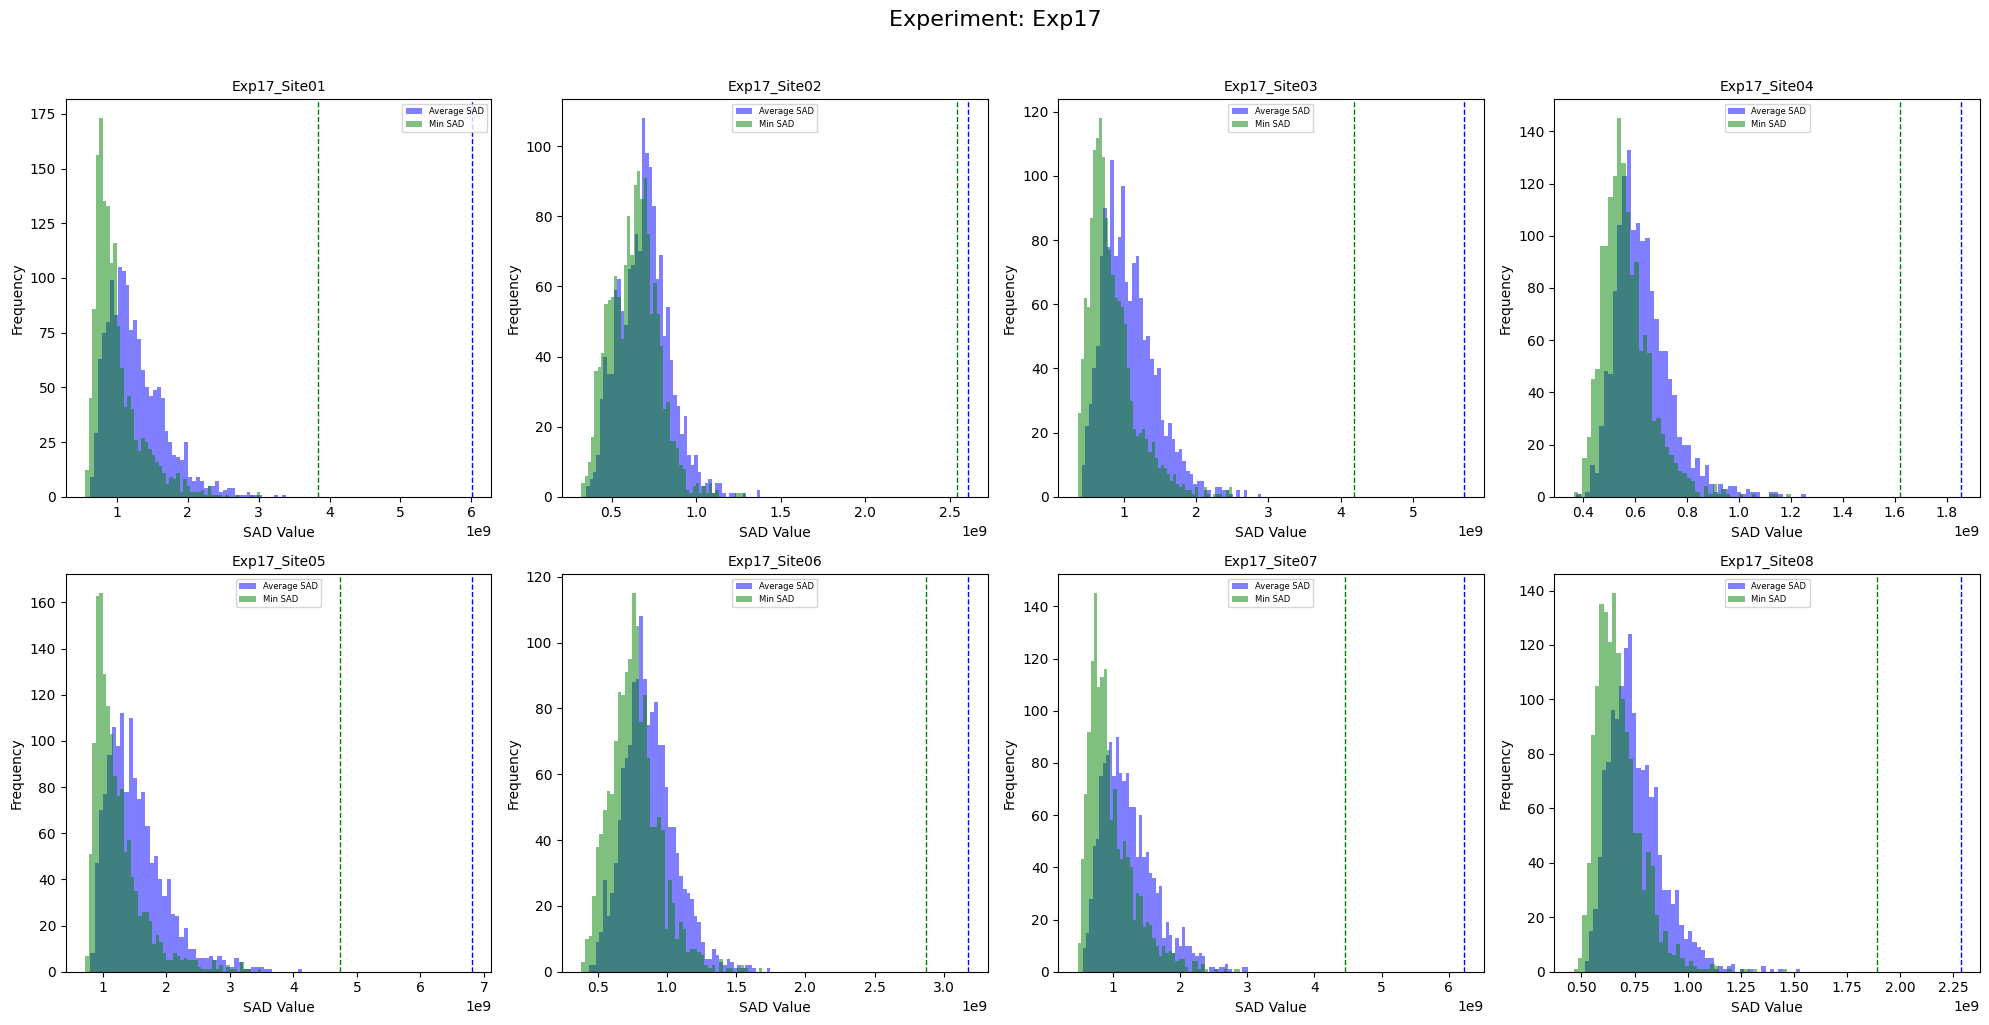

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def compute_threshold(data, multiplier=5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    return median + multiplier * mad

def create_experiment_grids(paths, all_avg_diffs, all_min_diffs):
    # Group experiments by base name
    experiment_groups = defaultdict(list)
    for idx, path in enumerate(paths):
        exp_name = Path(path).stem.split('_Site')[0]
        experiment_groups[exp_name].append(idx)
    
    # Create a grid for each experiment
    for exp_name, indices in experiment_groups.items():
        num_sites = len(indices)
        ncols = 4
        nrows = int(np.ceil(num_sites / ncols))
        
        fig, axs = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
        fig.suptitle(f'Experiment: {exp_name}', fontsize=16, y=1.02)
        
        # Properly flatten axes array
        axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
        
        for i, idx in enumerate(indices):
            ax = axs[i]  # Get single axis object
            avg = np.array(all_avg_diffs[idx])
            min_ = np.array(all_min_diffs[idx])
            
            # Calculate thresholds
            t_avg = compute_threshold(avg, 20)
            t_min = compute_threshold(min_, 20)
            
            # Create combined histogram
            ax.hist(avg, bins=50, alpha=0.5, color='blue', label='Average SAD')
            ax.hist(min_, bins=50, alpha=0.5, color='green', label='Min SAD')
            ax.axvline(t_avg, color='blue', linestyle='--', linewidth=1)
            ax.axvline(t_min, color='green', linestyle='--', linewidth=1)
            
            # Add labels and title
            site = Path(paths[idx]).stem.split('_')[-1]
            ax.set_title(f'{exp_name}_{site}', fontsize=10)
            ax.set_xlabel('SAD Value')
            ax.set_ylabel('Frequency')
            ax.legend(prop={'size': 6})
        
        # Hide empty subplots
        for j in range(len(indices), len(axs)):
            axs[j].axis('off')
        
        plt.tight_layout()
        plt.show()

# Usage
create_experiment_grids(paths, all_avg_diffs, all_min_diffs)

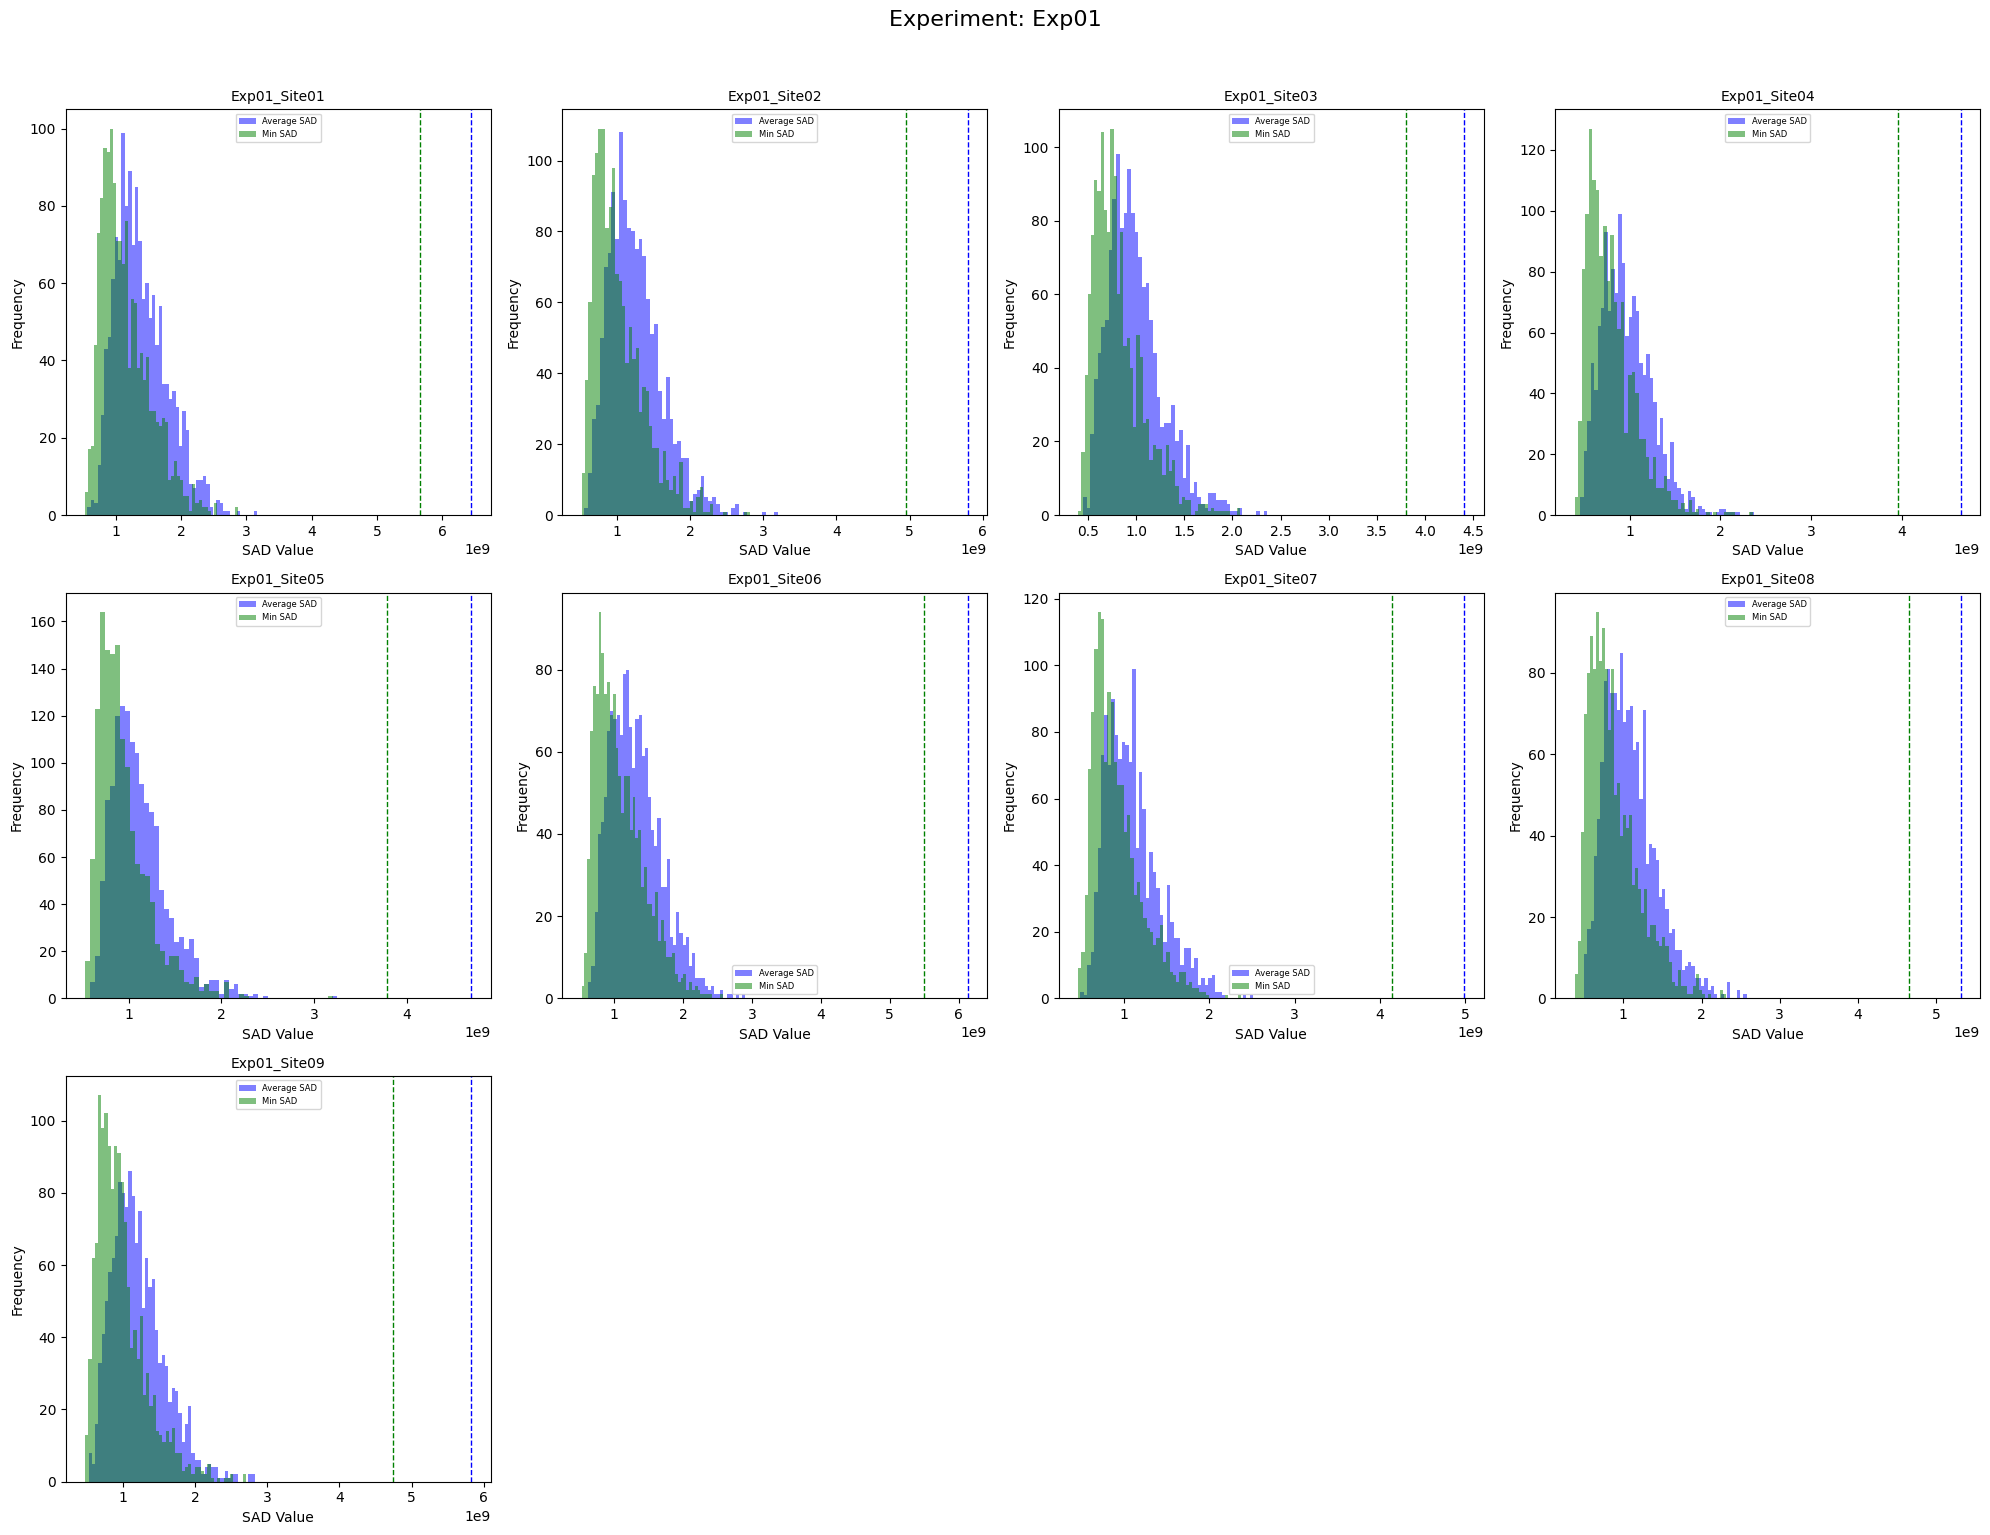

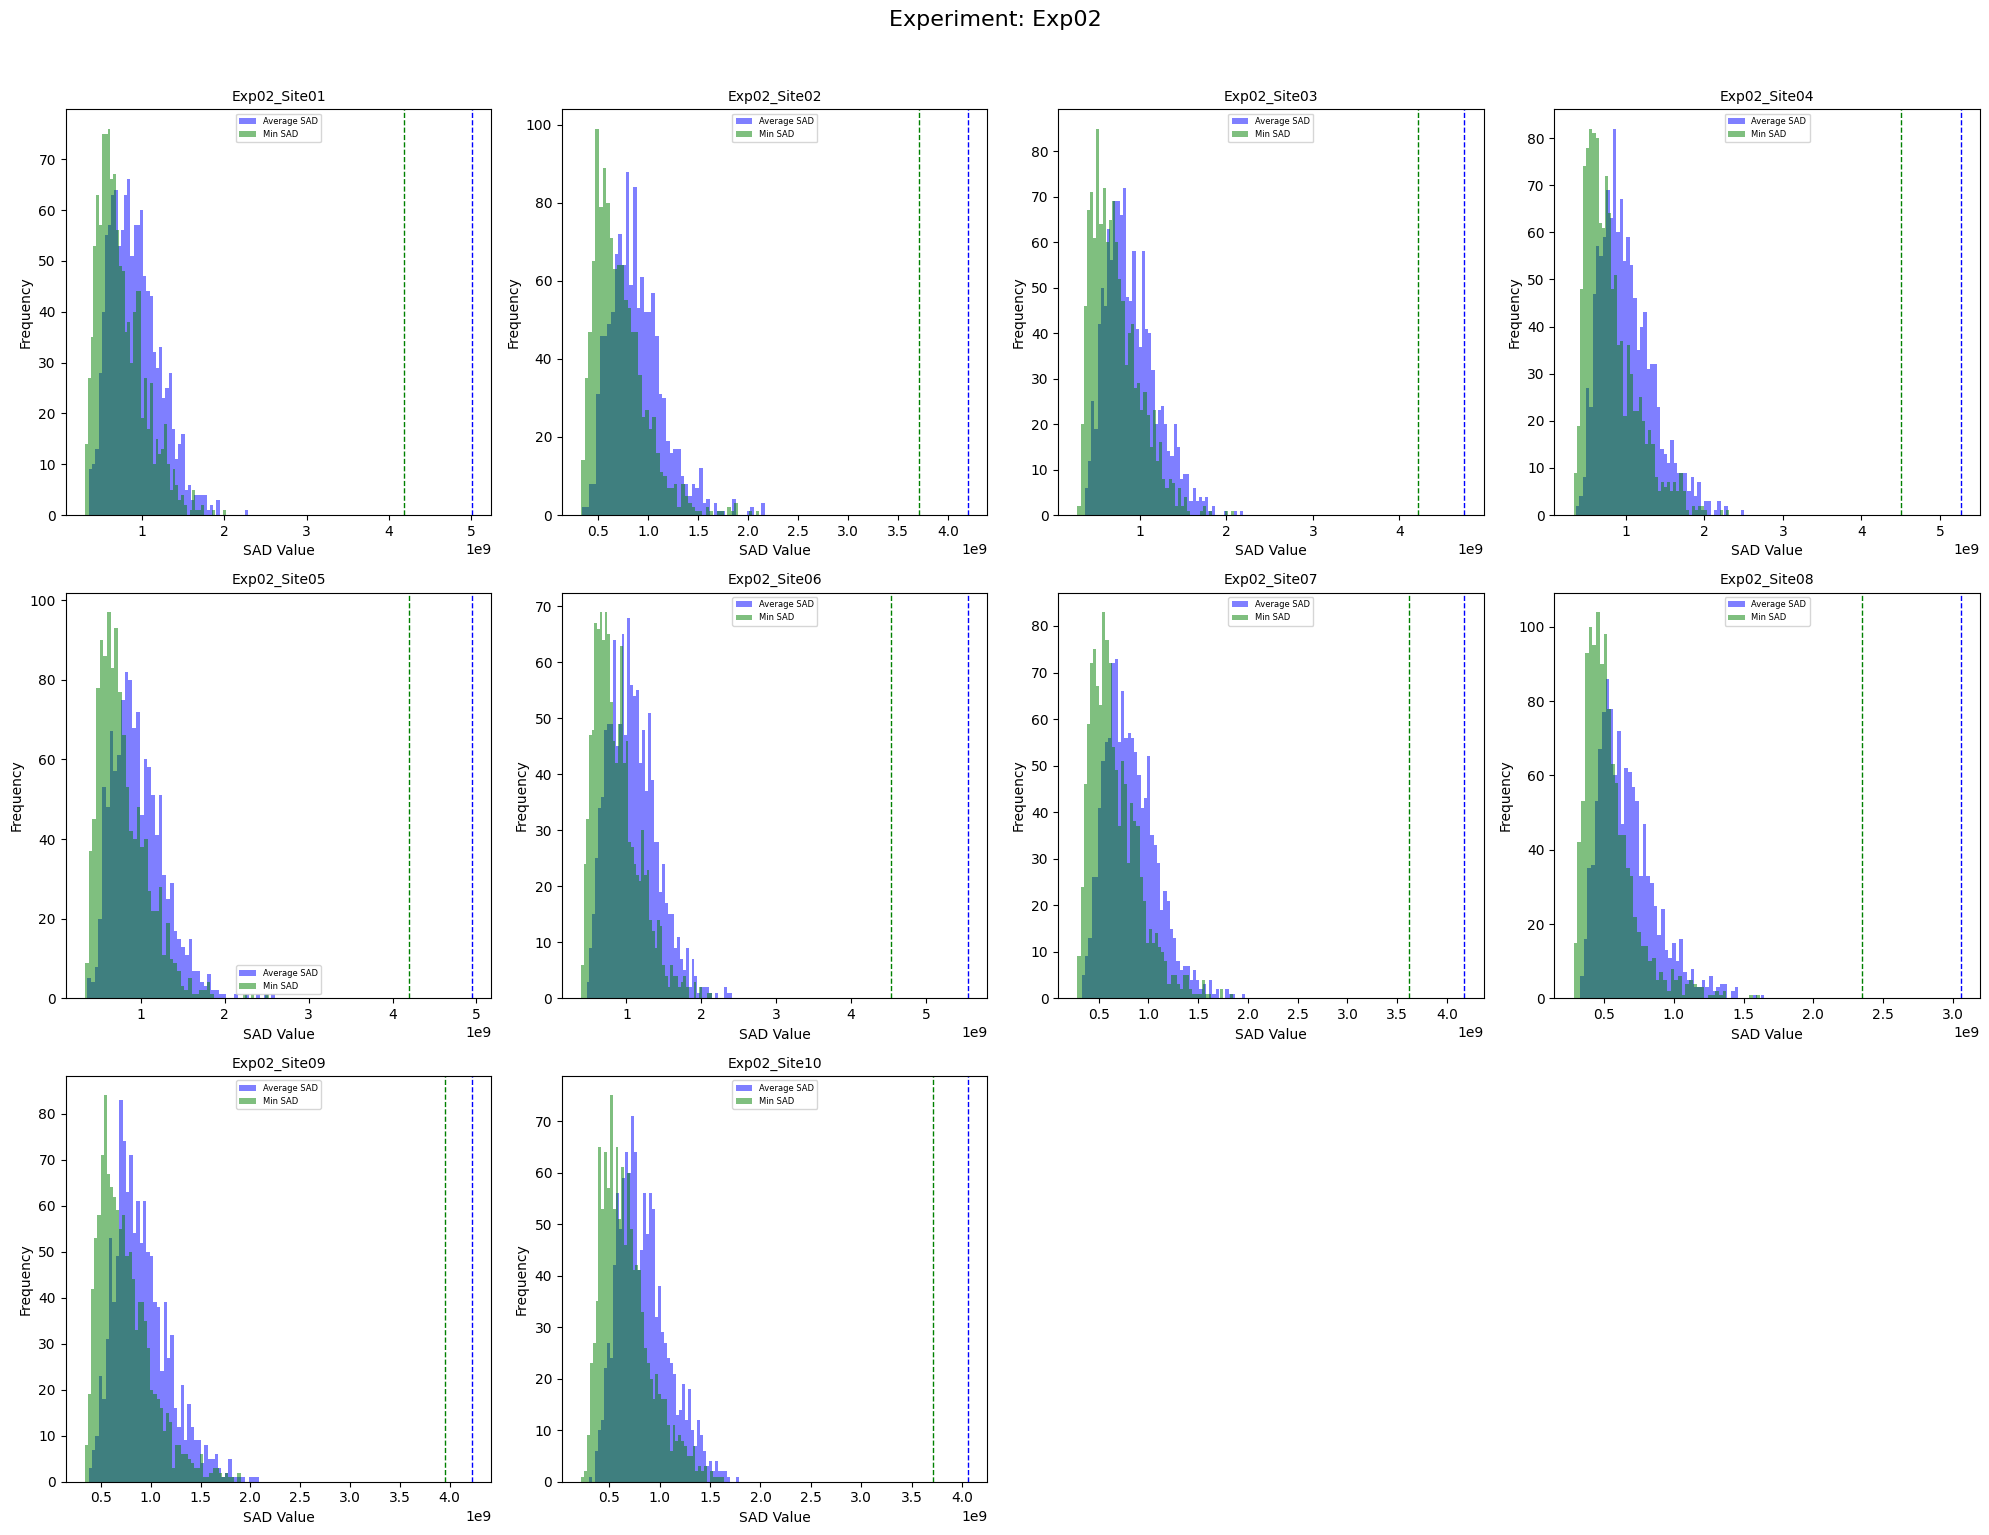

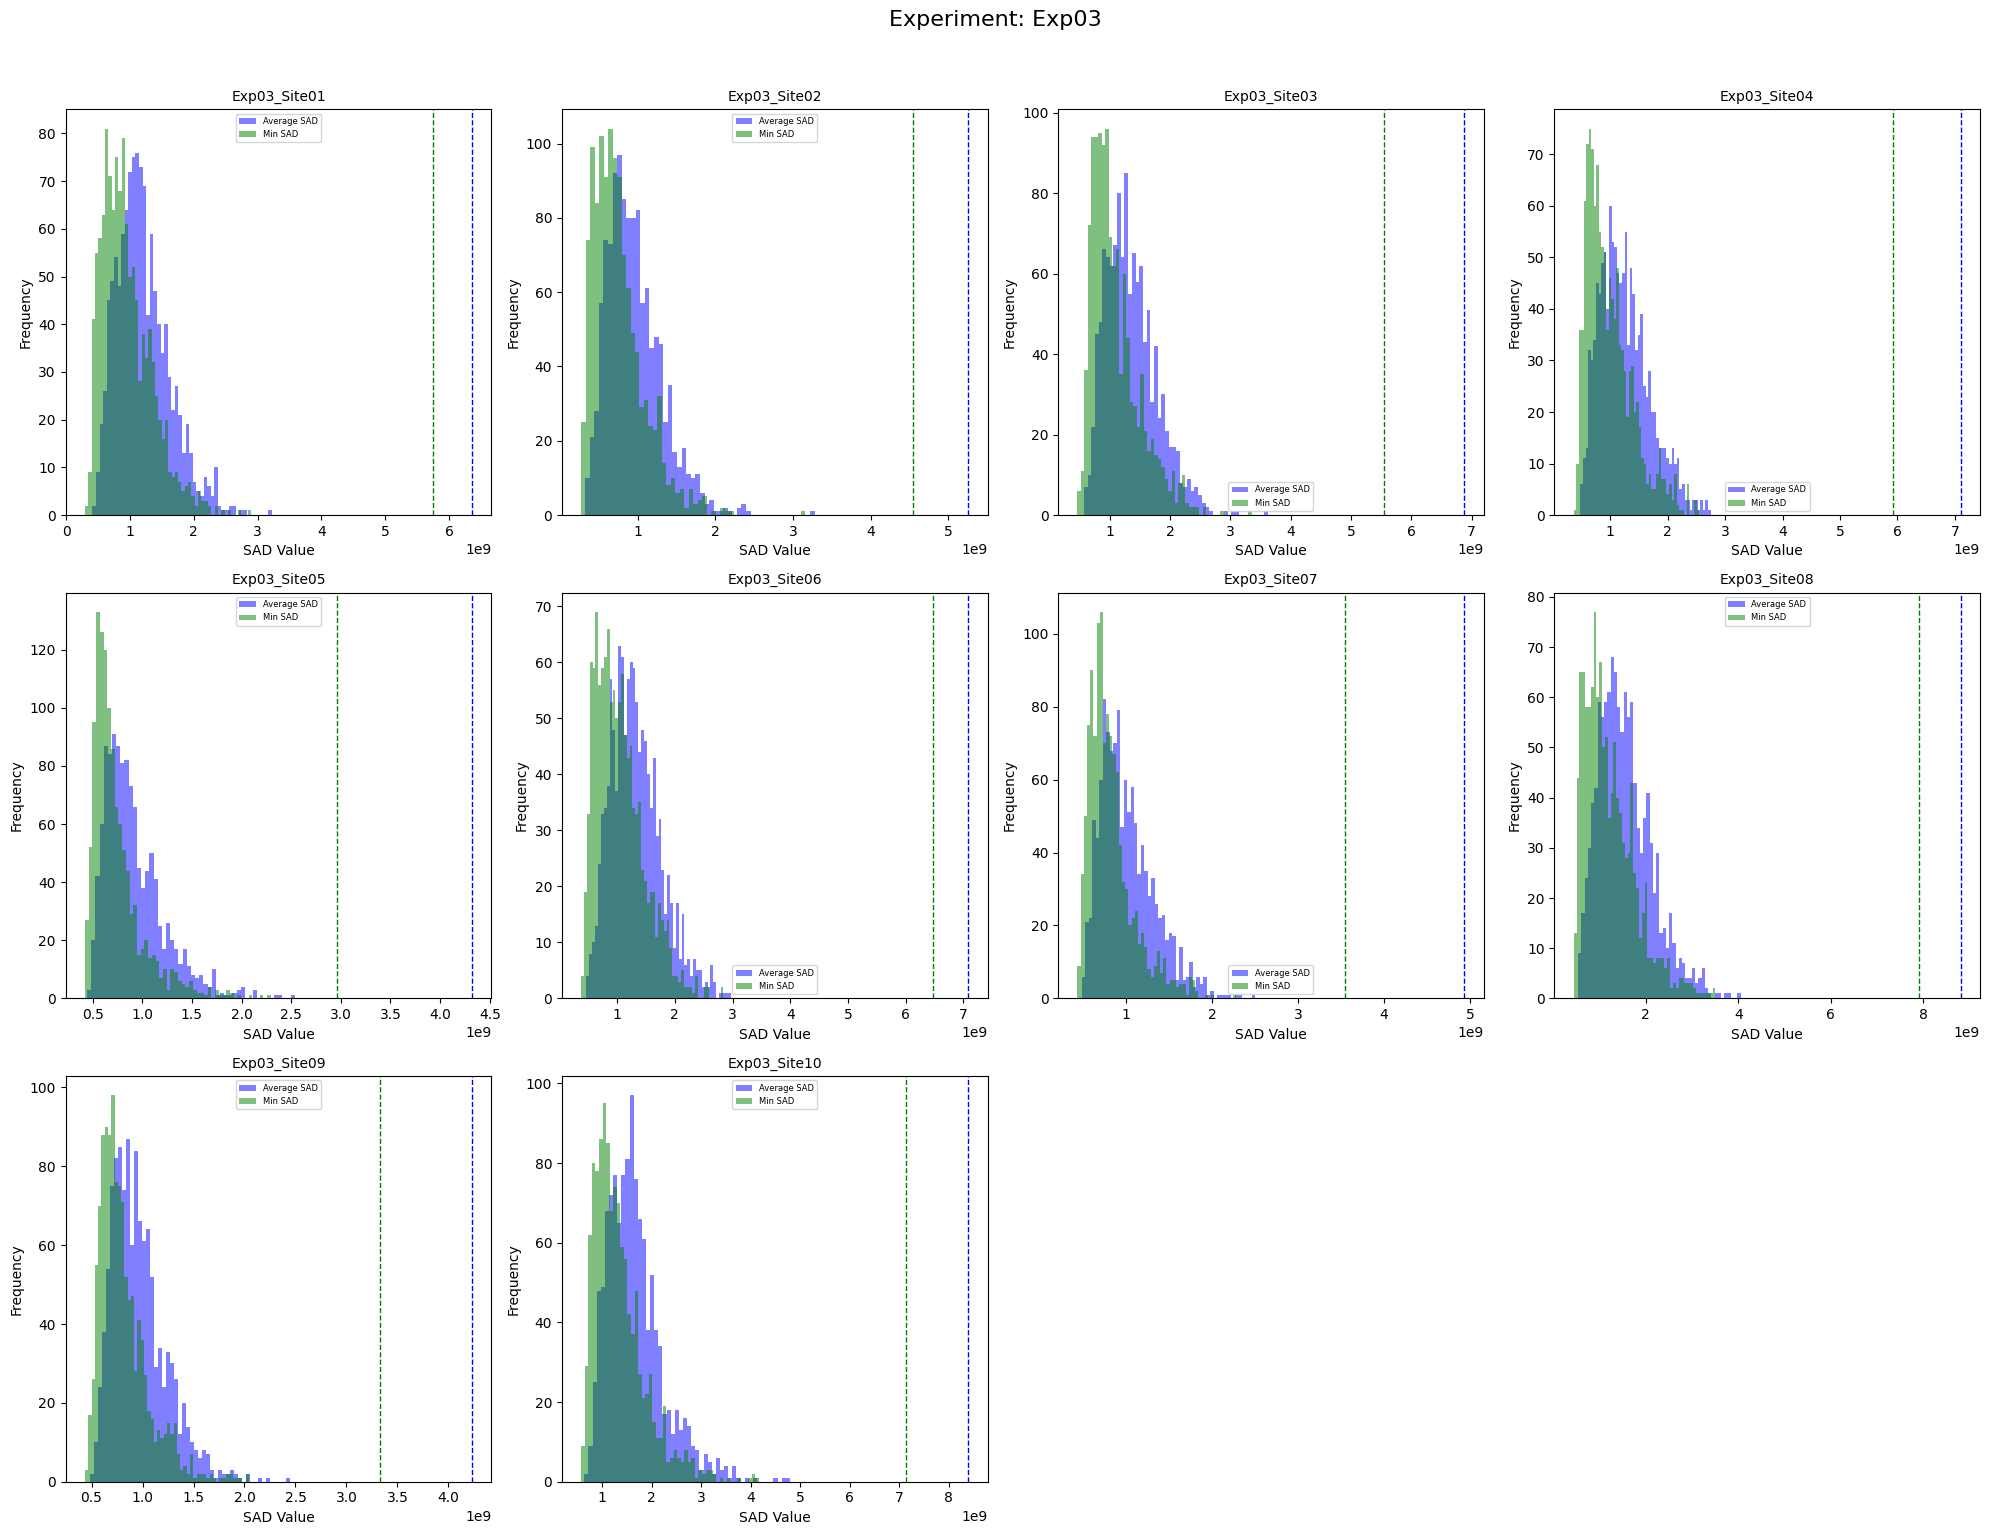

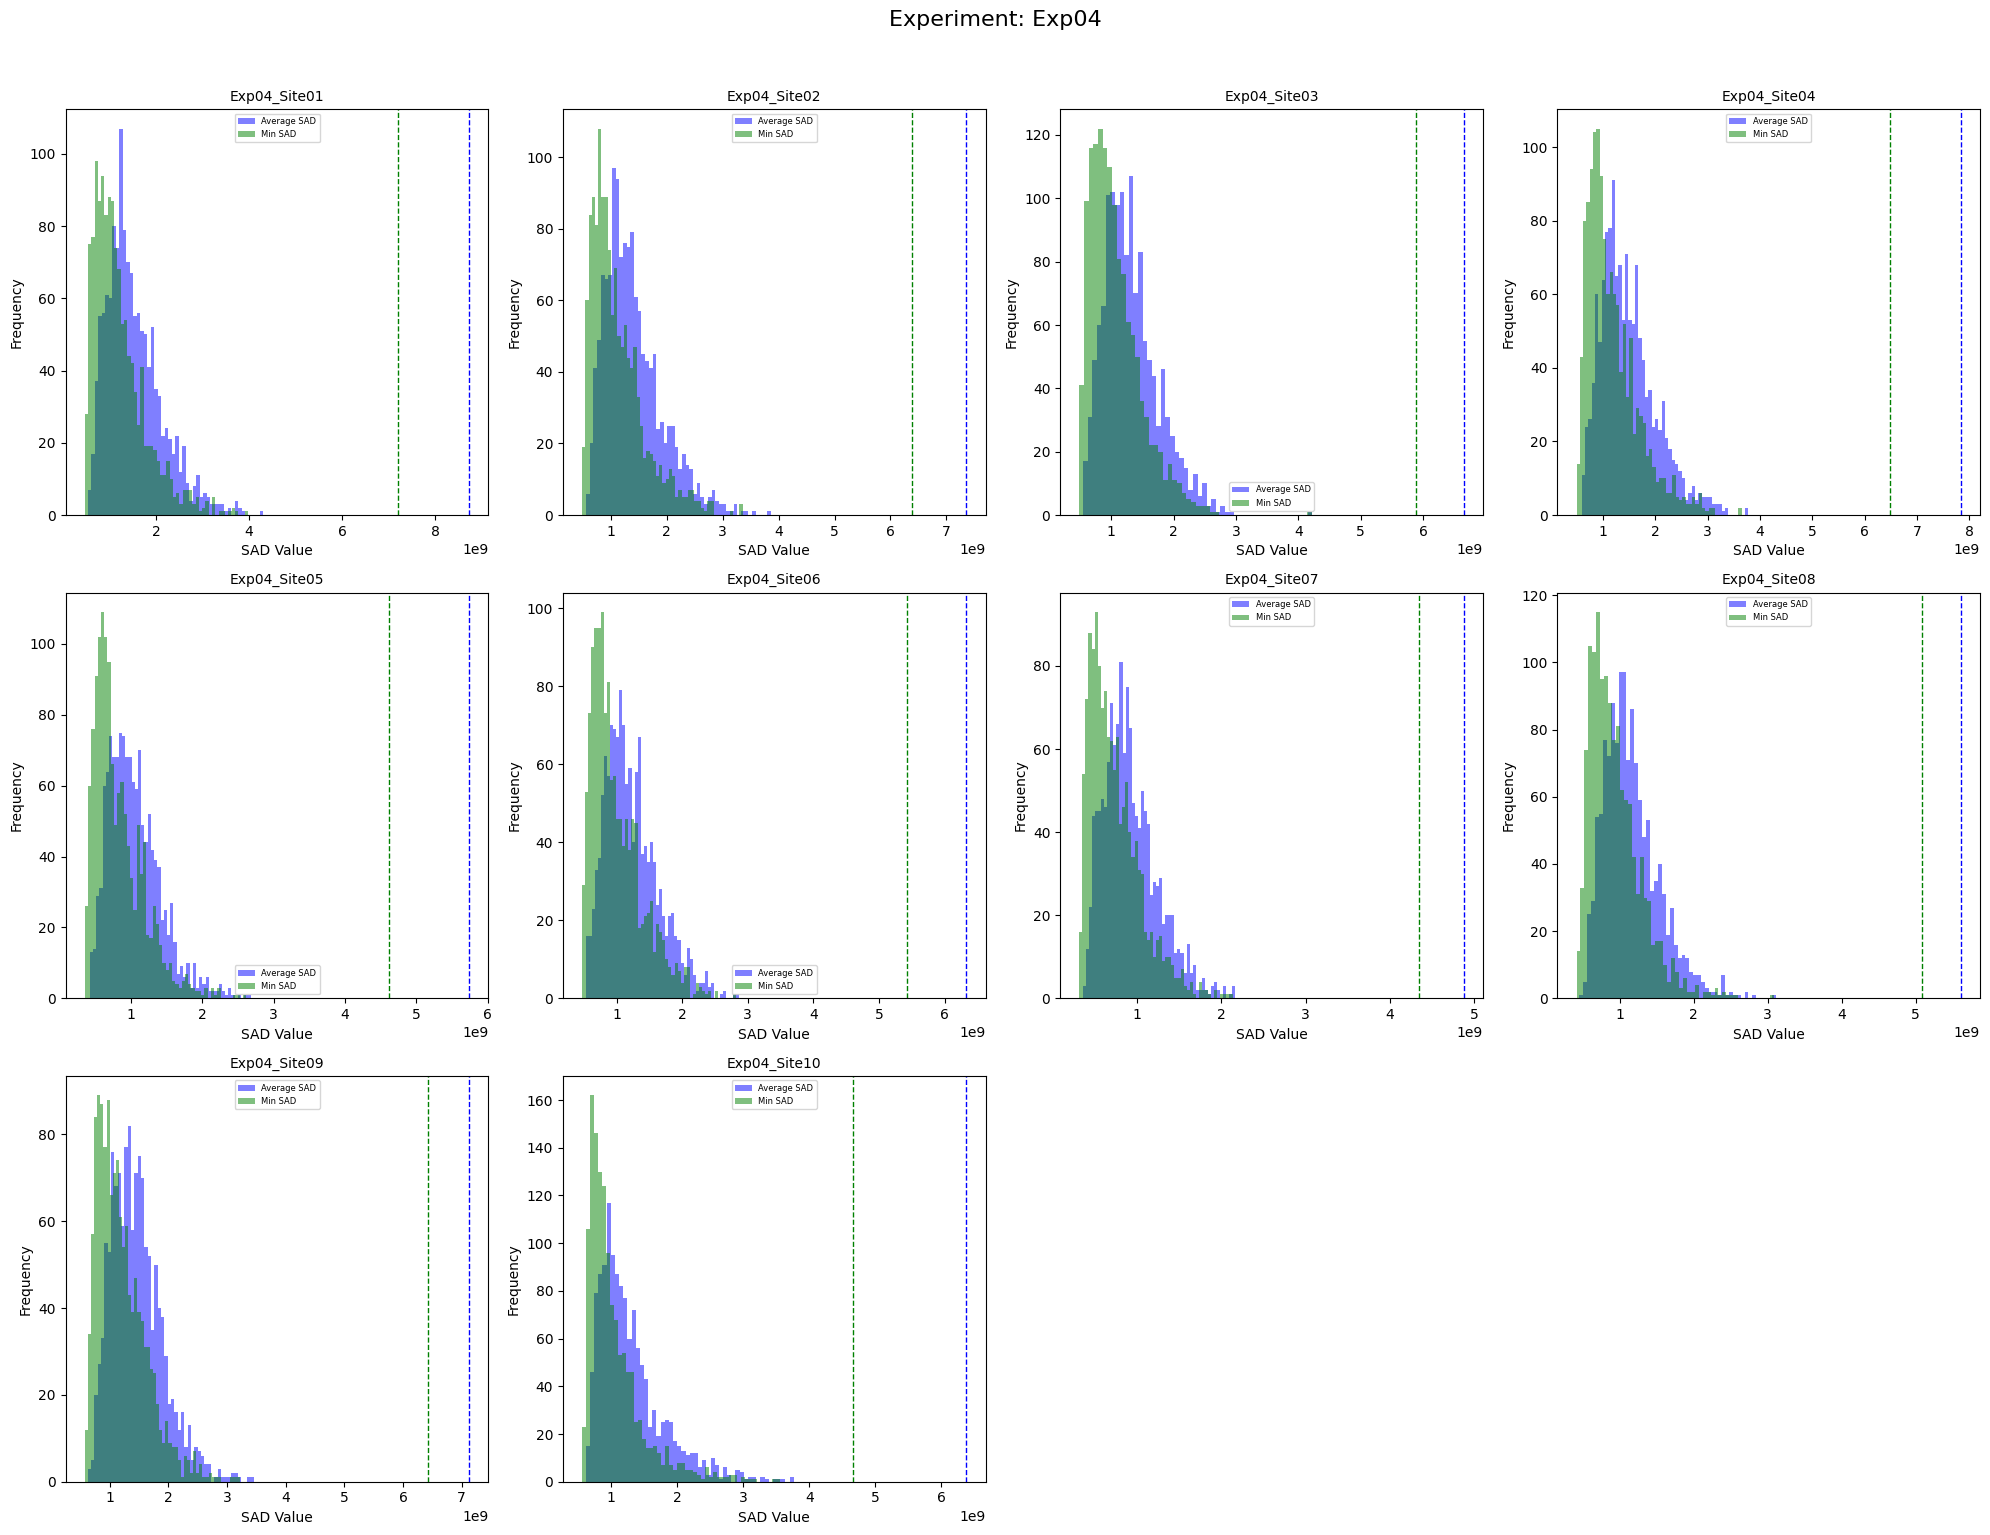

AttributeError: 'numpy.ndarray' object has no attribute 'hist'

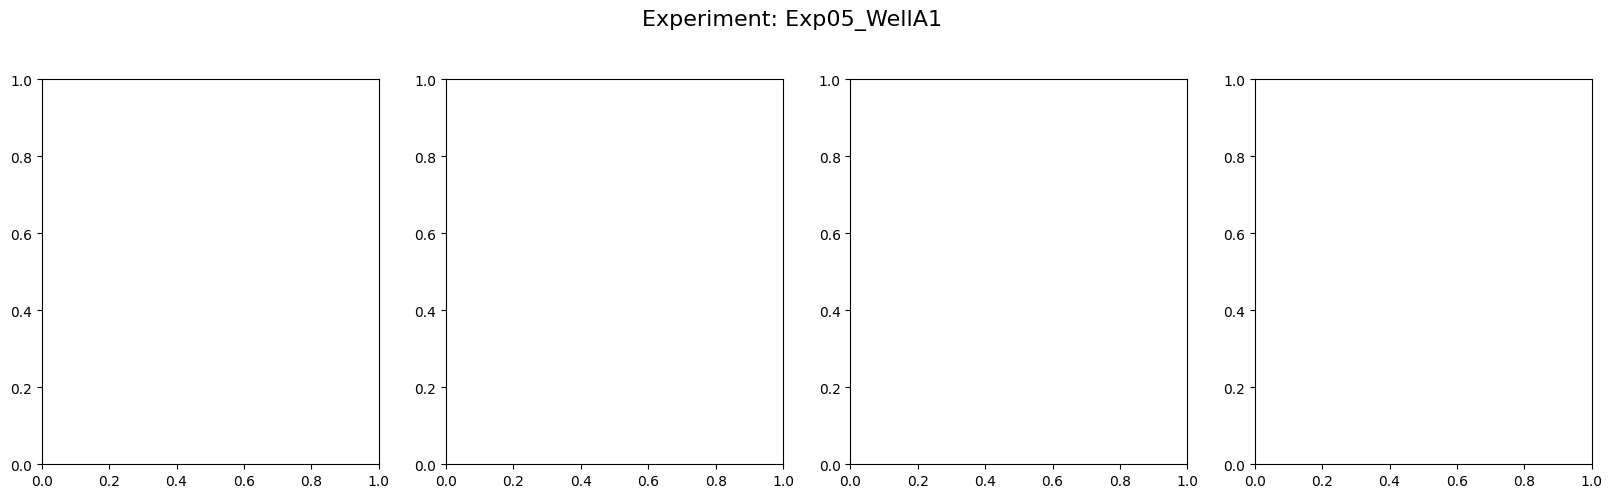

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def create_experiment_grids(paths, all_avg_diffs, all_min_diffs):
    # Group experiments by base name
    experiment_groups = defaultdict(list)
    for idx, path in enumerate(paths):
        exp_name = Path(path).stem.split('_Site')[0]
        experiment_groups[exp_name].append(idx)
    
    # Create a grid for each experiment
    for exp_name, indices in experiment_groups.items():
        num_sites = len(indices)
        ncols = 4  # Number of columns per row
        nrows = int(np.ceil(num_sites / ncols))
        
        fig, axs = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
        fig.suptitle(f'Experiment: {exp_name}', fontsize=16, y=1.02)
        
        axs = axs.flatten() if nrows > 1 else [axs]
        
        for i, idx in enumerate(indices):
            avg = all_avg_diffs[idx]
            min_ = all_min_diffs[idx]
            
            # Calculate thresholds
            t_avg = compute_threshold(np.array(avg), 20)
            t_min = compute_threshold(np.array(min_), 20)
            
            # Create combined histogram
            axs[i].hist(avg, bins=50, alpha=0.5, color='blue', label='Average SAD')
            axs[i].hist(min_, bins=50, alpha=0.5, color='green', label='Min SAD')
            axs[i].axvline(t_avg, color='blue', linestyle='--', linewidth=1)
            axs[i].axvline(t_min, color='green', linestyle='--', linewidth=1)
            
            # Add labels and title
            site = Path(paths[idx]).stem.split('_')[-1]
            axs[i].set_title(f'{exp_name}_{site}', fontsize=10)
            axs[i].set_xlabel('SAD Value')
            axs[i].set_ylabel('Frequency')
            axs[i].legend(prop={'size': 6})
        
        # Hide empty subplots
        for j in range(len(indices), len(axs)):
            axs[j].axis('off')
        
        plt.tight_layout()
        plt.show()


create_experiment_grids(paths, all_avg_diffs, all_min_diffs)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown
from pathlib import Path
from collections import defaultdict

def create_interactive_grid(all_avg_diffs, all_min_diffs, paths):
    # Create experiment grouping
    experiments = defaultdict(dict)
    for idx, path in enumerate(paths):
        path = Path(path)
        exp, site = path.stem.split('_Site')
        site = f"Site{site.split('.')[0]}"  # Handle file extensions
        experiments[exp][site] = idx
    
    # Create widgets
    exp_choices = list(experiments.keys())
    site_choices = {exp: list(sites.keys()) for exp, sites in experiments.items()}
    
    # Create interactive plot
    @interact
    def plot_interactive(
        Experiment=Dropdown(options=exp_choices, value=exp_choices[0], description='Experiment:'),
        Site=Dropdown(options=site_choices[exp_choices[0]], description='Site:')
    ):
        idx = experiments[Experiment][Site]
        avg = all_avg_diffs[idx]
        min_ = all_min_diffs[idx]
        
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        
        # Calculate thresholds
        t_avg = compute_threshold(np.array(avg), 20)
        t_min = compute_threshold(np.array(min_), 20)
        
        # Plot average SAD
        ax[0].hist(avg, bins=50, alpha=0.5, color='blue', label='Average SAD')
        ax[0].axvline(t_avg, color='blue', linestyle='--', linewidth=2)
        ax[0].set_title(f'Average SAD - {Experiment}_{Site}')
        ax[0].set_xlabel('SAD Value')
        ax[0].set_ylabel('Frequency')
        ax[0].legend()
        
        # Plot minimum SAD
        ax[1].hist(min_, bins=50, alpha=0.5, color='green', label='Min SAD')
        ax[1].axvline(t_min, color='green', linestyle='--', linewidth=2)
        ax[1].set_title(f'Minimum SAD - {Experiment}_{Site}')
        ax[1].set_xlabel('SAD Value')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()

    # Link site options to selected experiment
    def update_sites(*args):
        plot_interactive.widgets.Site.options = site_choices[plot_interactive.widgets.Experiment.value]
    
    plot_interactive.widgets.Experiment.observe(update_sites, 'value')

# Usage
create_interactive_grid(all_avg_diffs, all_min_diffs, paths)

interactive(children=(Dropdown(description='Experiment:', options=('Exp01', 'Exp02', 'Exp03', 'Exp04', 'Exp05_…

AttributeError: 'function' object has no attribute 'widgets'

In [32]:
# Create a long DataFrame for avg_diffs
df_avg = df[['filenames', 'avg_diffs', 'exp_nums']].copy()
df_avg = df_avg.explode('avg_diffs')
df_avg.rename(columns={'avg_diffs': 'SAD'}, inplace=True)
df_avg

,filenames,SAD,exp_nums
0,Exp01_Site01.npz,2876506694,1
0,Exp01_Site01.npz,2655550987.0,1
0,Exp01_Site01.npz,2250408166.0,1
0,Exp01_Site01.npz,1697382473.0,1
0,Exp01_Site01.npz,1303151492.5,1
...,...,...,...
218,Exp17_Site08.npz,847511406.5,17
218,Exp17_Site08.npz,611057831.0,17
218,Exp17_Site08.npz,771260123.0,17
218,Exp17_Site08.npz,821559400.0,17


In [33]:
# Create a long DataFrame for min_diffs
df_min = df[['filenames', 'min_diffs', 'exp_nums']].copy()
df_min = df_min.explode('min_diffs')
df_min.rename(columns={'min_diffs': 'SAD'}, inplace=True)
df_min

,filenames,SAD,exp_nums
0,Exp01_Site01.npz,2876506694,1
0,Exp01_Site01.npz,2396454492,1
0,Exp01_Site01.npz,2131886120,1
0,Exp01_Site01.npz,1260257466,1
0,Exp01_Site01.npz,1272446790,1
...,...,...,...
218,Exp17_Site08.npz,566296278,17
218,Exp17_Site08.npz,546767146,17
218,Exp17_Site08.npz,677707740,17
218,Exp17_Site08.npz,814349994,17


In [36]:
print(df_avg['SAD'].dtype)
df_avg['SAD'] = pd.to_numeric(df_avg['SAD'], errors='raise')
df_min['SAD'] = pd.to_numeric(df_min['SAD'], errors='raise')
print(df_avg['SAD'].dtype)


object
float64


<Figure size 5000x2000 with 0 Axes>

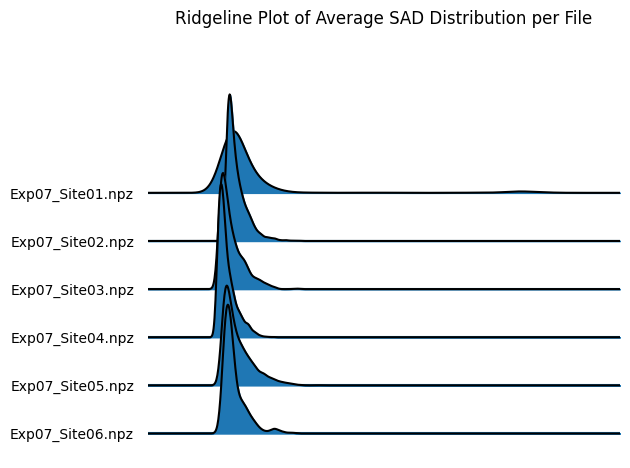

In [61]:
import matplotlib.pyplot as plt
import joypy

current_df = df_min[df_min['exp_nums']==7]

plt.figure(figsize=(50, 20))
joypy.joyplot(
    current_df[:10000],
    by='filenames',
    column='SAD',
    kind="kde",
    title="Ridgeline Plot of Average SAD Distribution per File",
    xlabels="Average SAD",
    overlap=2  # Adjust the overlap as needed
)
plt.show()

In [ ]:
def create_summary_plot(all_avg_diffs, all_min_diffs, experiment_names):
    """Create combined boxplots for all experiments"""
    plt.figure(figsize=(15, 6))
    
    # Average SAD
    plt.subplot(1, 2, 1)
    plt.boxplot(all_avg_diffs, labels=experiment_names, vert=False)
    plt.xlabel('Average SAD Values')
    plt.title('Distribution of Average SAD Across Experiments')
    plt.xticks(rotation=45, ha='right')
    
    # Minimum SAD
    plt.subplot(1, 2, 2)
    plt.boxplot(all_min_diffs, labels=experiment_names, vert=False)
    plt.xlabel('Minimum SAD Values')
    plt.title('Distribution of Minimum SAD Across Experiments')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Usage:
experiment_names = [Path(p).stem for p in paths]
create_summary_plot(all_avg_diffs, all_min_diffs, experiment_names)

In [71]:
img_stack = np.load('/home/nbahou/myimaging/apoDet/data/dataset1/apo_masks/Exp07_Site01.npz')['gt']
img_stack.shape

(1930, 1024, 1024)

In [72]:
def remove_outlier_frames(label_stack, thr_multiplier = 20):
    bin_imgs = np.copy(label_stack)
    bin_imgs[img_stack != 0] = 1

    min_differences = []
    for i, img in enumerate(bin_imgs):
        if i == 0:
            diff = np.abs(img - bin_imgs[i + 1])
            sad = np.sum(diff)
            min_differences.append(sad)
        elif i == len(bin_imgs)-1:
            diff = np.abs(bin_imgs[i - 1] - img)
            sad = np.sum(diff)
            min_differences.append(sad)
        else:
            diff1 = np.abs(img - bin_imgs[i + 1])
            diff2 = np.abs(img - bin_imgs[i - 1])
            sad1 = np.sum(diff1)
            sad2 = np.sum(diff2)
    
            min_sad = min(sad1, sad2)
            min_differences.append(min_sad)
    # Convert to numpy arrays
    min_differences = np.array(min_differences)

    median = np.median(min_differences)
    mad = np.median(np.abs(min_differences - median))
    threshold = median + thr_multiplier * mad

    # Find outlier indices
    outlier_indices = np.where(min_differences > threshold)[0]
    
    # Replace outlier frames with zero
    cleaned_stack = np.copy(label_stack)
    for idx in outlier_indices:
        cleaned_stack[idx] = np.zeros_like(label_stack[idx])
    
    return cleaned_stack, outlier_indices

clean_imgs, indices = remove_outlier_frames(img_stack)


In [79]:
np.sum(clean_imgs[1721])

557288801

In [73]:
print(indices)

[  40   70  100  130  160  190  220  250  280  310  340  400  430  460
  490  520  550  580  610  640  670  700  760  790  820  850  880  910
  940  970 1000 1030 1060 1120 1150 1180 1210 1240 1270 1300 1330 1360
 1390 1420 1480 1510 1540 1570 1600 1630 1660 1690 1720 1750 1780 1840
 1870 1900]


In [47]:
bin_imgs = np.copy(img_stack)
bin_imgs[img_stack != 0] = 1

differences = []
min_differences = []
for i, img in enumerate(bin_imgs):
    if i == 0:
        diff = np.abs(img - bin_imgs[i + 1])
        sad = np.sum(diff)
        differences.append(sad)
        min_differences.append(sad)
    elif i == len(bin_imgs)-1:
        diff = np.abs(bin_imgs[i - 1] - img)
        sad = np.sum(diff)
        differences.append(sad)
        min_differences.append(sad)
    else:
        diff1 = np.abs(img - bin_imgs[i + 1])
        diff2 = np.abs(img - bin_imgs[i - 1])
        sad1 = np.sum(diff1)
        sad2 = np.sum(diff2)

        combined_sad = (sad1 + sad2) / 2
        min_sad = min(sad1, sad2)
        differences.append(combined_sad)
        min_differences.append(min_sad)






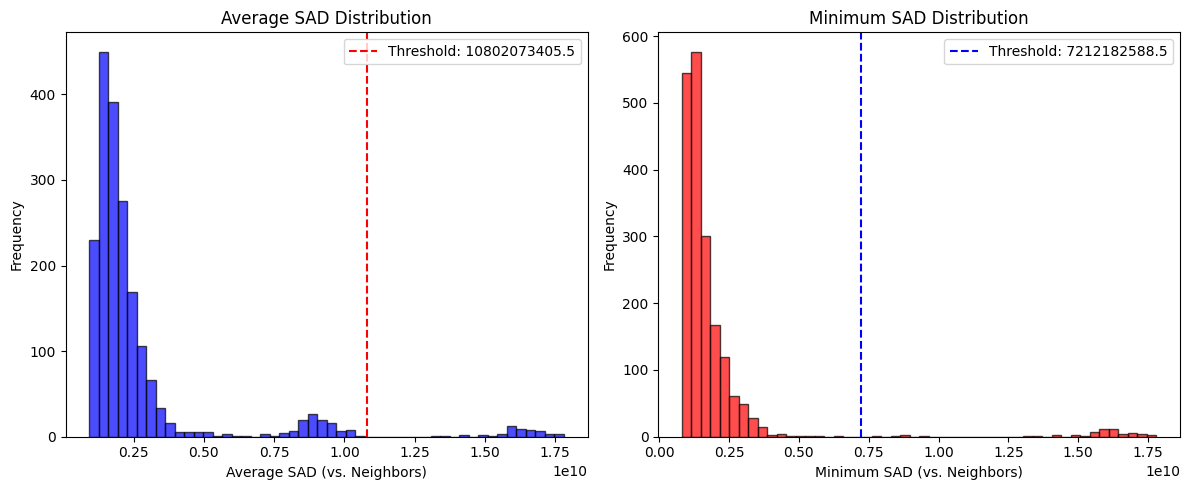

Outliers (avg SAD): [  40   70  100  130  160  190  220  280  310  340  400  430  460  520
  550  580  610  640  670  700  760  790  820  850  880  910  940 1000
 1030 1060 1120 1150 1180 1240 1270 1300 1330 1360 1390 1420 1480 1510
 1540 1570 1600 1630 1660 1720 1750 1780 1840 1870 1900]
Outliers (min SAD): [  40   70  100  130  160  190  220  250  280  310  340  400  430  460
  490  520  550  580  610  640  670  700  760  790  820  850  880  910
  940  970 1000 1030 1060 1120 1150 1180 1210 1240 1270 1300 1330 1360
 1390 1420 1480 1510 1540 1570 1600 1630 1660 1690 1720 1750 1780 1840
 1870 1900]


In [54]:
# Convert to numpy arrays
differences = np.array(differences)
min_differences = np.array(min_differences)

# Function to compute thresholds using MAD
def compute_threshold(data, multiplier=5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    threshold = median + multiplier * mad
    return threshold

# Compute thresholds for both metrics
threshold_avg = compute_threshold(differences, multiplier=20)
threshold_min = compute_threshold(min_differences, multiplier=20)

# Plot histograms with thresholds
plt.figure(figsize=(12, 5))

# Average SAD histogram
plt.subplot(1, 2, 1)
plt.hist(differences, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(threshold_avg, color='red', linestyle='--', label=f'Threshold: {threshold_avg:.1f}')
plt.xlabel('Average SAD (vs. Neighbors)')
plt.ylabel('Frequency')
plt.title('Average SAD Distribution')
plt.legend()

# Minimum SAD histogram
plt.subplot(1, 2, 2)
plt.hist(min_differences, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.axvline(threshold_min, color='blue', linestyle='--', label=f'Threshold: {threshold_min:.1f}')
plt.xlabel('Minimum SAD (vs. Neighbors)')
plt.ylabel('Frequency')
plt.title('Minimum SAD Distribution')
plt.legend()

plt.tight_layout()
plt.show()

# Print outlier frames
outliers_avg = np.where(differences > threshold_avg)[0]
outliers_min = np.where(min_differences > threshold_min)[0]
print(f"Outliers (avg SAD): {outliers_avg}")
print(f"Outliers (min SAD): {outliers_min}")

In [ ]:
[  10   40   70  100  130  160  190  220  250  280  310  340  400  430
  460  490  520  550  580  610  640  670  700  760  790  820  850  880
  910  940  970 1000 1030 1060 1120 1150 1180 1210 1240 1270 1300 1330
 1360 1390 1420 1480 1510 1540 1570 1600 1630 1660 1690 1720 1750 1780
 1840 1870 1900]

Outliers (avg SAD): [  40   70  100  130  160  190  220  280  310  340  400  430  460  520
  550  580  610  640  670  700  760  790  820  850  880  910  940 1000
 1030 1060 1120 1150 1180 1240 1270 1300 1330 1360 1390 1420 1480 1510
 1540 1570 1600 1630 1660 1720 1750 1780 1840 1870 1900]
Outliers (min SAD): [  40   70  100  130  160  190  220  250  280  310  340  400  430  460
  490  520  550  580  610  640  670  700  760  790  820  850  880  910
  940  970 1000 1030 1060 1120 1150 1180 1210 1240 1270 1300 1330 1360
 1390 1420 1480 1510 1540 1570 1600 1630 1660 1690 1720 1750 1780 1840
 1870 1900]


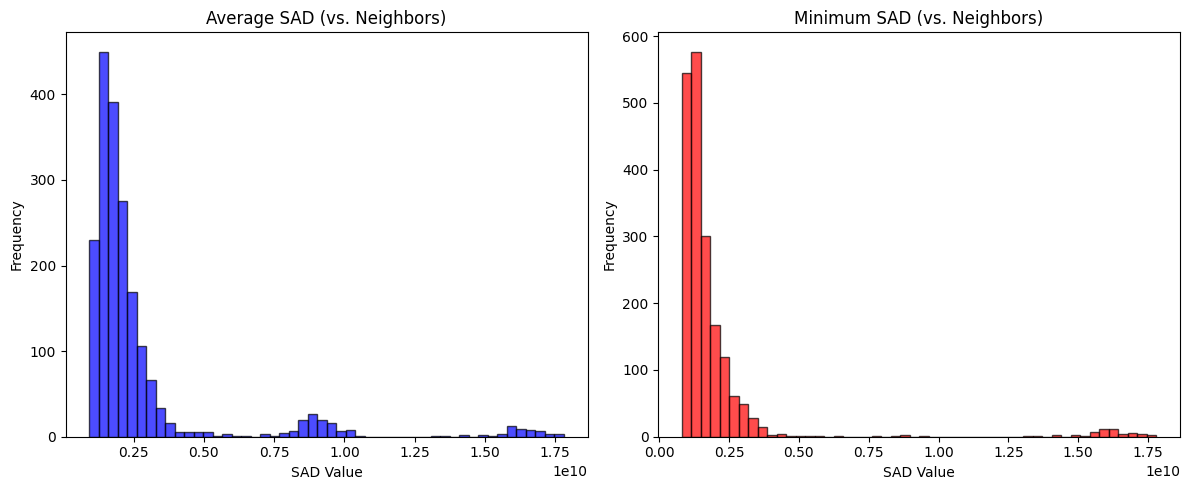

In [50]:
# Convert to numpy arrays
differences = np.array(differences)
min_differences = np.array(min_differences)

# Detect outliers using MAD (Median Absolute Deviation)
def detect_outliers(data, multiplier=5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    threshold = median + multiplier * mad
    return np.where(data > threshold)[0]

multiplier = 20
# Find outliers for both methods
outliers_avg = detect_outliers(differences, multiplier=multiplier)
outliers_min = detect_outliers(min_differences, multiplier=multiplier)

print(f"Outliers (avg SAD): {outliers_avg}")
print(f"Outliers (min SAD): {outliers_min}")

# Plot histograms to compare
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(differences, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title("Average SAD (vs. Neighbors)")
plt.xlabel("SAD Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(min_differences, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title("Minimum SAD (vs. Neighbors)")
plt.xlabel("SAD Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

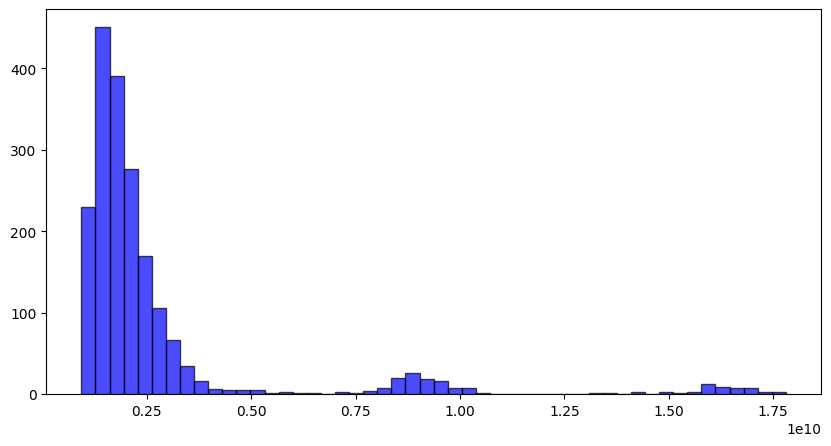

In [45]:
import matplotlib.pyplot as plt

# Mean SAD

plt.figure(figsize=(10, 5))
plt.hist(differences, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.show()
